# ViewCastLK: simple EDA of every input

What does each input tell us about how many views a Sri Lankan YouTube video
gets? One input at a time, with plain charts and a short explanation under each.

Dataset build: **18 September 2026**. The interpretation text was written against that
build; every number in a chart or table is recomputed when the notebook runs.

## How to read the charts

Each input gets the same two charts.

* **Left: how common each value is.** Number of videos with that value.
* **Right: day-7 views for each value, as "× typical".**
  * **Blue dot:** the typical (median) video with that value, compared with the
    typical video overall. **1×** is average, **2×** is twice the views, **0.5×**
    is half. The axis is a log scale, so 2× and 0.5× are the same distance from
    1×.
  * **Blue band:** where the middle half of those videos fall. A tall band means
    videos with that value vary a lot.
  * **Orange diamond: compared with its own channel.** Each video's views
    divided by its channel's average views (on the log scale), averaged over
    the group. This removes channel size. Only channels that post
    videos with more than one value of the input are counted (a channel that
    only posts Shorts cannot tell us whether Shorts beat long-form), and a
    diamond needs at least 5 such channels. If the blue dot is high but the
    orange diamond is near 1×, the value only looks good because big channels
    use it.

A table under each chart gives the actual numbers, followed by a summary.

## Why the orange diamond matters

Channel size explains far more of the views than anything else. So a raw
comparison ("Comedy gets more views than News") is often really a comparison of
which channels post it. The orange diamond answers the question a creator
actually has: **for my channel, does this help?**

Some inputs are the same for almost every video of a channel (subscribers,
category, topic), so there is no within-channel comparison to make. Those are
judged on the raw view only.

## The keep or drop rule

* **Drop** if 95% or more of videos have the same value.
* **Inputs fixed per channel** (channel statistics, category, topic): **keep**
  if the input explains at least **1%** of the variation in day-7 views.
* **Inputs that vary within a channel** (everything else): **keep** if, compared
  with their own channel, the best value's videos get at least **1.2×** the
  worst value's (groups of at least 200 videos). Because some inputs matter for
  small channels and not big ones, an input also passes if it reaches 1.2×
  inside one channel-size band, as long as every group there comes from at
  least 20 channels.
* "Explains %" is the share of the variation in log day-7 views that the
  input's groups account for on their own. 0% means views look the same in
  every group.

## Which videos

Live streams and videos without a duration are left out. Each horizon (7, 14,
21, 30 days) uses only videos with a label at that horizon. The per-input charts
use **day 7**, which has the most videos. Where the notebook compares horizons,
it uses the same videos (those with all four labels) so that time is the only
difference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm
from IPython.display import display
import helpers as L
from helpers import H, short, times, say, save

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
raw, d = L.load()
f = L.build_features(d)
S = {}   # summary numbers for each input, filled as the notebook runs

---
# 1. Data overview

In [2]:
pub = d.published
overview = pd.DataFrame({"value": [
    f"{len(raw):,}", f"{int(raw.is_live_broadcast.sum()):,}",
    f"{int((~raw.eligible & ~raw.is_live_broadcast).sum()):,}", f"{len(d):,}",
    f"{d.channel_id.nunique():,}", f"{pub.min():%d %b %Y} to {pub.max():%d %b %Y}",
] + [f"{int(d[f'v{h}'].notna().sum()):,}" for h in H] + [f"{int(d.all4.sum()):,}"]},
    index=["rows in the file", "live streams (left out)", "no duration, unavailable (left out)",
           "videos analysed", "channels", "published"]
          + [f"videos with a day-{h} label" for h in H] + ["videos with all four labels"])
display(overview)

,value
rows in the file,"123,766"
live streams (left out),"2,829"
"no duration, unavailable (left out)","1,522"
videos analysed,"119,415"
channels,"2,555"
published,02 Jul 2026 to 18 Sep 2026
videos with a day-7 label,"77,399"
videos with a day-14 label,"73,057"
videos with a day-21 label,"72,704"
videos with a day-30 label,"73,678"


**What this shows.** About 124,000 videos from roughly 2,500 Sri Lankan channels,
published from 2 July to 18 September 2026. Around 4,000 are left out (live
streams, and videos that had no duration because they were removed). Each
horizon has about 73,000 to 77,000 labelled videos, and about 44,000 videos have
all four labels.

## Data dictionary

Every column in the file, grouped by what it is. **Inputs** are what the model
may use. **Labels** are what it predicts. **Bookkeeping** columns describe how
the row was built and are never inputs.

In [3]:
DICT = [
    ("video_id, channel_id", "id", "identifiers"),
    ("published_at", "input (timing)", "publishing time, UTC; hour, weekday and weekend come from it"),
    ("title, tags, thumbnail_url", "raw text", "title and tag features are worked out from these"),
    ("category_id, category_name", "input (format)", "YouTube category"),
    ("duration_seconds", "input (format)", "video length"),
    ("is_short", "input (format)", "real Short: vertical or square and at most 3 minutes"),
    ("is_short_source, is_vertical", "bookkeeping", "whether the player shape or the old 60 s rule decided is_short"),
    ("definition, caption, made_for_kids", "input (format)", "HD or SD, captions, made-for-kids setting"),
    ("default_audio_language, default_language", "input (language)", "spoken language, and title/description language"),
    ("publish_hour_slt, publish_dow_slt, publish_is_weekend", "input (timing)", "Sri Lanka time"),
    ("publish_hour_sin/cos, publish_dow_sin/cos", "input (timing)", "the same hour and weekday as points on a circle, so 23:00 sits next to 00:00. Not charted separately"),
    ("title_length ... title_script", "input (title)", "length, word count, number, ?, !, capitals, writing system"),
    ("description_length, tag_count", "input (text)", "description size and number of tags"),
    ("ch_subs/views/videos_at_publish, channel_age_days_at_publish", "input (channel)", "the channel on the day the video was published"),
    ("channel_country, topic_categories", "input (channel)", "channel country and the channel's YouTube topics"),
    ("dN_views", "label", "views N days after publishing (N = 7, 14, 21, 30)"),
    ("dN_likes, dN_comments", "outcome, never an input", "happen after publishing, so using them would leak the answer"),
    ("dN_hours_off, dN_usable", "bookkeeping", "how far the observation was from exactly N days, and whether it is close enough"),
    ("eligible, is_live_broadcast", "bookkeeping", "rows left out of analysis"),
    ("channel_stats_backfilled, ch_stats_as_of", "bookkeeping", "channel statistics recorded only after publishing"),
    ("title_changed, description_changed", "bookkeeping", "edited since first seen"),
]
display(pd.DataFrame(DICT, columns=["column(s)", "type", "meaning"]).set_index("column(s)"))

,type,meaning
column(s),,
"video_id, channel_id",id,identifiers
published_at,input (timing),"publishing time, UTC; hour, weekday and weeken..."
"title, tags, thumbnail_url",raw text,title and tag features are worked out from these
"category_id, category_name",input (format),YouTube category
duration_seconds,input (format),video length
is_short,input (format),real Short: vertical or square and at most 3 m...
"is_short_source, is_vertical",bookkeeping,whether the player shape or the old 60 s rule ...
"definition, caption, made_for_kids",input (format),"HD or SD, captions, made-for-kids setting"
"default_audio_language, default_language",input (language),"spoken language, and title/description language"


## Types and missing values of the input columns

In [4]:
cols = ["category_name", "duration_seconds", "is_short", "definition", "caption", "made_for_kids",
        "default_audio_language", "default_language", "publish_hour_slt", "publish_dow_slt",
        "publish_is_weekend", "title_length", "title_word_count", "title_has_number",
        "title_has_question", "title_has_exclaim", "title_upper_ratio", "title_script",
        "description_length", "tag_count", "ch_subs_at_publish", "ch_views_at_publish",
        "ch_videos_at_publish", "channel_age_days_at_publish", "channel_country", "topic_categories"]
blank = lambda s: s.isna() | s.astype("string").str.strip().eq("")
display(pd.DataFrame({
    "type": [str(d[c].dtype) for c in cols],
    "missing or blank": [f"{blank(d[c]).mean()*100:.1f}%" for c in cols],
    "distinct values": [f"{d[c].nunique():,}" for c in cols],
    "example": [str(d[c].dropna().iloc[0])[:40] for c in cols],
}, index=cols))

,type,missing or blank,distinct values,example
category_name,str,0.8%,14,Entertainment
duration_seconds,float64,0.0%,"7,007",3157.0
is_short,bool,0.0%,2,False
definition,str,0.0%,2,hd
caption,str,0.0%,2,false
made_for_kids,object,0.0%,2,False
default_audio_language,str,7.6%,38,si
default_language,str,0.0%,44,si
publish_hour_slt,int32,0.0%,24,8
publish_dow_slt,int32,0.0%,7,3


**What this shows.** Almost every input is complete. The exceptions are audio
language (not set on about 8% of videos) and category (under 1%). Channel
statistics look complete here, but for about 31% of videos they were recorded
only after publishing (see section 2), so the channel charts leave those out.

## Videos published per day

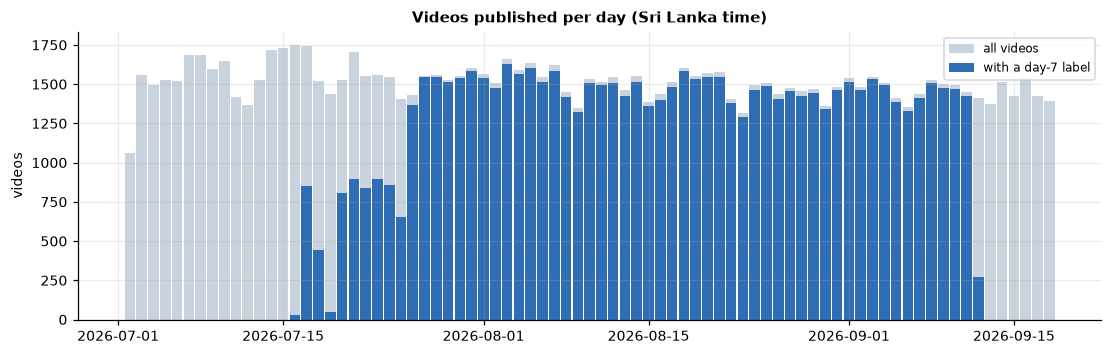

In [5]:
day = d.published.dt.floor("D").dt.tz_localize(None)
per_day = pd.DataFrame({"all": day.value_counts(), "with a day-7 label": day[d.v7.notna()].value_counts()}).sort_index().fillna(0)
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.bar(per_day.index, per_day["all"], color="#C9D3DD", label="all videos", width=.9)
ax.bar(per_day.index, per_day["with a day-7 label"], color="#2F6DB5", label="with a day-7 label", width=.9)
ax.set(ylabel="videos", title="Videos published per day (Sri Lanka time)")
ax.legend(fontsize=8)
save(fig, "videos_per_day")

**What this shows.** About 1,400 to 1,700 videos are published per day, steady
across the whole period. Videos from the first two weeks mostly have no day-7
label because tracking had not started for them yet. The last week has no
day-7 label yet because those videos are not 7 days old.

---
# 2. Data quality

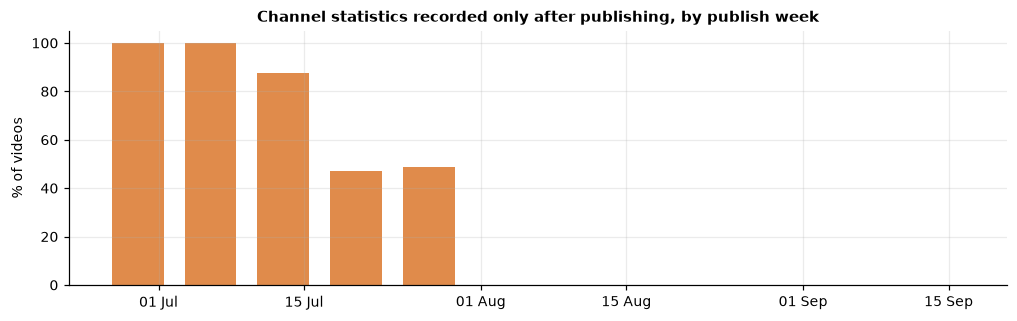

,labels,median distance from exact day,within 3 h,within 12 h
horizon,,,,
day 7,"77,399",1.5 h,93%,100%
day 14,"73,057",1.5 h,92%,100%
day 21,"72,704",1.5 h,92%,100%
day 30,"73,678",1.5 h,92%,100%


,share of videos
channel stats recorded after publishing,30.9%
title edited after first seen,1.2%
description edited after first seen,1.6%
Short flag decided by player shape,97.9%


In [6]:
week = d.published.dt.tz_localize(None).dt.to_period("W").dt.start_time
bf = d.groupby(week).channel_stats_backfilled.mean() * 100
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(bf.index, bf.values, width=5, color="#E08B4B")
ax.set(ylabel="% of videos", title="Channel statistics recorded only after publishing, by publish week")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
save(fig, "backfilled_by_week")

rows = []
for h in H:
    off = pd.to_numeric(d[f"d{h}_hours_off"], errors="coerce").abs()[d[f"v{h}"].notna()]
    rows.append({"horizon": f"day {h}", "labels": f"{int(d[f'v{h}'].notna().sum()):,}",
                 "median distance from exact day": f"{off.median():.1f} h",
                 "within 3 h": f"{(off <= 3).mean()*100:.0f}%", "within 12 h": f"{(off <= 12).mean()*100:.0f}%"})
display(pd.DataFrame(rows).set_index("horizon"))
display(pd.DataFrame({"share of videos": [
    f"{d.channel_stats_backfilled.mean()*100:.1f}%", f"{d.title_changed.mean()*100:.1f}%",
    f"{d.description_changed.mean()*100:.1f}%", f"{(d.is_short_source == 'shape').mean()*100:.1f}%"]},
    index=["channel stats recorded after publishing", "title edited after first seen",
           "description edited after first seen", "Short flag decided by player shape"]))

**What this shows.**

* **Channel statistics recorded after publishing** (31% of videos) are all from
  videos published before 1 August: every video in the first two weeks, 87% in
  the third and about half in the next two. None after that. For those videos we do
  not know the channel's size on publishing day, so channel charts leave them
  out rather than guess.
* **Labels are close to the exact day.** The typical label is 1.5 hours away
  from exactly 7, 14, 21 or 30 days, over 90% are within 3 hours, and none is
  more than 12 hours away.
* **Titles and descriptions are rarely edited** (about 1 to 2%), so the title
  we recorded is almost always the one the video was published with.
* **The Short flag** comes from the video's player shape for 98% of videos.

---
# 3. The target: views at 7, 14, 21 and 30 days

,videos,median,25th pct,75th pct,90th pct,99th pct,largest,share with 0 views
horizon,,,,,,,,
day 7,"77,399",1.2K,210,6.1K,31.8K,340.3K,17.4M,0.7%
day 14,"73,057",1.2K,210,5.9K,31.8K,354.4K,46.3M,0.6%
day 21,"72,704",1.1K,199,5.7K,31.1K,356.5K,56.7M,0.5%
day 30,"73,678",1.1K,205,5.8K,31.8K,375.4K,58.3M,0.4%


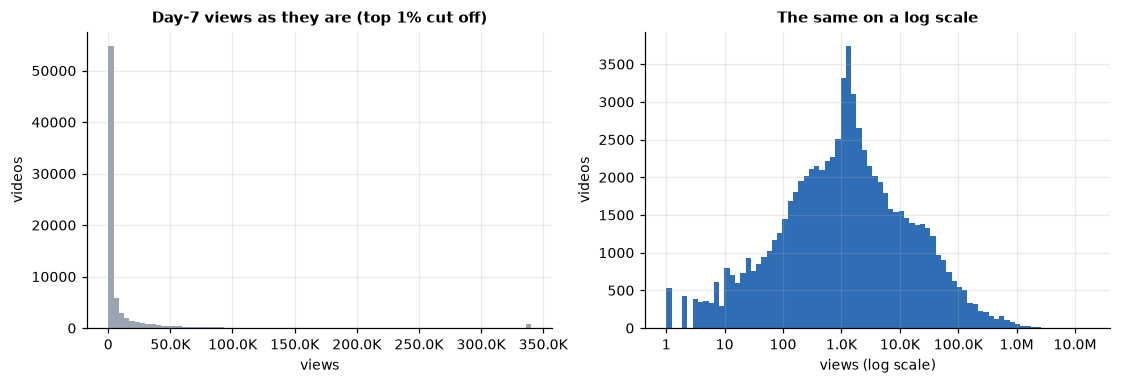

In [7]:
rows = []
for h in H:
    v = d[f"v{h}"].dropna()
    rows.append({"horizon": f"day {h}", "videos": f"{len(v):,}", "median": short(v.median()),
                 "25th pct": short(v.quantile(.25)), "75th pct": short(v.quantile(.75)),
                 "90th pct": short(v.quantile(.9)), "99th pct": short(v.quantile(.99)),
                 "largest": short(v.max()), "share with 0 views": f"{(v == 0).mean()*100:.1f}%"})
display(pd.DataFrame(rows).set_index("horizon"))

v7 = d.v7.dropna()
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.5))
a.hist(v7.clip(upper=v7.quantile(.99)), bins=80, color="#9AA5B1")
a.set(title="Day-7 views as they are (top 1% cut off)", xlabel="views", ylabel="videos")
a.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: short(x)))
b.hist(np.log10(v7 + 1), bins=80, color="#2F6DB5")
b.set(title="The same on a log scale", xlabel="views (log scale)", ylabel="videos")
b.xaxis.set_major_locator(mticker.FixedLocator(range(0, 8)))
b.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: short(10 ** x)))
save(fig, "target_distribution")

**What this shows.** Views are extremely uneven. The typical video gets about
1,200 views in its first week, a quarter get under about 200, and the top 1%
get over 340,000. On a normal scale (left) almost every video is squashed
against zero. On a log scale (right) the shape is easy to read, which is why
every chart in this notebook uses ratios and log scales.

## How views grow from day 7 to day 30 (same videos)

In [8]:
c = d[d.all4]
med = pd.Series({h: c[f"v{h}"].median() for h in H})
ratio = (c.v30 / c.v7.where(c.v7 > 0)).dropna()
display(pd.DataFrame({"median views": med.map(short).values, "× day 7": (med / med[7]).map(times).values},
                     index=[f"day {h}" for h in H]))
say(f"On the {len(c):,} videos with all four labels, the typical video's day-30 views are "
    f"**{times(ratio.median())}** its day-7 views. For a quarter of videos they are at most "
    f"{times(ratio.quantile(.25))}; for another quarter at least {times(ratio.quantile(.75))}.")

,median views,× day 7
day 7,1.1K,1.00×
day 14,1.1K,1.04×
day 21,1.1K,1.06×
day 30,1.2K,1.08×


On the 43,765 videos with all four labels, the typical video's day-30 views are **1.03×** its day-7 views. For a quarter of videos they are at most 1.01×; for another quarter at least 1.16×.

**What this shows.** Most views arrive in the first week. The typical video's
day-30 views are only a few per cent above its day-7 views. The day-7 forecast
is therefore close to the final number for most videos; later horizons add
little for a typical video but more for the minority that keep growing
(section 12).

---
# 4. Channel inputs

These describe the channel, not the video. A creator cannot change them before
posting, but they are the strongest inputs by far. Each video's channel figures
are taken on its publishing day. There is no orange diamond here, because a
channel's inputs are the same for all its videos.

## subscribers

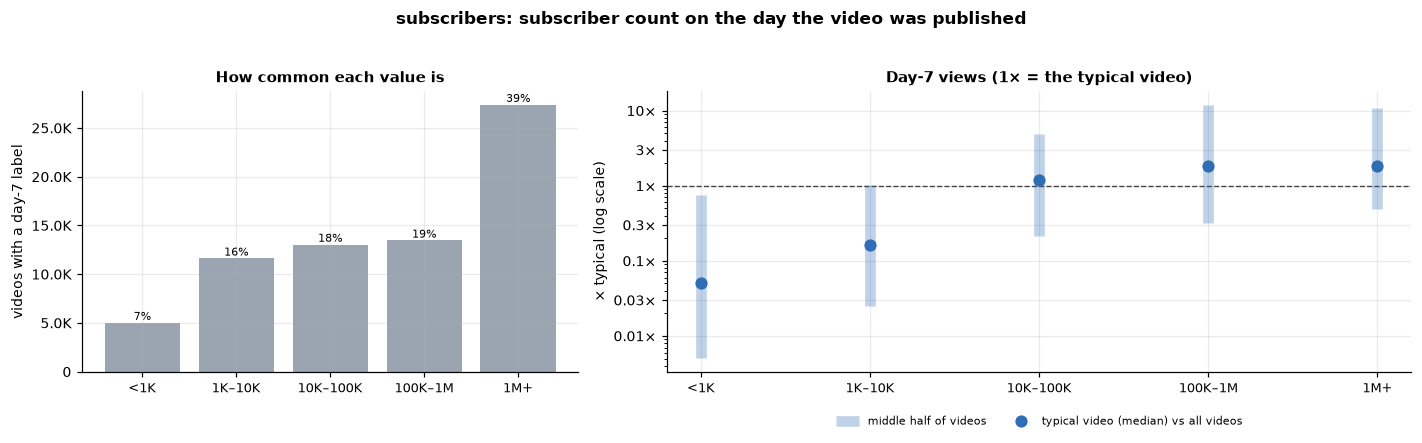

,videos,share,median day-7 views,middle half,× typical
subscribers,,,,,
<1K,"5,032",7.1%,60,6 – 910,0.05×
1K–10K,"11,626",16.5%,195,30 – 1.2K,0.16×
10K–100K,"13,047",18.5%,1.4K,254 – 5.8K,1.19×
100K–1M,"13,471",19.1%,2.2K,383 – 14.4K,1.81×
1M+,"27,392",38.8%,2.2K,579 – 12.8K,1.83×


**Source at forecast time:** looked up from the channel. Missing for 31% of videos (channel statistics recorded after publishing are left out). Most common value: **1M+** (39% of videos). Best: **1M+** (2.2K views, 1.83× typical). Worst: **<1K** (60, 0.05×). Explains **22.5%** of the variation in day-7 views.

In [9]:
S["subscribers"] = L.show(d, f, "subscribers")

**What it shows.** The bigger the channel, the more views, up to about 100K
subscribers. A channel under 1K subscribers typically gets about 60 views a
week; one with 100K or more gets about 2,200. Above 100K the typical video
stops rising: 100K to 1M and 1M+ channels are about the same. **Verdict: keep.**

### subscribers at 7, 14, 21 and 30 days

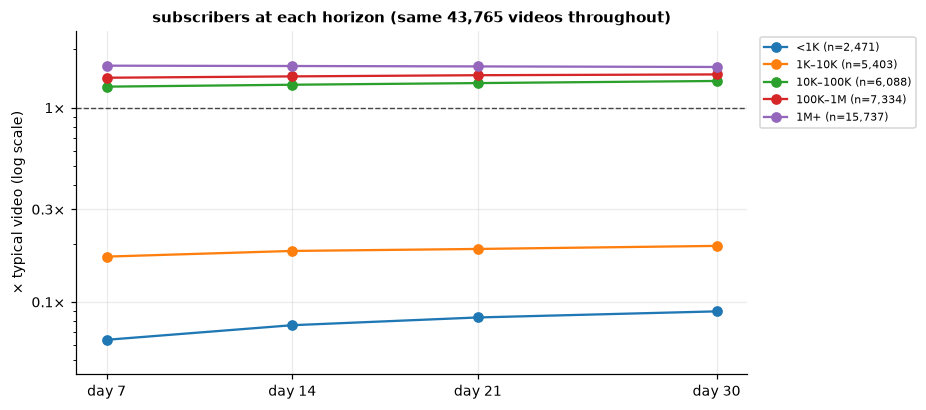

,day 7,day 14,day 21,day 30
subscribers,,,,
<1K,0.06×,0.08×,0.08×,0.09×
1K–10K,0.17×,0.18×,0.19×,0.19×
10K–100K,1.28×,1.31×,1.34×,1.37×
100K–1M,1.43×,1.45×,1.47×,1.48×
1M+,1.65×,1.64×,1.63×,1.62×


In [10]:
L.horizon_lines(d, f, "subscribers", None)

**Over time.** The pattern is the same at day 7 and day 30. Small channels gain
slightly relative to big ones over the month, but the order never changes.

## channel average views per video

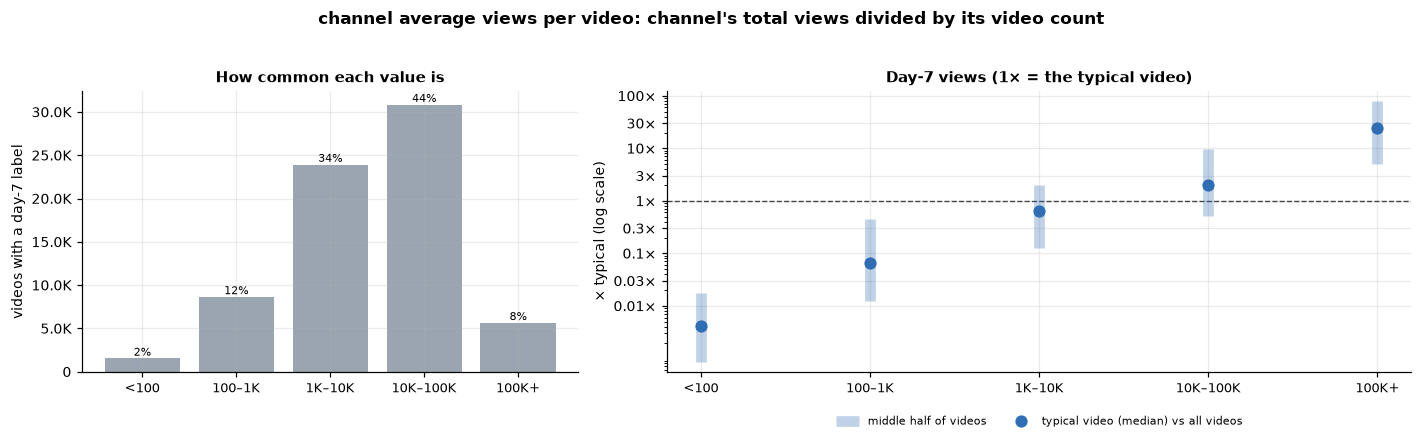

,videos,share,median day-7 views,middle half,× typical
channel average views per video,,,,,
<100,"1,529",2.2%,5,1 – 21,0.00×
100–1K,"8,635",12.2%,80,15 – 546,0.07×
1K–10K,"23,915",33.9%,774,150 – 2.4K,0.65×
10K–100K,"30,838",43.7%,2.4K,626 – 11.8K,1.98×
100K+,"5,642",8.0%,29.3K,6.1K – 97.1K,24×


**Source at forecast time:** looked up from the channel. Missing for 31% of videos (channel statistics recorded after publishing are left out). Most common value: **10K–100K** (44% of videos). Best: **100K+** (29.3K views, 24× typical). Worst: **<100** (5, 0.00×). Explains **38.1%** of the variation in day-7 views.

In [11]:
S["channel average views per video"] = L.show(d, f, "channel average views per video")

**What it shows.** The single strongest input: 38% of the variation on its own.
A channel whose past videos averaged over 100K views typically gets about
29,000 views on a new video; one averaging under 100 gets about 5. It works
better than subscribers because it measures how many people actually watch,
not how many once subscribed. **Verdict: keep.**

## channel video count

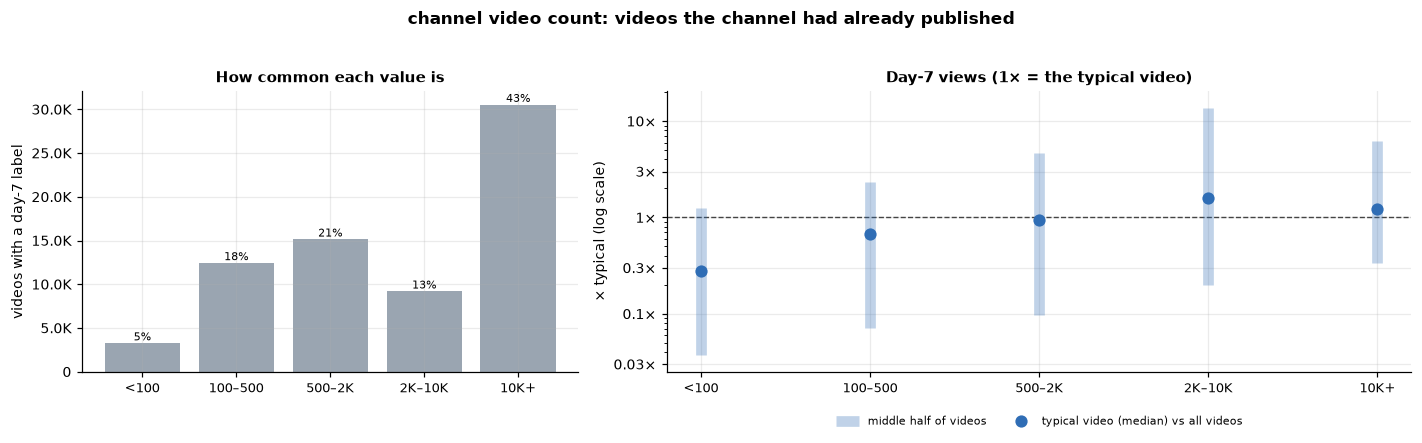

,videos,share,median day-7 views,middle half,× typical
channel video count,,,,,
<100,"3,269",4.6%,337,45 – 1.5K,0.28×
100–500,"12,439",17.6%,802,86 – 2.8K,0.67×
500–2K,"15,138",21.5%,1.1K,115 – 5.6K,0.95×
2K–10K,"9,193",13.0%,1.9K,239 – 16.3K,1.58×
10K+,"30,529",43.3%,1.5K,408 – 7.4K,1.24×


**Source at forecast time:** looked up from the channel. Missing for 31% of videos (channel statistics recorded after publishing are left out). Most common value: **10K+** (43% of videos). Best: **2K–10K** (1.9K views, 1.58× typical). Worst: **<100** (337, 0.28×). Explains **4.5%** of the variation in day-7 views.

In [12]:
S["channel video count"] = L.show(d, f, "channel video count")

**What it shows.** Channels with more uploads get more views, up to about
10,000 videos. Beyond that, views per video fall slightly, because those are
the very high-volume channels (mostly news) that split their audience across
many clips. **Verdict: keep.**

## channel uploads per day

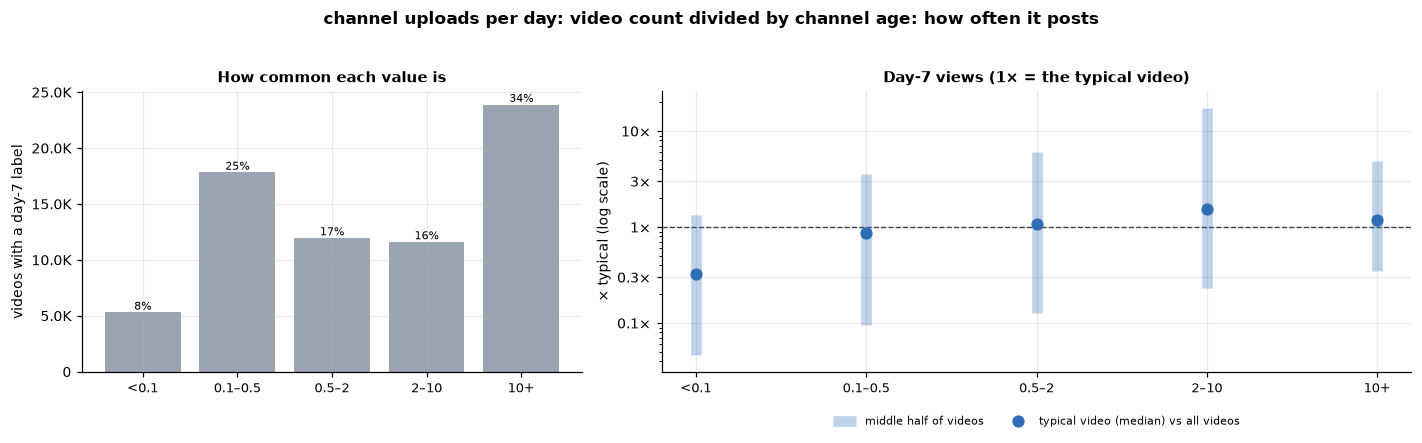

,videos,share,median day-7 views,middle half,× typical
channel uploads per day,,,,,
<0.1,"5,299",7.5%,388,56 – 1.6K,0.32×
0.1–0.5,"17,823",25.3%,1.1K,114 – 4.2K,0.88×
0.5–2,"11,958",16.9%,1.3K,152 – 7.3K,1.08×
2–10,"11,602",16.4%,1.8K,276 – 20.7K,1.54×
10+,"23,886",33.8%,1.4K,422 – 5.9K,1.17×


**Source at forecast time:** worked out from the channel. Missing for 31% of videos (channel statistics recorded after publishing are left out). Most common value: **10+** (34% of videos). Best: **2–10** (1.8K views, 1.54× typical). Worst: **<0.1** (388, 0.32×). Explains **3.5%** of the variation in day-7 views.

In [13]:
S["channel uploads per day"] = L.show(d, f, "channel uploads per day")

**What it shows.** Channels posting under one video every ten days get the
fewest views. Views rise with posting rate up to 2 to 10 videos a day, then
drop for channels posting more than 10 a day (again, mostly news). It overlaps
heavily with video count (section 16). **Verdict: keep.**

## channel age

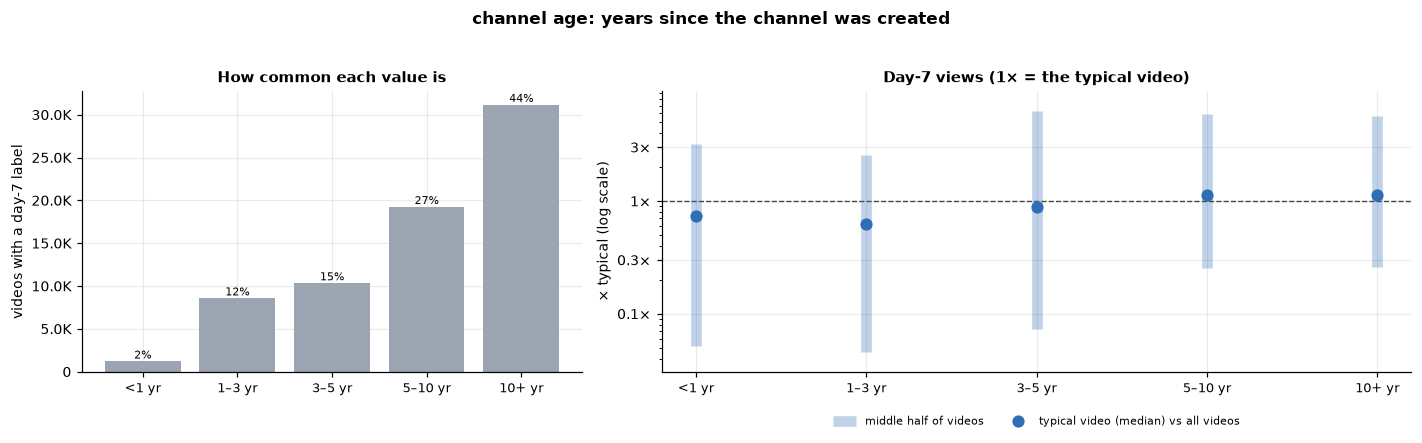

,videos,share,median day-7 views,middle half,× typical
channel age,,,,,
<1 yr,"1,215",1.7%,885,62 – 3.8K,0.74×
1–3 yr,"8,583",12.2%,742,55 – 3.0K,0.62×
3–5 yr,"10,348",14.7%,1.1K,88 – 7.5K,0.88×
5–10 yr,"19,251",27.3%,1.4K,307 – 7.1K,1.13×
10+ yr,"31,171",44.2%,1.3K,309 – 6.8K,1.12×


**Source at forecast time:** looked up from the channel. Missing for 31% of videos (channel statistics recorded after publishing are left out). Most common value: **10+ yr** (44% of videos). Best: **5–10 yr** (1.4K views, 1.13× typical). Worst: **1–3 yr** (742, 0.62×). Explains **2.5%** of the variation in day-7 views.

In [14]:
S["channel age"] = L.show(d, f, "channel age")

**What it shows.** A weak effect. Channels older than 5 years get a little
more than younger ones, but the difference is under 2×. **Verdict: keep** (it
explains 2.5%, over the 1% bar), but it adds little once size is known.

## YouTube topic

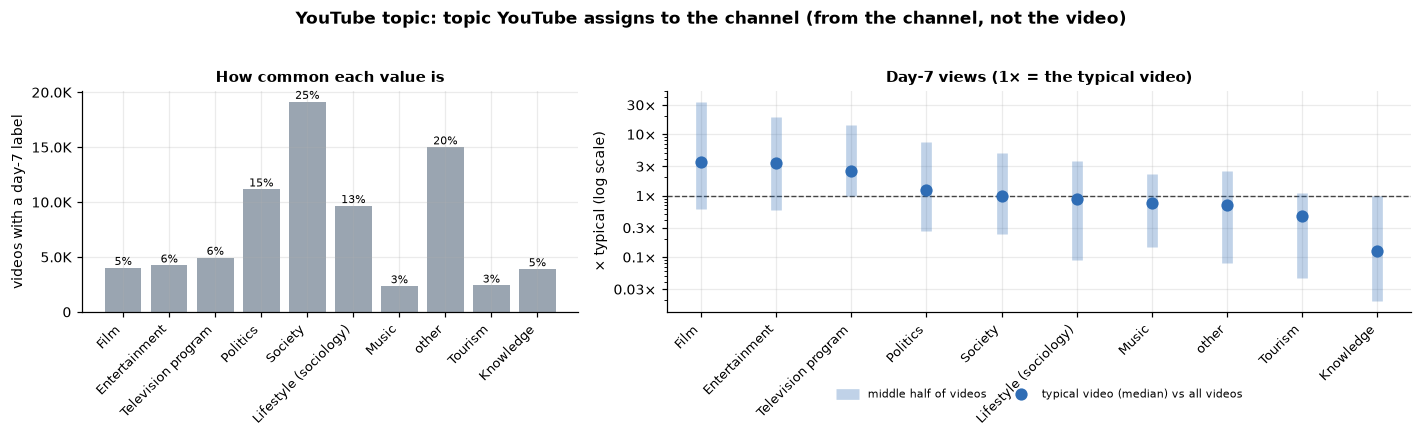

,videos,share,median day-7 views,middle half,× typical
YouTube topic,,,,,
Film,"4,035",5.2%,4.3K,726 – 40.3K,3.6×
Entertainment,"4,251",5.5%,4.0K,708 – 22.8K,3.4×
Television program,"4,956",6.4%,3.0K,1.2K – 17.3K,2.5×
Politics,"11,177",14.5%,1.5K,315 – 9.0K,1.25×
Society,"19,156",24.9%,1.2K,285 – 6.0K,0.98×
Lifestyle (sociology),"9,664",12.6%,1.0K,108 – 4.4K,0.87×
Music,"2,361",3.1%,906,176 – 2.7K,0.76×
other,"15,012",19.5%,842,95 – 3.0K,0.70×
Tourism,"2,423",3.1%,570,55 – 1.3K,0.48×


**Source at forecast time:** looked up from the channel (not sent yet). Most common value: **Society** (25% of videos). Best: **Film** (4.3K views, 3.6× typical). Worst: **Knowledge** (150, 0.13×). Explains **10.3%** of the variation in day-7 views.

In [15]:
S["YouTube topic"] = L.show(d, f, "YouTube topic")

**What it shows.** The topic YouTube assigns to the **channel** (for example
Film, Politics, Knowledge). Film and Entertainment channels typically get
about 3.5× the typical video; Knowledge channels about 0.13×. It explains 10%
on its own.

**Important:** this comes from the channel lookup the API already makes, so it
*is* available before publishing. The API does not send it today. **Verdict:
keep, and fetch it at forecast time.**

## Inputs where almost every video has the same value

In [16]:
L.constants_table(d, f, ['channel country'])
S["channel country"] = L.stats(d, f, "channel country")

,most common value,share of videos,source at forecast time
input,,,
channel country,LK,100.0%,looked up from the channel


Almost every channel lists Sri Lanka, so country carries no information.
**Verdict: drop.**

---
# 5. Video format

These describe the video itself, and a creator decides them. From here on, the
orange diamond (same channel) matters most.

## duration

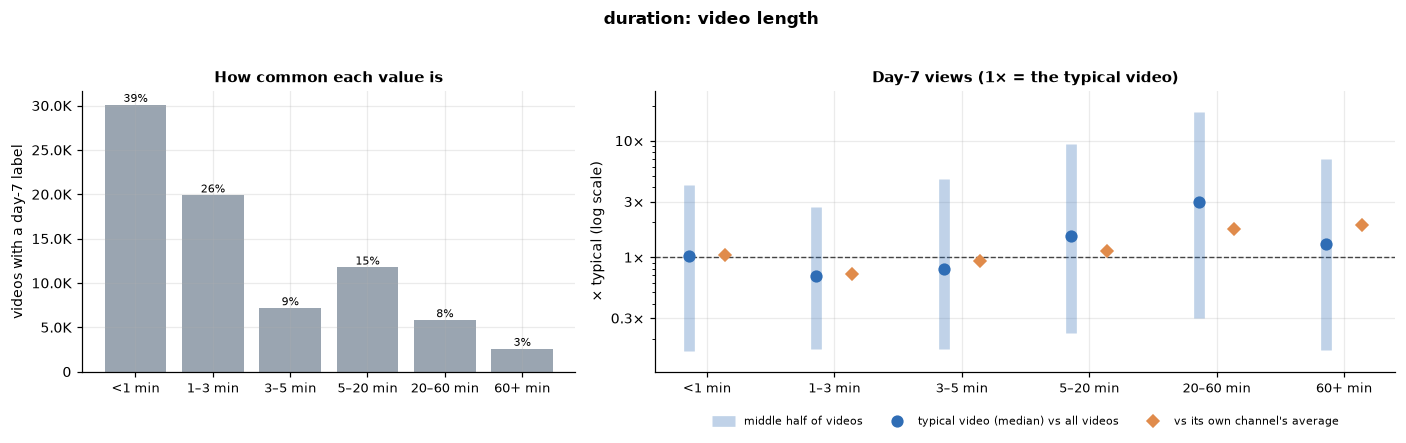

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
duration,,,,,,,
<1 min,"30,109",38.9%,1.2K,187 – 5.0K,1.02×,1.04×,"23,812"
1–3 min,"19,902",25.7%,834,197 – 3.3K,0.70×,0.72×,"19,594"
3–5 min,"7,186",9.3%,958,196 – 5.7K,0.80×,0.93×,"6,997"
5–20 min,"11,773",15.2%,1.8K,268 – 11.3K,1.52×,1.14×,"10,767"
20–60 min,"5,832",7.5%,3.6K,358 – 21.2K,3.0×,1.74×,"5,416"
60+ min,"2,597",3.4%,1.6K,190 – 8.4K,1.30×,1.87×,"2,361"


**Source at forecast time:** on the form. Most common value: **<1 min** (39% of videos). Best: **20–60 min** (3.6K views, 3.0× typical). Worst: **1–3 min** (834, 0.70×). Against its own channel (68,947 videos from the 1,238 channels that use more than one value): best **60+ min** (1.87×), worst **1–3 min** (0.72×): a **2.59×** gap. Largest gap inside one channel-size band: **6.54×** (channels with 1M+ subscribers). Explains **1.6%** of the variation in day-7 views.

In [17]:
S["duration"] = L.show(d, f, "duration")

**What it shows.** The clearest video-level input. Videos of 20 to 60 minutes
get about 3× the typical video, and it holds within the same channel: videos
of 20 minutes or more get about 1.7× to 1.9× the channel's average. Videos of **1 to 3 minutes do worst** in both
views. Many of them are short news clips, and some are horizontal clips that
are not Shorts. **Verdict: keep (strong).**

### duration at 7, 14, 21 and 30 days

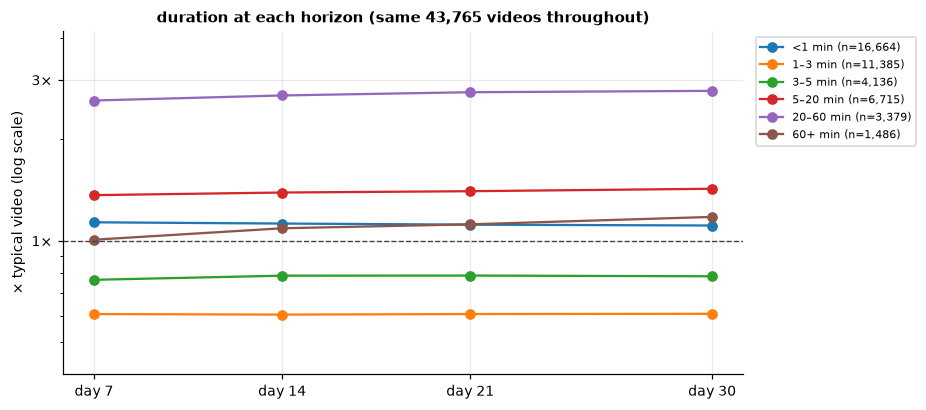

,day 7,day 14,day 21,day 30
duration,,,,
<1 min,1.13×,1.13×,1.12×,1.11×
1–3 min,0.61×,0.60×,0.61×,0.61×
3–5 min,0.77×,0.79×,0.79×,0.78×
5–20 min,1.37×,1.39×,1.40×,1.43×
20–60 min,2.6×,2.7×,2.8×,2.8×
60+ min,1.01×,1.09×,1.12×,1.18×


In [18]:
L.horizon_lines(d, f, "duration", None)

**Over time.** Long videos gain a little more after the first week than short
ones (60+ minutes rises from 1.0× to 1.2×), but the order stays the same.

## Short or long-form

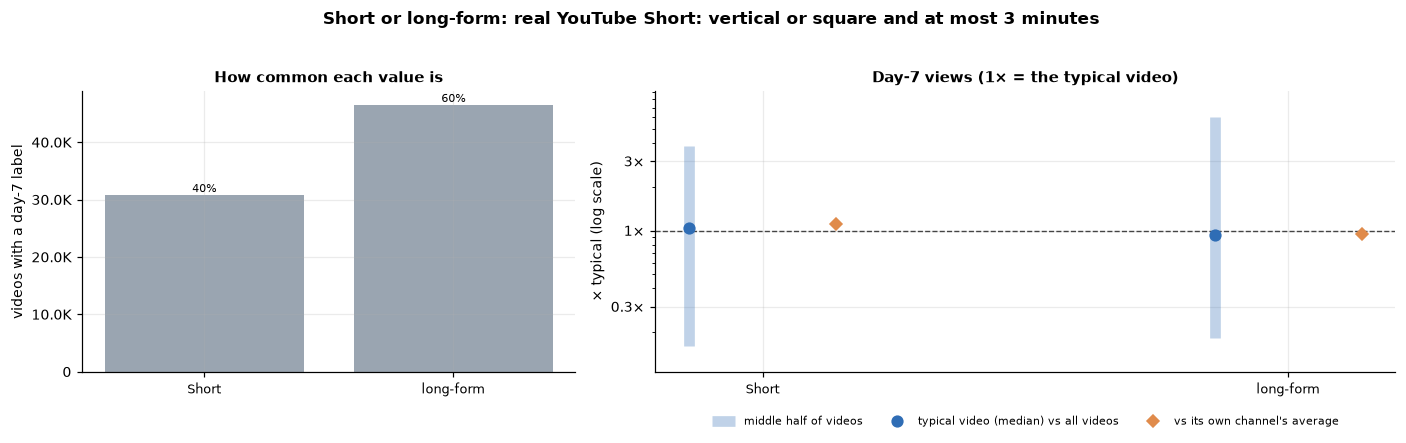

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
Short or long-form,,,,,,,
Short,"30,844",39.9%,1.3K,192 – 4.5K,1.05×,1.10×,"21,628"
long-form,"46,555",60.1%,1.1K,218 – 7.2K,0.93×,0.94×,"35,888"


**Source at forecast time:** not sent yet (form needs the field). Most common value: **long-form** (60% of videos). Best: **Short** (1.3K views, 1.05× typical). Worst: **long-form** (1.1K, 0.93×). Against its own channel (57,516 videos from the 848 channels that use more than one value): best **Short** (1.10×), worst **long-form** (0.94×): a **1.17×** gap. Largest gap inside one channel-size band: **1.97×** (channels with 1K–10K subscribers). Explains **0.1%** of the variation in day-7 views.

In [19]:
S["Short or long-form"] = L.show(d, f, "Short or long-form")

**What it shows.** Overall, Shorts and long-form look almost the same (1.3K
against 1.1K typical views). Compared with their own channel, Shorts do about
1.17× better. That overall number hides a big split by channel size, shown in
the next two charts. **Verdict: keep, and add a Short / long-form field to the
form.**

### Short or long-form at 7, 14, 21 and 30 days

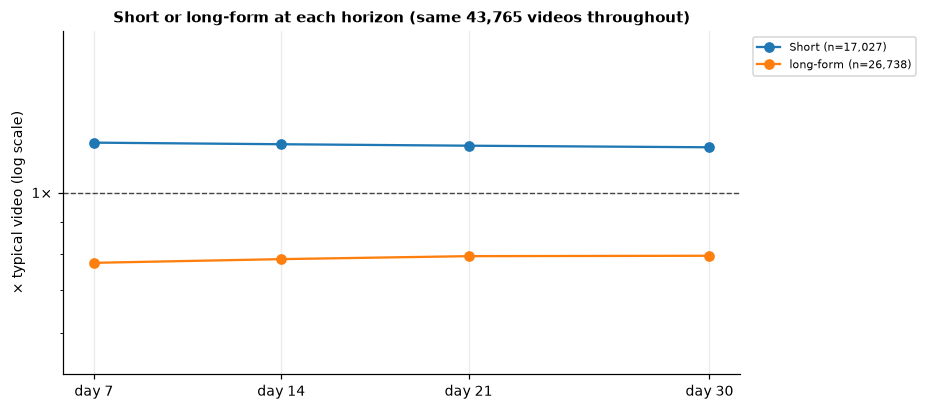

,day 7,day 14,day 21,day 30
Short or long-form,,,,
Short,1.20×,1.19×,1.19×,1.18×
long-form,0.77×,0.78×,0.79×,0.79×


In [20]:
L.horizon_lines(d, f, "Short or long-form", None)

**Over time.** On the same videos, Shorts stay at about 1.2× and long-form at
about 0.8× from day 7 to day 30. A Short's advantage does not fade later.

### Shorts against long-form by channel size

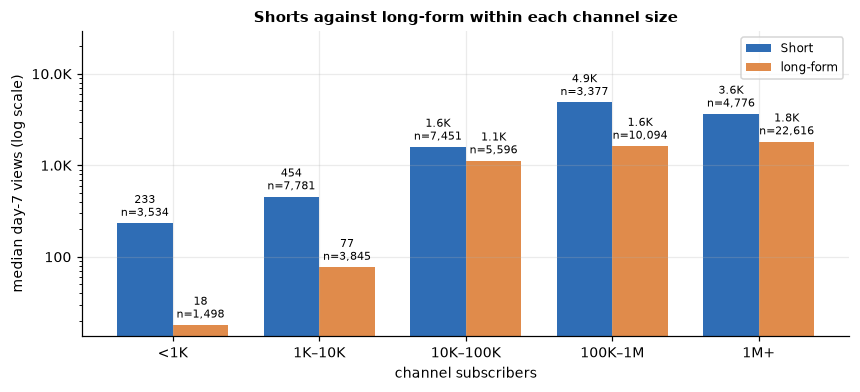

,<1K,1K–10K,10K–100K,100K–1M,1M+
all videos in the band (median Short ÷ median long-form),13×,5.9×,1.41×,3.0×,2.0×
"same channel (Short ÷ long-form, own-channel view)",1.60×,1.97×,1.35×,0.93×,0.93×


In [21]:
t = d[d.v7.notna()].assign(size=f["subscribers"], fmt=f["Short or long-form"]).dropna(subset=["size"])
med = t.groupby(["size", "fmt"], observed=True).v7.median().unstack()
cnt = t.groupby(["size", "fmt"], observed=True).v7.size().unstack()
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(med))
for i, (fmt, col) in enumerate(zip(med.columns, [L.RAW, L.OWN])):
    ax.bar(x + (i - .5) * .38, med[fmt], .38, color=col, label=fmt)
    for xi, (m, n) in enumerate(zip(med[fmt], cnt[fmt])):
        ax.text(xi + (i - .5) * .38, m * 1.1, f"{short(m)}\nn={n:,}", ha="center", va="bottom", fontsize=7)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: short(v)))
ax.set_ylim(top=med.max().max() * 6)
ax.set_xticks(x); ax.set_xticklabels(med.index)
ax.set(xlabel="channel subscribers", ylabel="median day-7 views (log scale)",
       title="Shorts against long-form within each channel size")
ax.legend(fontsize=8)
save(fig, "shorts_by_channel_size")
same = {}
for band in med.index:
    tb = L.group_table(d, f["Short or long-form"], rows=f["subscribers"] == band)
    same[band] = tb.loc["Short", "own_x"] / tb.loc["long-form", "own_x"]
display(pd.DataFrame({"all videos in the band (median Short ÷ median long-form)": (med["Short"] / med["long-form"]).map(times),
                      "same channel (Short ÷ long-form, own-channel view)": pd.Series(same).map(times)}).T)

**What it shows.** Within every size band, Shorts get more views than
long-form: 13× more for channels under 1K subscribers and 6× for 1K to 10K.

The second row compares Shorts with long-form **on the same channel**, which is
the fair comparison. For channels under 100K subscribers, Shorts beat the
channel's own long-form by about 1.35× to 2×. For channels over 100K, Shorts
do slightly worse. So "post Shorts" is good advice for small and mid-size
channels, and not for big ones.

## category

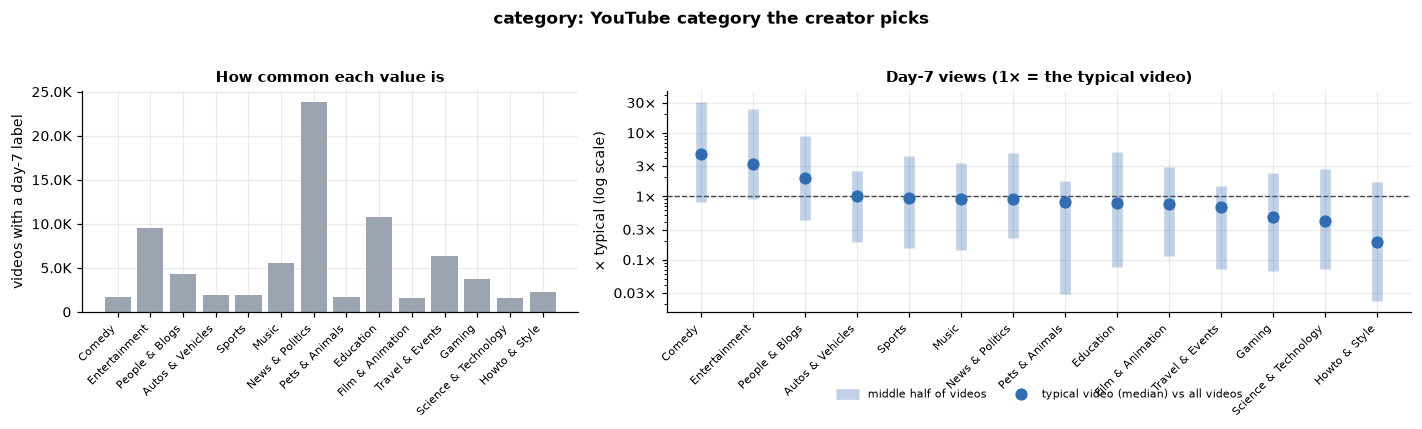

,videos,share,median day-7 views,middle half,× typical
category,,,,,
Comedy,"1,735",2.3%,5.6K,993 – 36.4K,4.7×
Entertainment,"9,582",12.5%,3.9K,1.1K – 28.9K,3.3×
People & Blogs,"4,296",5.6%,2.3K,503 – 10.7K,1.93×
Autos & Vehicles,"1,876",2.4%,1.2K,225 – 3.1K,1.03×
Sports,"1,875",2.4%,1.1K,186 – 5.3K,0.94×
Music,"5,512",7.2%,1.1K,171 – 4.1K,0.92×
News & Politics,"23,885",31.1%,1.1K,265 – 5.8K,0.89×
Pets & Animals,"1,665",2.2%,962,34 – 2.1K,0.80×
Education,"10,794",14.1%,926,91 – 5.9K,0.77×


**Source at forecast time:** on the form. Most common value: **News & Politics** (31% of videos). Best: **Comedy** (5.6K views, 4.7× typical). Worst: **Howto & Style** (229, 0.19×). Explains **9.1%** of the variation in day-7 views.

In [22]:
S["category"] = L.show(d, f, "category")

**What it shows.** Comedy (4.7×), Entertainment (3.3×) and People & Blogs
(1.9×) get the most views; Howto & Style (0.19×) and Science & Technology
(0.41×) the fewest. This raw ranking is partly about which channels post in
each category (section 10 shows this). **Verdict: keep.**

### category at 7, 14, 21 and 30 days

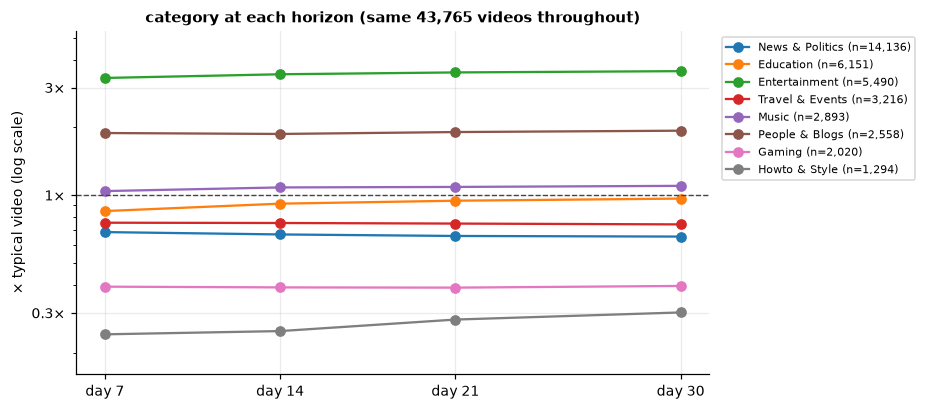

,day 7,day 14,day 21,day 30
category,,,,
News & Politics,0.69×,0.67×,0.66×,0.65×
Education,0.85×,0.92×,0.94×,0.97×
Entertainment,3.3×,3.4×,3.5×,3.6×
Travel & Events,0.75×,0.75×,0.75×,0.74×
Music,1.04×,1.08×,1.09×,1.10×
People & Blogs,1.89×,1.87×,1.91×,1.93×
Gaming,0.39×,0.39×,0.39×,0.40×
Howto & Style,0.24×,0.25×,0.28×,0.30×


In [23]:
L.horizon_lines(d, f, "category", L.main_categories(d, 2000))

**Over time.** Mostly stable. Education and Howto & Style gain relative to
others after the first week (people search for them later), while News &
Politics loses a little (news is watched on the day).

## Inputs where almost every video has the same value

In [24]:
L.constants_table(d, f, ['HD or SD', 'captions', 'made for kids'])
S["HD or SD"] = L.stats(d, f, "HD or SD")
S["captions"] = L.stats(d, f, "captions")
S["made for kids"] = L.stats(d, f, "made for kids")

,most common value,share of videos,source at forecast time
input,,,
HD or SD,HD,96.1%,not on the form
captions,false,99.8%,not on the form
made for kids,false,99.5%,not on the form


HD or SD, captions and made for kids are the same for 96% or more of videos,
and are not on the form. **Verdict: drop all three.**

---
# 6. Language

Language inputs vary within a channel more than you might expect: about a
third of channels post in more than one audio language.

## audio language

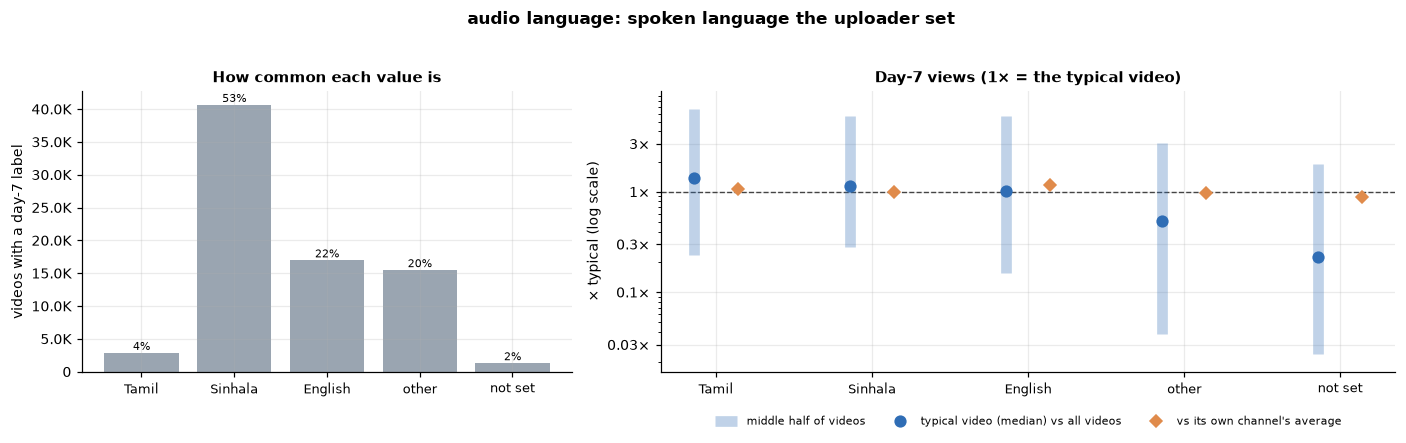

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
audio language,,,,,,,
Tamil,"2,895",3.7%,1.6K,284 – 8.0K,1.37×,1.07×,569
Sinhala,"40,671",52.5%,1.4K,339 – 6.8K,1.15×,1.00×,"3,911"
English,"16,997",22.0%,1.2K,186 – 6.8K,1.02×,1.16×,"3,130"
other,"15,504",20.0%,617,46 – 3.7K,0.52×,0.97×,"11,981"
not set,"1,332",1.7%,268,29 – 2.3K,0.22×,0.88×,"1,281"


**Source at forecast time:** on the form. Most common value: **Sinhala** (53% of videos). Best: **Tamil** (1.6K views, 1.37× typical). Worst: **not set** (268, 0.22×). Against its own channel (20,872 videos from the 545 channels that use more than one value): best **English** (1.16×), worst **not set** (0.88×): a **1.32×** gap. Largest gap inside one channel-size band: **1.66×** (channels with 1K–10K subscribers). Explains **3.4%** of the variation in day-7 views.

In [25]:
S["audio language"] = L.show(d, f, "audio language")

**What it shows.** Tamil (1.4×) and Sinhala (1.15×) videos get more views than
English (1.0×). Videos with no audio language set do worst (0.22×), probably
because careful uploaders set it. Within the same channel, English videos do a
little better than the channel's other languages. **Verdict: keep.**

## default language

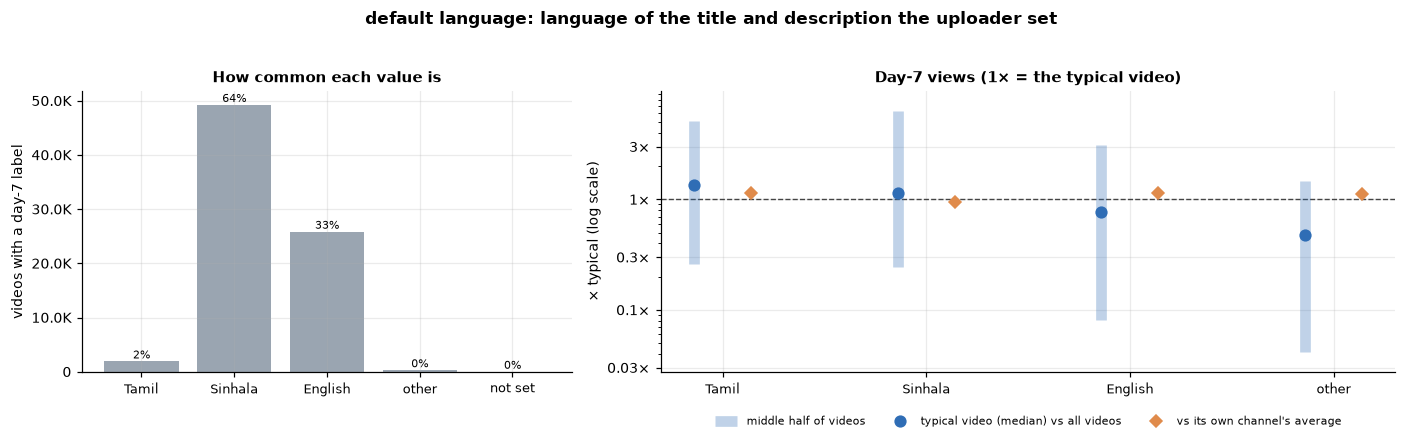

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
default language,,,,,,,
Tamil,"1,934",2.5%,1.6K,310 – 6.2K,1.35×,1.13×,809
Sinhala,"49,267",63.7%,1.4K,292 – 7.6K,1.14×,0.95×,"23,608"
English,"25,856",33.4%,926,96 – 3.7K,0.77×,1.13×,"9,556"
other,315,0.4%,567,50 – 1.8K,0.47×,1.11×,219
not set,27,0.0%,135,46 – 490,0.11×,,24


**Source at forecast time:** on the form (mapped from audio language). Most common value: **Sinhala** (64% of videos). Best: **Tamil** (1.6K views, 1.35× typical). Worst: **other** (567, 0.47×). Against its own channel (34,216 videos from the 582 channels that use more than one value): best **English** (1.13×), worst **Sinhala** (0.95×): a **1.20×** gap. Largest gap inside one channel-size band: **1.82×** (channels with 100K–1M subscribers). Explains **1.9%** of the variation in day-7 views.

In [26]:
S["default language"] = L.show(d, f, "default language")

**What it shows.** Similar to audio language, and they agree on only 58% of
videos. The API sends audio language mapped to en / si / ta, so the model
should be trained on that same mapping (section 17). **Verdict: keep one;
audio language is the one the form collects.**

## title script

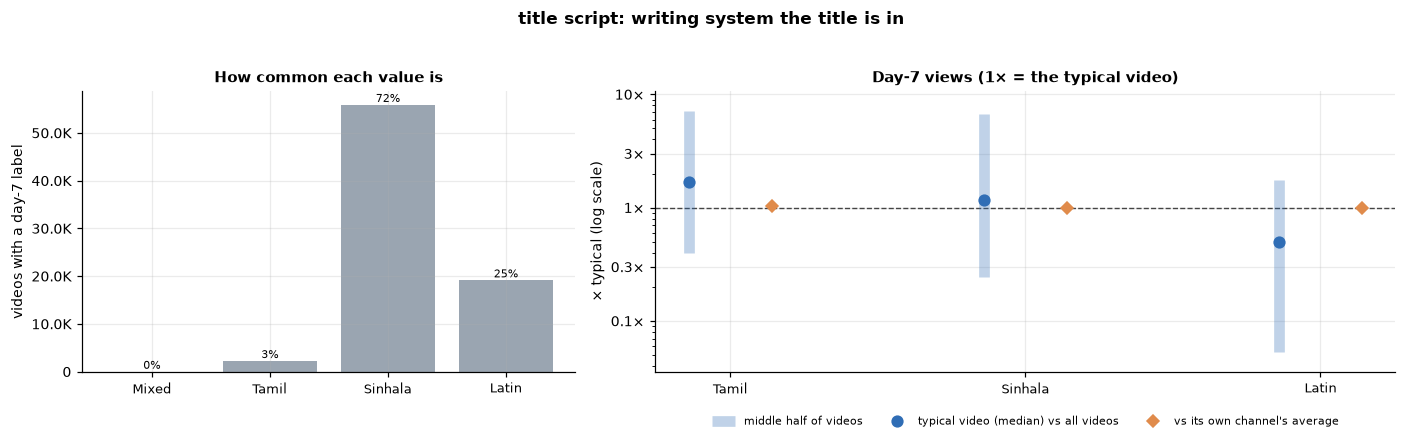

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
title script,,,,,,,
Mixed,23,0.0%,7.3K,4.7K – 11.1K,6.1×,,21
Tamil,"2,272",2.9%,2.0K,480 – 8.5K,1.68×,1.03×,"1,338"
Sinhala,"55,922",72.3%,1.4K,292 – 8.1K,1.18×,1.00×,"41,362"
Latin,"19,182",24.8%,599,64 – 2.1K,0.50×,0.98×,"11,017"


**Source at forecast time:** worked out from the title (not sent yet). Most common value: **Sinhala** (72% of videos). Best: **Tamil** (2.0K views, 1.68× typical). Worst: **Latin** (599, 0.50×). Against its own channel (53,738 videos from the 805 channels that use more than one value): best **Tamil** (1.03×), worst **Latin** (0.98×): a **1.05×** gap. Largest gap inside one channel-size band: **1.64×** (channels with 1M+ subscribers). Explains **4.0%** of the variation in day-7 views.

In [27]:
S["title script"] = L.show(d, f, "title script")

**What it shows.** Titles in Tamil script (1.7×) and Sinhala script (1.2×) do
better than Latin-script titles (0.5×). Within a channel the difference almost
disappears (1.05×): the raw gap is mostly which channels write in which script.
It passes the rule only through the biggest channels. **Verdict: keep, weak.
It is worked out from the title, which the form already collects.**

---
# 7. Publish timing

All times are Sri Lanka time.

## publish hour

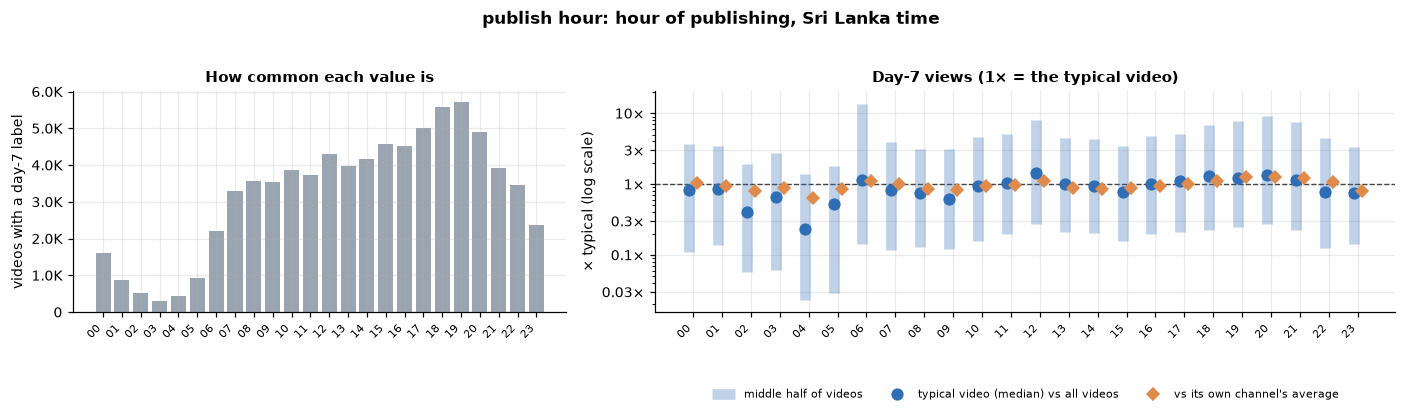

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
publish hour,,,,,,,
00,"1,610",2.1%,1000,132 – 4.3K,0.84×,1.05×,"1,524"
01,869,1.1%,1.0K,166 – 4.1K,0.86×,0.93×,855
02,530,0.7%,490,68 – 2.3K,0.41×,0.80×,501
03,310,0.4%,794,73 – 3.3K,0.66×,0.87×,299
04,436,0.6%,278,28 – 1.7K,0.23×,0.64×,404
05,931,1.2%,628,35 – 2.2K,0.52×,0.84×,903
06,"2,194",2.8%,1.4K,169 – 16.4K,1.13×,1.10×,"2,141"
07,"3,308",4.3%,1.0K,142 – 4.7K,0.84×,1.00×,"3,240"
08,"3,569",4.6%,906,156 – 3.7K,0.76×,0.85×,"3,450"


**Source at forecast time:** on the form (optional). Most common value: **19** (7% of videos). Best: **12** (1.7K views, 1.44× typical). Worst: **04** (278, 0.23×). Against its own channel (74,693 videos from the 1,442 channels that use more than one value): best **19** (1.25×), worst **04** (0.64×): a **1.94×** gap. Largest gap inside one channel-size band: **2.95×** (channels with 1M+ subscribers). Explains **1.7%** of the variation in day-7 views.

In [28]:
S["publish hour"] = L.show(d, f, "publish hour")

**What it shows.** Most videos go out between 07:00 and 21:00, peaking at 19:00.
Evening (18:00 to 21:00) is best both raw and within the same channel; 02:00
to 05:00 is worst. Within a channel the best hour gets about 1.9× the worst.
**Verdict: keep.** The form asks for the hour as optional, which is right.

## publish time band

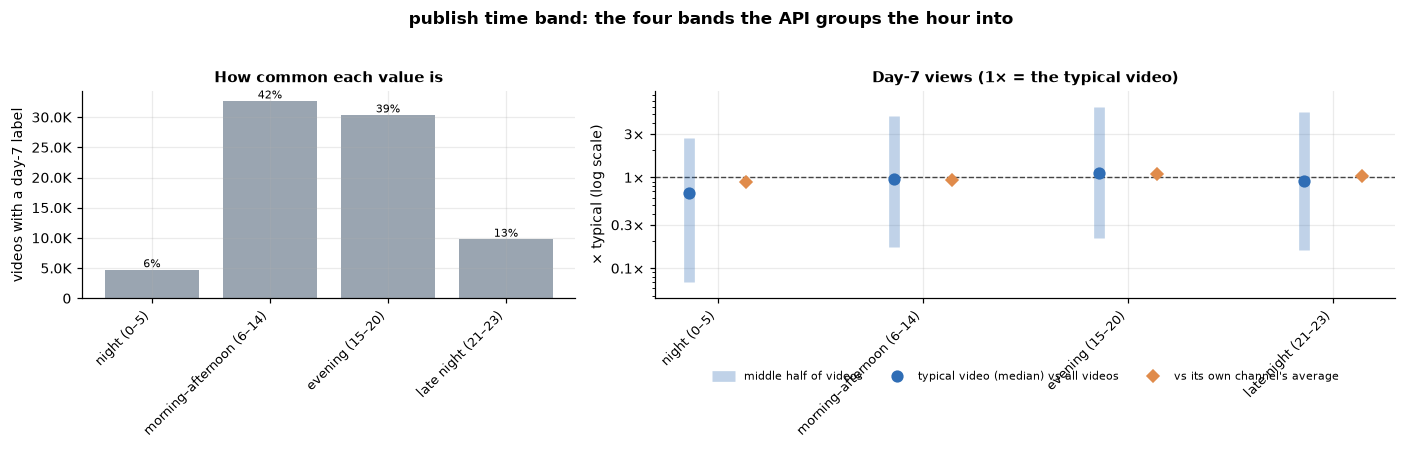

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
publish time band,,,,,,,
night (0–5),"4,686",6.1%,814,84 – 3.2K,0.68×,0.90×,"4,291"
morning–afternoon (6–14),"32,644",42.2%,1.1K,204 – 5.7K,0.95×,0.94×,"31,683"
evening (15–20),"30,327",39.2%,1.3K,255 – 7.1K,1.12×,1.08×,"27,394"
late night (21–23),"9,742",12.6%,1.1K,191 – 6.3K,0.92×,1.05×,"9,514"


**Source at forecast time:** on the form (optional). Most common value: **morning–afternoon (6–14)** (42% of videos). Best: **evening (15–20)** (1.3K views, 1.12× typical). Worst: **night (0–5)** (814, 0.68×). Against its own channel (72,882 videos from the 1,312 channels that use more than one value): best **evening (15–20)** (1.08×), worst **night (0–5)** (0.90×): a **1.20×** gap. Largest gap inside one channel-size band: **1.46×** (channels with 1M+ subscribers). Explains **0.6%** of the variation in day-7 views.

In [29]:
S["publish time band"] = L.show(d, f, "publish time band")

**What it shows.** The API groups the hour into four bands. Grouping loses most
of the difference: evening is best, but the four bands are within 1.2× of each
other. **Verdict: keep, but sending the exact hour would keep more
information than the band.**

## publish weekday

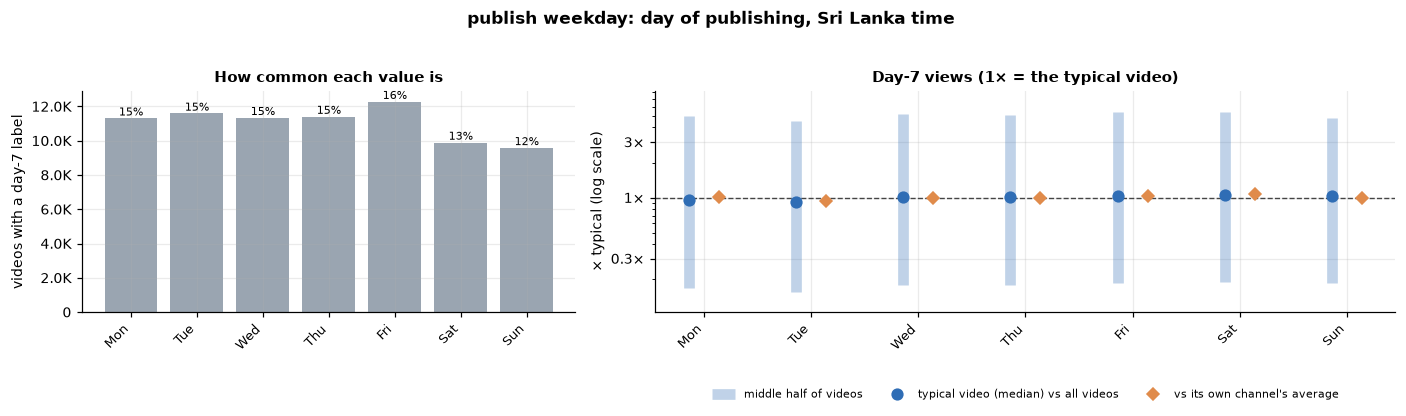

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
publish weekday,,,,,,,
Mon,"11,309",14.6%,1.1K,199 – 6.0K,0.95×,1.00×,"11,104"
Tue,"11,592",15.0%,1.1K,187 – 5.4K,0.92×,0.93×,"11,358"
Wed,"11,339",14.7%,1.2K,214 – 6.2K,1.01×,0.98×,"11,098"
Thu,"11,407",14.7%,1.2K,212 – 6.1K,1.00×,1.00×,"11,143"
Fri,"12,275",15.9%,1.2K,220 – 6.5K,1.03×,1.04×,"11,985"
Sat,"9,895",12.8%,1.3K,227 – 6.5K,1.06×,1.06×,"9,631"
Sun,"9,582",12.4%,1.2K,220 – 5.8K,1.02×,1.00×,"9,319"


**Source at forecast time:** on the form (optional). Most common value: **Fri** (16% of videos). Best: **Sat** (1.3K views, 1.06× typical). Worst: **Tue** (1.1K, 0.92×). Against its own channel (75,638 videos from the 1,512 channels that use more than one value): best **Sat** (1.06×), worst **Tue** (0.93×): a **1.15×** gap. Largest gap inside one channel-size band: **1.31×** (channels with <1K subscribers). Explains **0.1%** of the variation in day-7 views.

In [30]:
S["publish weekday"] = L.show(d, f, "publish weekday")

**What it shows.** Views are almost the same on every day (0.92× to 1.06×).
It passes the rule only for the smallest channels. **Verdict: keep, weak.**

## weekend

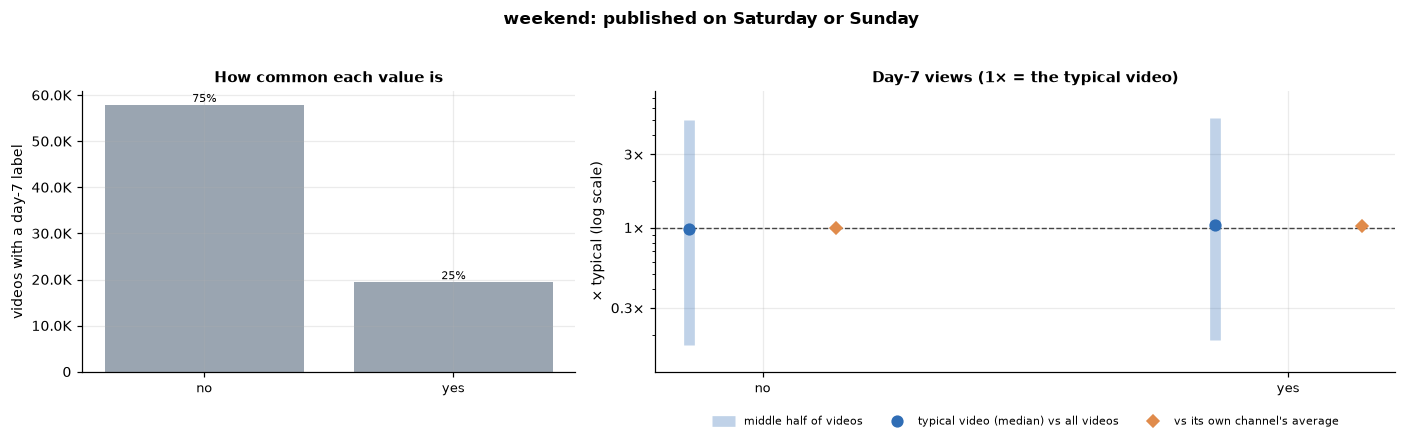

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
weekend,,,,,,,
no,"57,922",74.8%,1.2K,207 – 6.0K,0.99×,0.99×,"55,139"
yes,"19,477",25.2%,1.2K,223 – 6.2K,1.04×,1.03×,"18,916"


**Source at forecast time:** on the form (optional). Most common value: **no** (75% of videos). Best: **yes** (1.2K views, 1.04× typical). Worst: **no** (1.2K, 0.99×). Against its own channel (74,055 videos from the 1,383 channels that use more than one value): best **yes** (1.03×), worst **no** (0.99×): a **1.04×** gap. Largest gap inside one channel-size band: **1.07×** (channels with <1K subscribers). Explains **0.0%** of the variation in day-7 views.

In [31]:
S["weekend"] = L.show(d, f, "weekend")

**What it shows.** No difference (1.04×). **Verdict: drop.** The weekday
carries anything weekend could, and neither matters much.

---
# 8. Title

The title is typed on the form but is not used by the forecast today (only
for tone advice). These inputs could be worked out from it for free.

## title length

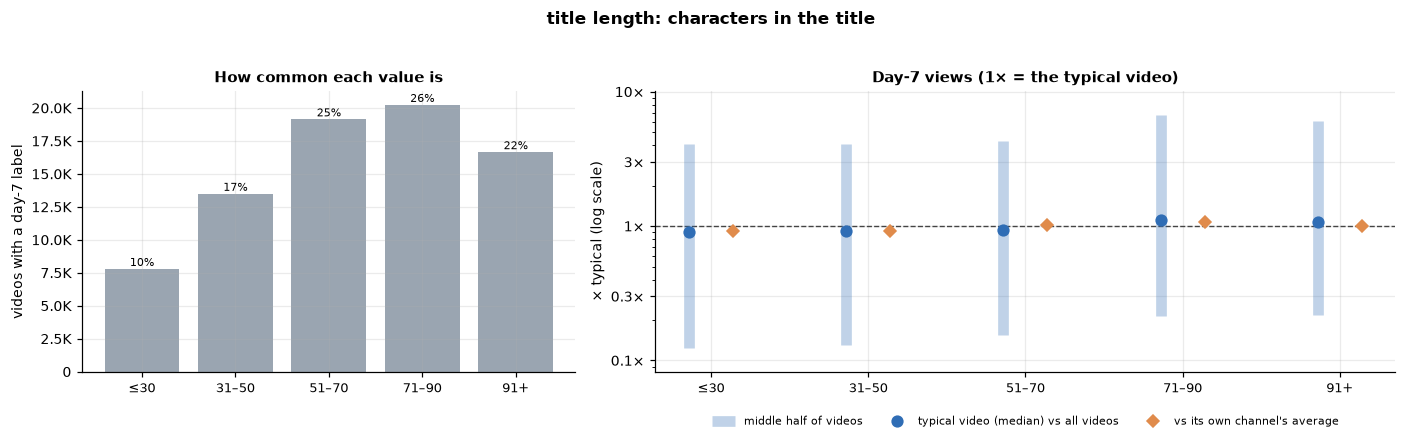

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
title length,,,,,,,
≤30,"7,810",10.1%,1.1K,148 – 4.9K,0.91×,0.91×,"7,273"
31–50,"13,509",17.5%,1.1K,156 – 4.9K,0.92×,0.92×,"13,113"
51–70,"19,160",24.8%,1.1K,185 – 5.1K,0.93×,1.02×,"18,692"
71–90,"20,252",26.2%,1.3K,258 – 8.0K,1.12×,1.08×,"19,644"
91+,"16,668",21.5%,1.3K,259 – 7.3K,1.07×,1.00×,"15,358"


**Source at forecast time:** worked out from the title (not sent yet). Most common value: **71–90** (26% of videos). Best: **71–90** (1.3K views, 1.12× typical). Worst: **≤30** (1.1K, 0.91×). Against its own channel (74,080 videos from the 1,443 channels that use more than one value): best **71–90** (1.08×), worst **≤30** (0.91×): a **1.18×** gap. Largest gap inside one channel-size band: **1.53×** (channels with 1M+ subscribers). Explains **0.6%** of the variation in day-7 views.

In [32]:
S["title length"] = L.show(d, f, "title length")

**What it shows.** Longer titles (over 70 characters) get slightly more views,
raw and within a channel (1.18× gap). **Verdict: keep, weak.** It repeats word
count (section 16), so one of the two is enough.

## title word count

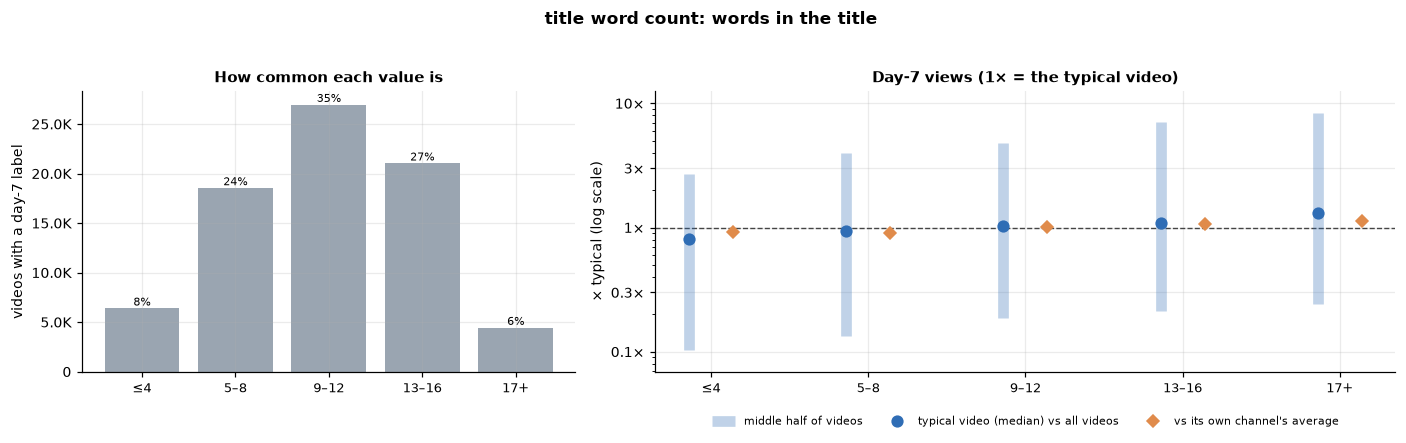

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
title word count,,,,,,,
≤4,"6,396",8.3%,975,124 – 3.3K,0.81×,0.92×,"6,008"
5–8,"18,551",24.0%,1.1K,160 – 4.7K,0.94×,0.90×,"17,783"
9–12,"26,959",34.8%,1.2K,222 – 5.8K,1.02×,1.01×,"26,219"
13–16,"21,047",27.2%,1.3K,252 – 8.5K,1.09×,1.08×,"20,359"
17+,"4,446",5.7%,1.6K,292 – 10.0K,1.32×,1.14×,"4,223"


**Source at forecast time:** worked out from the title (not sent yet). Most common value: **9–12** (35% of videos). Best: **17+** (1.6K views, 1.32× typical). Worst: **≤4** (975, 0.81×). Against its own channel (74,592 videos from the 1,460 channels that use more than one value): best **17+** (1.14×), worst **5–8** (0.90×): a **1.27×** gap. Largest gap inside one channel-size band: **2.00×** (channels with 1M+ subscribers). Explains **0.8%** of the variation in day-7 views.

In [33]:
S["title word count"] = L.show(d, f, "title word count")

**What it shows.** The same pattern as title length, a little clearer (1.27×
within a channel). **Verdict: keep instead of title length.**

## number in title

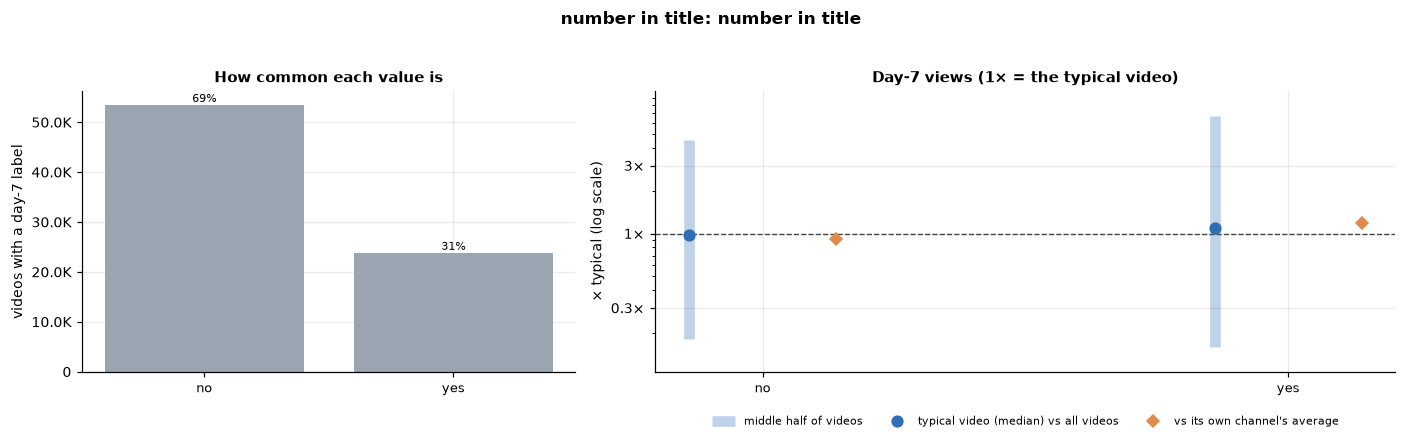

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
number in title,,,,,,,
no,"53,525",69.2%,1.2K,219 – 5.4K,0.97×,0.92×,"45,873"
yes,"23,874",30.8%,1.3K,192 – 8.0K,1.09×,1.19×,"21,021"


**Source at forecast time:** worked out from the title (not sent yet). Most common value: **no** (69% of videos). Best: **yes** (1.3K views, 1.09× typical). Worst: **no** (1.2K, 0.97×). Against its own channel (66,894 videos from the 1,098 channels that use more than one value): best **yes** (1.19×), worst **no** (0.92×): a **1.29×** gap. Largest gap inside one channel-size band: **1.79×** (channels with 1M+ subscribers). Explains **0.0%** of the variation in day-7 views.

In [34]:
S["number in title"] = L.show(d, f, "number in title")

**What it shows.** No difference raw, but within the same channel, titles with
a number get about 1.3× those without. Numbers often mark episodes or lists.
**Verdict: keep (moderate).**

## question mark in title

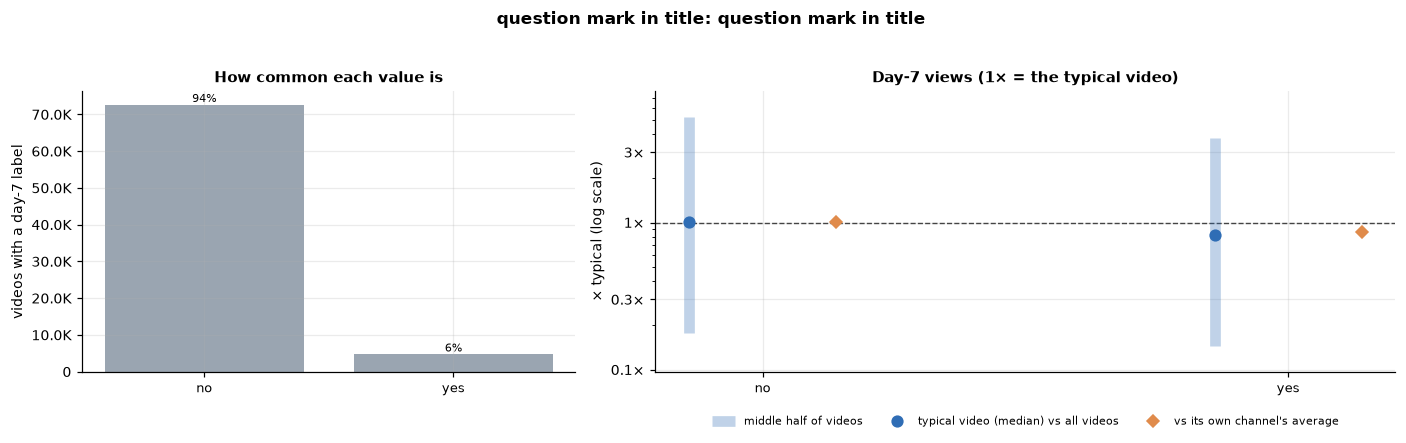

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
question mark in title,,,,,,,
no,"72,663",93.9%,1.2K,213 – 6.2K,1.01×,1.01×,"51,381"
yes,"4,736",6.1%,985,174 – 4.5K,0.82×,0.86×,"4,615"


**Source at forecast time:** worked out from the title (not sent yet). Most common value: **no** (94% of videos). Best: **no** (1.2K views, 1.01× typical). Worst: **yes** (985, 0.82×). Against its own channel (55,996 videos from the 648 channels that use more than one value): best **no** (1.01×), worst **yes** (0.86×): a **1.18×** gap. Largest gap inside one channel-size band: **1.38×** (channels with 1M+ subscribers). Explains **0.0%** of the variation in day-7 views.

In [35]:
S["question mark in title"] = L.show(d, f, "question mark in title")

**What it shows.** Only 6% of titles have one, and they do slightly worse.
**Verdict: keep, weak.**

## exclamation mark in title

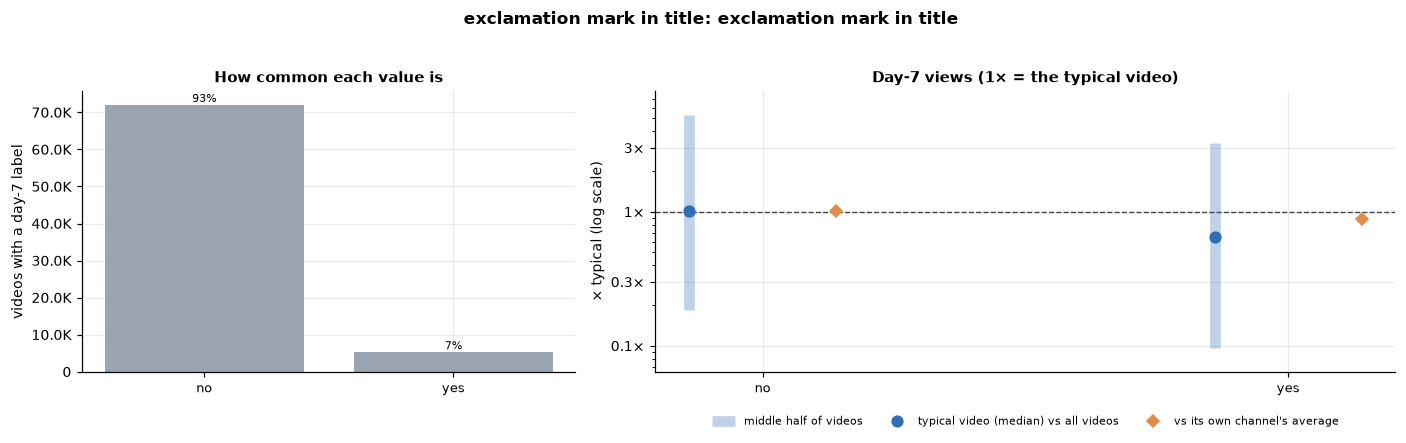

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
exclamation mark in title,,,,,,,
no,"72,070",93.1%,1.2K,222 – 6.3K,1.02×,1.01×,"45,958"
yes,"5,329",6.9%,771,115 – 3.9K,0.64×,0.89×,"5,078"


**Source at forecast time:** worked out from the title (not sent yet). Most common value: **no** (93% of videos). Best: **no** (1.2K views, 1.02× typical). Worst: **yes** (771, 0.64×). Against its own channel (51,036 videos from the 601 channels that use more than one value): best **no** (1.01×), worst **yes** (0.89×): a **1.14×** gap. Largest gap inside one channel-size band: **1.47×** (channels with 1M+ subscribers). Explains **0.4%** of the variation in day-7 views.

In [36]:
S["exclamation mark in title"] = L.show(d, f, "exclamation mark in title")

**What it shows.** Only 7% of titles have one. They look much worse raw (0.64×)
but only slightly worse within a channel: the channels that use them are
smaller. **Verdict: keep, weak.**

## capital letters in title

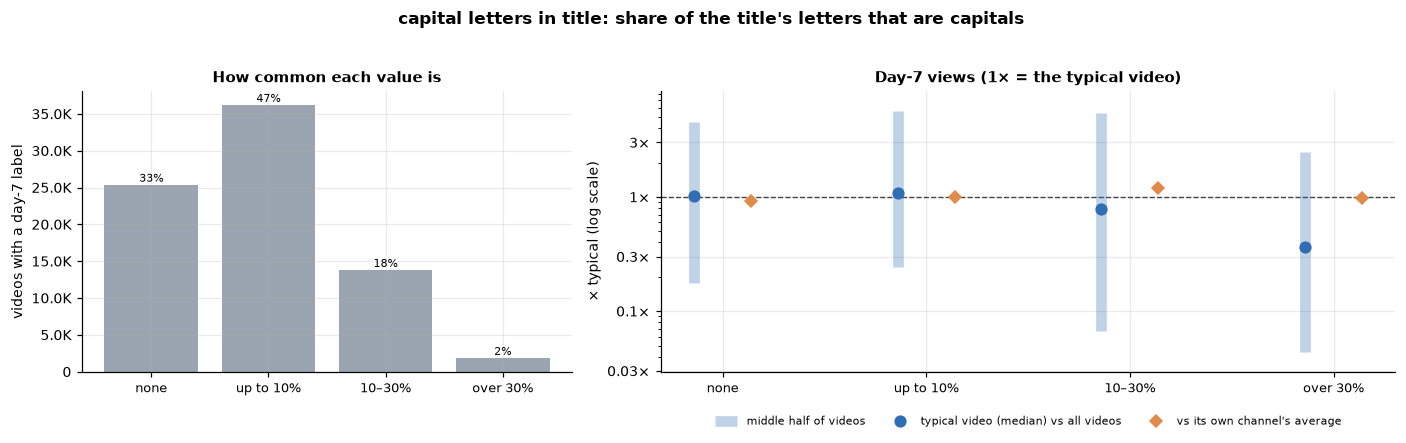

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
capital letters in title,,,,,,,
none,"25,412",32.8%,1.2K,213 – 5.4K,1.01×,0.91×,"23,641"
up to 10%,"36,246",46.8%,1.3K,289 – 6.7K,1.08×,1.00×,"32,609"
10–30%,"13,843",17.9%,942,80 – 6.5K,0.79×,1.20×,"12,616"
over 30%,"1,898",2.5%,437,53 – 3.0K,0.37×,0.97×,"1,755"


**Source at forecast time:** worked out from the title (not sent yet). Most common value: **up to 10%** (47% of videos). Best: **up to 10%** (1.3K views, 1.08× typical). Worst: **over 30%** (437, 0.37×). Against its own channel (70,621 videos from the 1,277 channels that use more than one value): best **10–30%** (1.20×), worst **none** (0.91×): a **1.31×** gap. Largest gap inside one channel-size band: **2.72×** (channels with 1M+ subscribers). Explains **1.2%** of the variation in day-7 views.

In [37]:
S["capital letters in title"] = L.show(d, f, "capital letters in title")

**What it shows.** Raw, titles with over 30% capitals do badly (0.37×). Within
the same channel, a moderate amount (10 to 30%) is best and none is worst
(1.31× gap). **Verdict: keep (moderate).** Shouting titles belong to smaller
channels; a few capitals help.

---
# 9. Tags and description

Neither is on the form today, so using them would need two new form fields.

## tag count

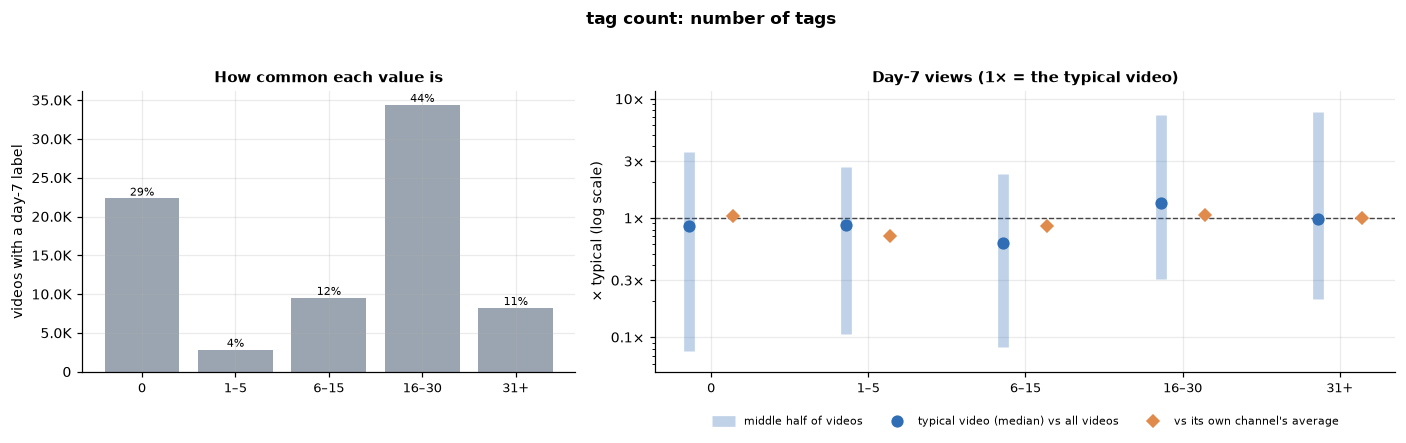

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
tag count,,,,,,,
0,"22,341",28.9%,1.0K,92 – 4.3K,0.85×,1.04×,"9,252"
1–5,"2,858",3.7%,1.0K,126 – 3.2K,0.87×,0.71×,"2,352"
6–15,"9,545",12.3%,736,99 – 2.8K,0.61×,0.86×,"7,648"
16–30,"34,415",44.5%,1.6K,366 – 8.7K,1.33×,1.07×,"23,444"
31+,"8,240",10.6%,1.2K,249 – 9.2K,0.98×,1.01×,"6,859"


**Source at forecast time:** not on the form. Most common value: **16–30** (44% of videos). Best: **16–30** (1.6K views, 1.33× typical). Worst: **6–15** (736, 0.61×). Against its own channel (49,555 videos from the 848 channels that use more than one value): best **16–30** (1.07×), worst **1–5** (0.71×): a **1.50×** gap. Largest gap inside one channel-size band: **1.56×** (channels with 1M+ subscribers). Explains **3.0%** of the variation in day-7 views.

In [38]:
S["tag count"] = L.show(d, f, "tag count")

**What it shows.** 16 to 30 tags is best raw (1.33×). Within a channel, videos
with 1 to 5 tags do worst (0.71×) and 16 to 30 best, a 1.5× gap. It explains
3% on its own, more than any title input. **Verdict: keep; needs a form field.**

## description length

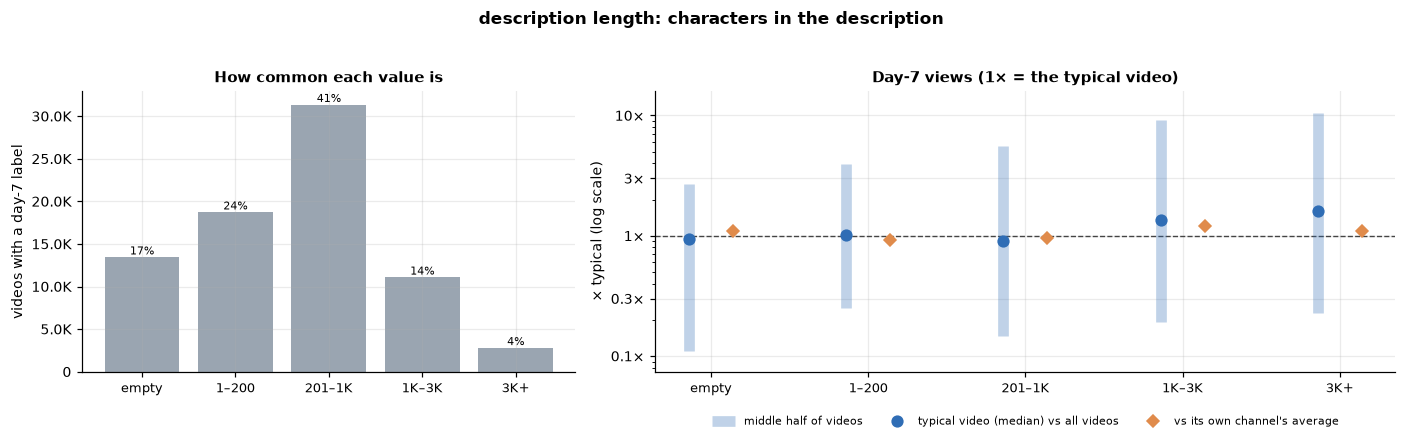

,videos,share,median day-7 views,middle half,× typical,× own channel,videos in own-channel view
description length,,,,,,,
empty,"13,443",17.4%,1.1K,133 – 3.2K,0.94×,1.09×,"7,582"
1–200,"18,727",24.2%,1.2K,303 – 4.7K,1.02×,0.92×,"16,896"
201–1K,"31,350",40.5%,1.1K,174 – 6.6K,0.91×,0.96×,"20,698"
1K–3K,"11,078",14.3%,1.6K,229 – 10.9K,1.34×,1.20×,"8,354"
3K+,"2,801",3.6%,1.9K,272 – 12.7K,1.62×,1.10×,"1,870"


**Source at forecast time:** not on the form. Most common value: **201–1K** (41% of videos). Best: **3K+** (1.9K views, 1.62× typical). Worst: **201–1K** (1.1K, 0.91×). Against its own channel (55,400 videos from the 1,021 channels that use more than one value): best **1K–3K** (1.20×), worst **1–200** (0.92×): a **1.30×** gap. Largest gap inside one channel-size band: **1.65×** (channels with 1M+ subscribers). Explains **0.7%** of the variation in day-7 views.

In [39]:
S["description length"] = L.show(d, f, "description length")

**What it shows.** Long descriptions (over 1,000 characters) get more views,
raw and within a channel (1.3× gap). **Verdict: keep; needs a form field.**

---
# 10. Category by category

Category changes what works. This section looks at each category separately,
using day-7 views. Categories with fewer than 1,000 labelled videos are grouped
as "Other".

In [40]:
CATS = L.main_categories(d, 1000)
cat = pd.Series(L.category_of(d, CATS), index=d.index)
lab = d.v7.notna()
subs = pd.to_numeric(d.ch_subs_at_publish, errors="coerce").where(~d.channel_stats_backfilled)
upd = (pd.to_numeric(d.ch_videos_at_publish, errors="coerce")
       / pd.to_numeric(d.channel_age_days_at_publish, errors="coerce").where(lambda s: s > 0))
prof = pd.DataFrame({
    "videos": d[lab].groupby(cat[lab], observed=True).size(),
    "channels": d[lab].groupby(cat[lab], observed=True).channel_id.nunique(),
    "median day-7 views": d[lab].groupby(cat[lab], observed=True).v7.median(),
    "% Shorts": d[lab].groupby(cat[lab], observed=True).is_short.mean() * 100,
    "median length (min)": pd.to_numeric(d.duration_seconds, errors="coerce")[lab].groupby(cat[lab], observed=True).median() / 60,
    "median channel subscribers": subs[lab].groupby(cat[lab], observed=True).median(),
    "median channel uploads per day": upd[lab].groupby(cat[lab], observed=True).median(),
}).sort_values("median day-7 views", ascending=False)
prof["videos per channel"] = prof.videos / prof.channels
display(prof.style.format({"videos": "{:,}", "channels": "{:,}", "median day-7 views": short,
                           "% Shorts": "{:.0f}%", "median length (min)": "{:.1f}",
                           "median channel subscribers": short, "median channel uploads per day": "{:.1f}",
                           "videos per channel": "{:.0f}"}))

,videos,channels,median day-7 views,% Shorts,median length (min),median channel subscribers,median channel uploads per day,videos per channel
Comedy,"1,735",73,5.6K,83%,0.4,41.9K,0.7,24
Entertainment,"9,582",152,3.9K,31%,1.9,3.3M,6.5,63
People & Blogs,"4,296",156,2.3K,28%,2.2,3.1M,2.3,28
Autos & Vehicles,"1,876",103,1.2K,73%,0.4,8.9K,0.5,18
Sports,"1,875",72,1.1K,37%,2.8,43.2K,0.6,26
Music,"5,512",351,1.1K,69%,1.0,22.7K,0.3,16
News & Politics,"23,885",57,1.1K,8%,2.2,3.8M,42.3,419
Pets & Animals,"1,665",73,962,89%,0.3,4.3K,0.5,23
Education,"10,794",524,926,54%,1.4,45.1K,0.4,21
Film & Animation,"1,638",138,919,52%,1.1,25.4K,0.2,12


**What this shows.** Categories differ in *who* posts, not just in content.

* **News & Politics** is 31% of videos but only 57 channels: about 420 labelled
  videos each, from channels posting about 42 videos a day with a median of
  3.8M subscribers. Only 8% are Shorts.
* **Comedy, Pets & Animals, Travel & Events and Autos & Vehicles** are mostly
  Shorts (73 to 89%) from small and mid-size channels.
* **Entertainment and People & Blogs** come from very large channels (over 3M
  subscribers typical), which is much of why they rank high.

## Is News & Politics skewing the results?

News & Politics is 31% of the labelled videos but comes from only about 60
channels, many posting dozens of clips a day. If it behaves differently from
everything else, it could be pulling the whole-dataset results in sections 4
to 9. This table repeats every input's day-7 result without it.

In [41]:
L.news_check(d, f, [n for n in f.columns if n not in ("channel country", "captions", "made for kids", "HD or SD", "category", "Short length")])

,"explains, all","explains, without News","best value, all","best value, without News","own-channel gap, all","own-channel gap, without News",what News changes
input,,,,,,,
subscribers,22.5%,33.6%,1M+,1M+,,,strength changes
channel video count,4.5%,8.9%,2K–10K,10K+,,,"best value changes, strength changes"
channel age,2.5%,3.5%,5–10 yr,10+ yr,,,"best value changes, strength changes"
channel average views per video,38.1%,43.3%,100K+,100K+,,,nothing much
channel uploads per day,3.5%,5.8%,2–10,10+,,,"best value changes, strength changes"
duration,1.6%,1.0%,20–60 min,20–60 min,2.59×,2.28×,"strength changes, own-channel gap changes"
Short or long-form,0.1%,0.2%,Short,long-form,1.17×,1.08×,best value changes
audio language,3.4%,4.3%,Tamil,Sinhala,1.32×,1.27×,best value changes
default language,1.9%,3.1%,Tamil,Tamil,1.20×,1.22×,strength changes


**What this shows.** Yes, News & Politics pulls several results, in three ways.

* **It hides how much channel size matters.** Without News, subscribers explain
  34% instead of 23%, channel video count 9% instead of 4.5%, and topic 14%
  instead of 10%. News channels are huge but get few views per clip, which
  breaks the "bigger channel, more views" pattern for everyone else.
* **It inflates some video-level effects.** News's rare Shorts, capitalised
  titles and long descriptions do very well against their own channel, so
  with News removed the own-channel gap falls for Shorts (1.17× to 1.08×),
  capital letters (1.31× to 1.10×), description length (1.30× to 1.19×) and
  publish hour (1.94× to 1.62×). Without News the best publish hour moves from
  12:00 to 21:00.
* **Raw best values flip for a few inputs:** Short or long-form (Shorts best
  with News, long-form best without), number in title and publish weekday.

**What does not change:** duration, publish time band, title length, language,
exclamation and question marks, and number in title against the own channel.
Tag count gets *stronger* without News (1.50× to 1.66×).

The Shorts finding by channel size also holds without News, and gets sharper.
Compared with their own long-form, Shorts are 2.0× for channels under 1K
subscribers and 1.4× to 1.9× up to 100K; for 1M+ channels outside News they are
0.43×.

**So:** results for one input over the whole dataset should be read with News in
mind. The per-category pages below remove the problem, because each one only
compares videos within the same category.

## Inside each category

One page per category. Each small chart is one input a creator controls, and
**1× is now the typical video in that category**, not across all videos. So the
chart answers: within Comedy (say), do Shorts, longer videos or evening posts do
better? The orange diamond again compares each video with its own channel. The
table under each page lists the best and worst value of every input.

### News & Politics

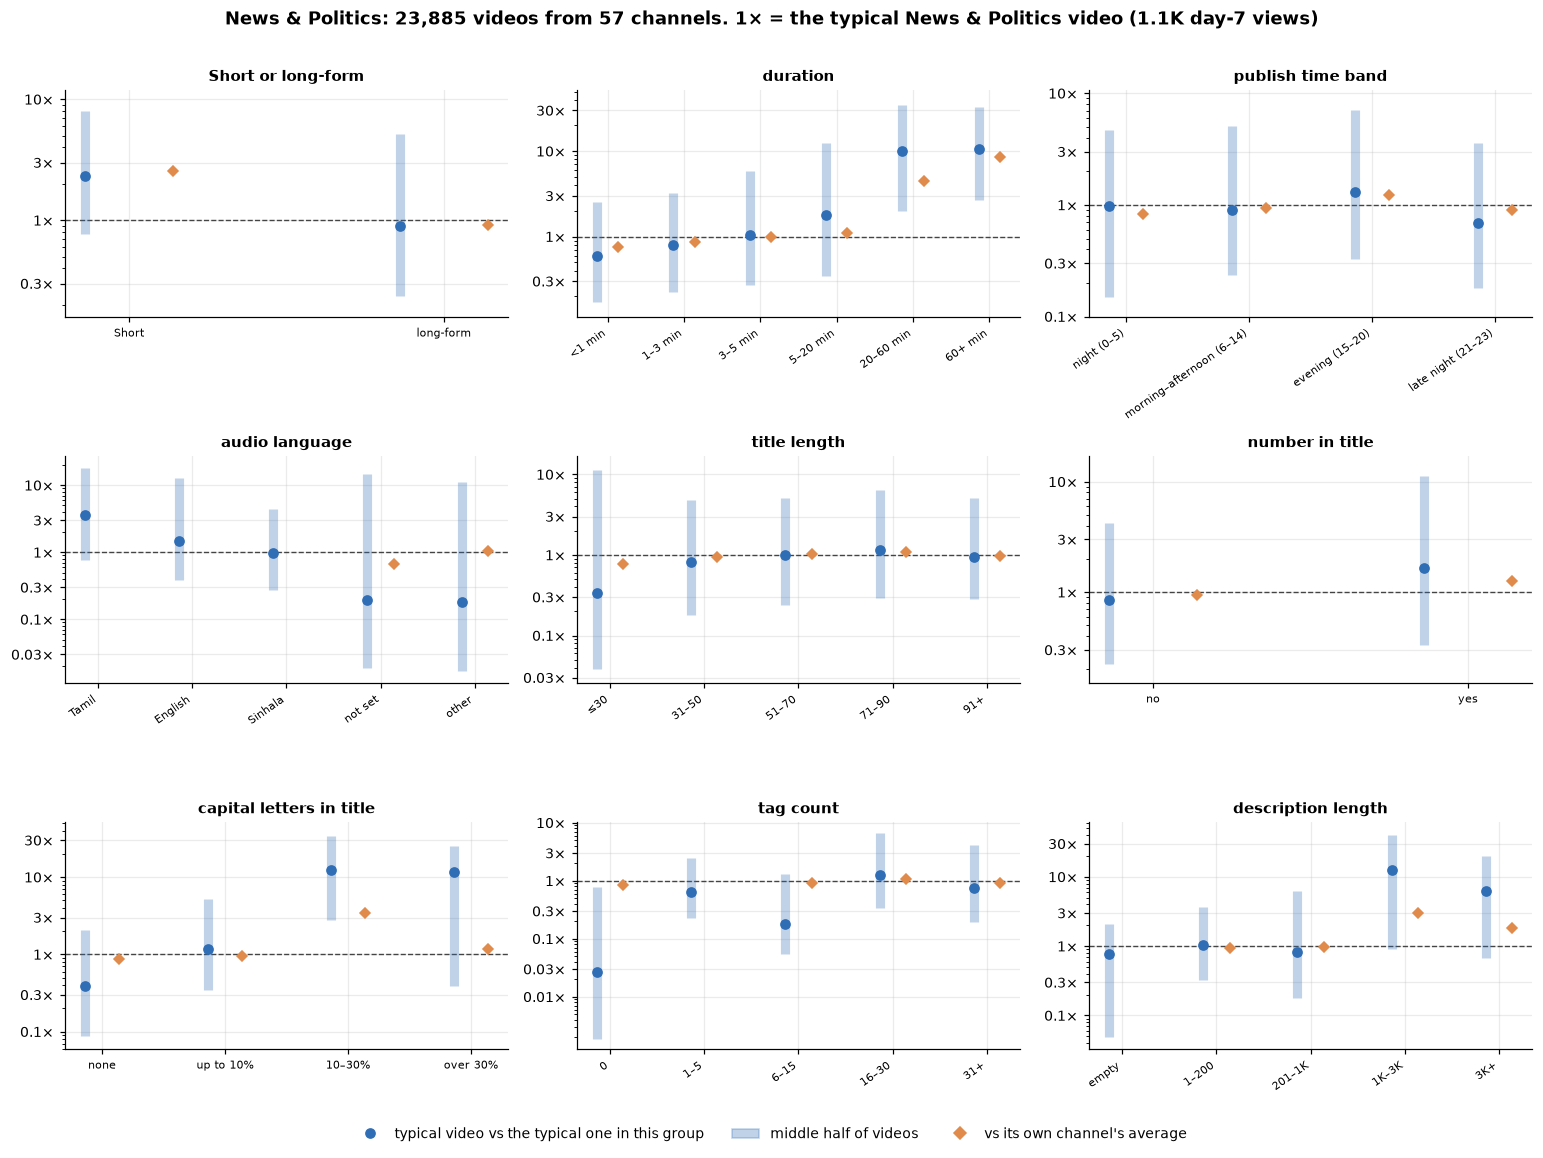

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (2.3×),long-form (0.90×),Short (2.6×),long-form (0.92×),2.79×
duration,60+ min (11×),<1 min (0.59×),60+ min (8.5×),<1 min (0.76×),11.20×
publish time band,evening (15–20) (1.31×),late night (21–23) (0.69×),evening (15–20) (1.22×),night (0–5) (0.82×),1.49×
audio language,Tamil (3.5×),other (0.18×),other (1.03×),not set (0.66×),1.56×
title length,71–90 (1.14×),≤30 (0.34×),71–90 (1.10×),≤30 (0.78×),1.41×
number in title,yes (1.66×),no (0.86×),yes (1.26×),no (0.93×),1.34×
capital letters in title,10–30% (12×),none (0.39×),10–30% (3.4×),none (0.87×),3.96×
tag count,16–30 (1.26×),0 (0.03×),16–30 (1.08×),6–15 (0.91×),1.19×
description length,1K–3K (13×),empty (0.77×),1K–3K (3.0×),1–200 (0.93×),3.20×


In [42]:
if "News & Politics" in CATS:
    L.category_page(d, f, "News & Politics")

**How to read these pages.** Inside a category, the **blue dots can still
mislead**: a handful of big channels decide most raw values (for example a
single high-volume channel that never uses tags). The **orange diamond** is the
reliable one, and the "vs own channel" columns in the table are the numbers to
quote.

**News & Politics.** Against their own channel, News videos do better when
they are Shorts (2.6×), long (60+ minutes, 8.5×), posted in the evening
(1.2×), have a number in the title (1.3×) and have some capitals or a long
description. These are the channel's *unusual* videos: most News channels post
2 to 5 minute clips, so the few streams and Shorts stand out. Tags make little
difference.

### Education

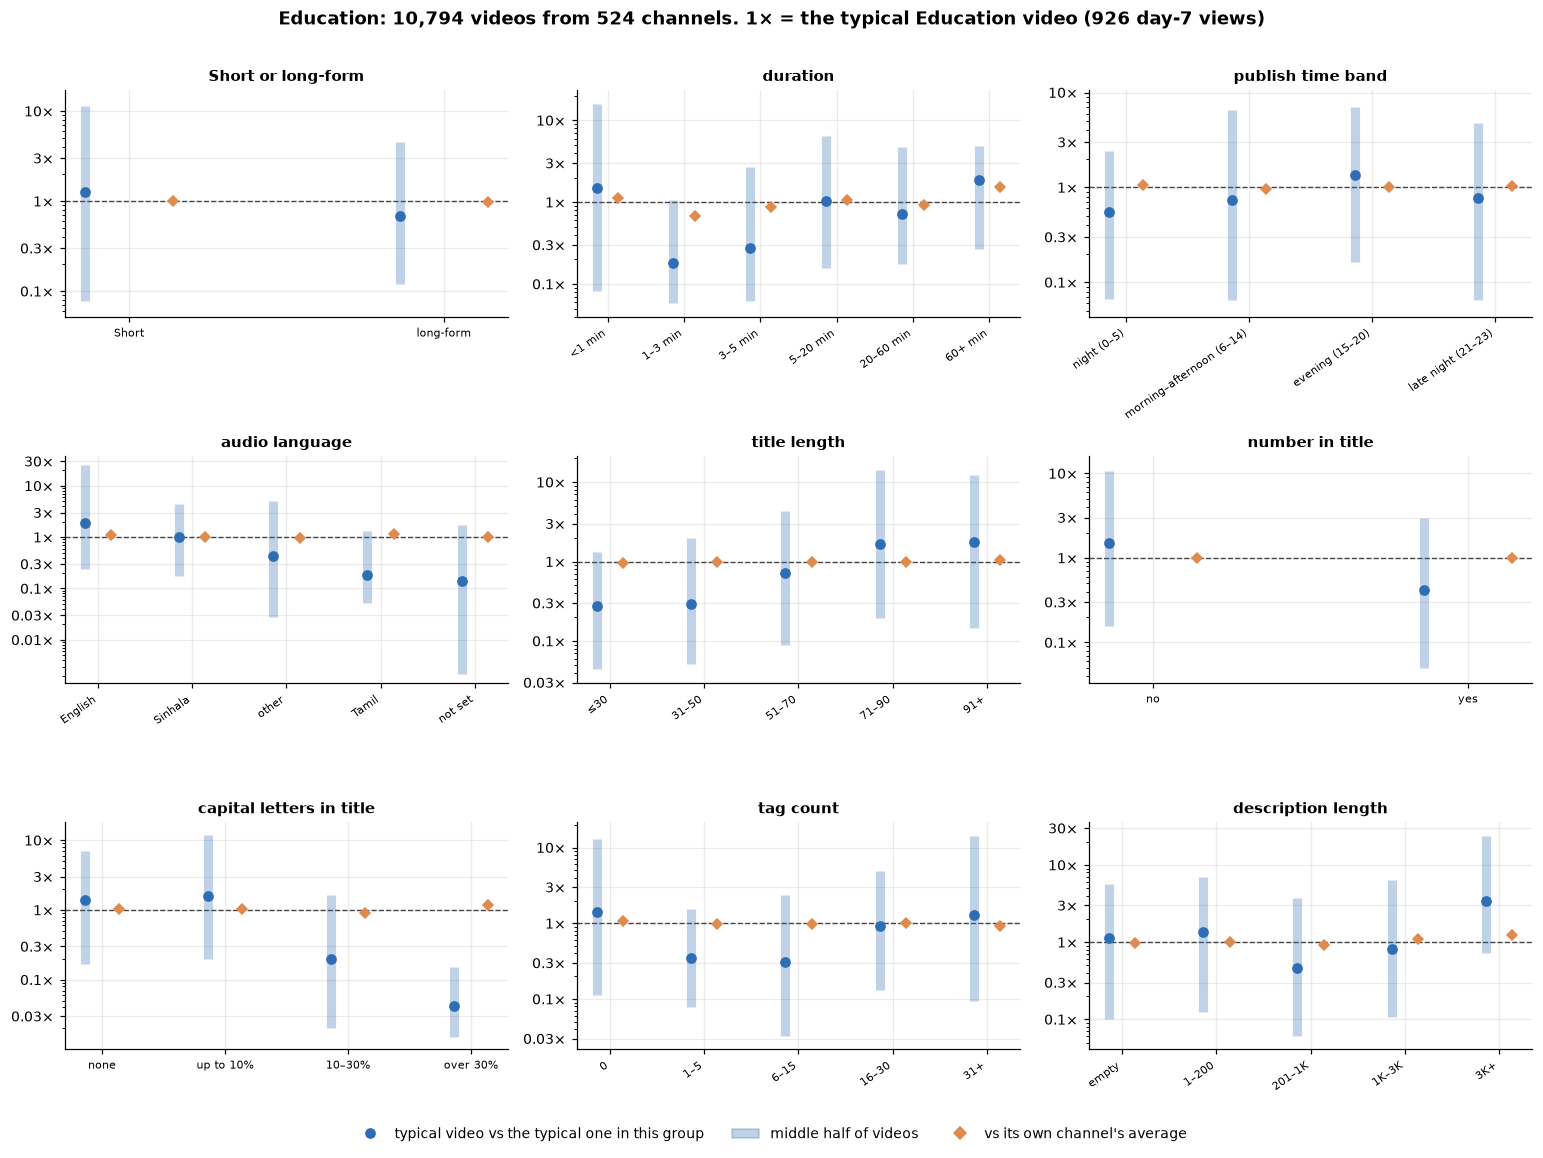

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (1.28×),long-form (0.68×),Short (1.01×),long-form (0.98×),1.03×
duration,60+ min (1.84×),1–3 min (0.18×),60+ min (1.54×),1–3 min (0.67×),2.29×
publish time band,evening (15–20) (1.34×),night (0–5) (0.54×),night (0–5) (1.06×),morning–afternoon (6–14) (0.97×),1.09×
audio language,English (1.92×),not set (0.14×),Tamil (1.16×),other (0.97×),1.19×
title length,91+ (1.77×),≤30 (0.27×),91+ (1.04×),≤30 (0.97×),1.08×
number in title,no (1.50×),yes (0.42×),no (1.01×),yes (0.99×),1.02×
capital letters in title,up to 10% (1.56×),over 30% (0.04×),over 30% (1.19×),10–30% (0.91×),1.31×
tag count,0 (1.41×),6–15 (0.30×),0 (1.06×),31+ (0.92×),1.16×
description length,3K+ (3.5×),201–1K (0.47×),3K+ (1.24×),201–1K (0.91×),1.37×


In [43]:
if "Education" in CATS:
    L.category_page(d, f, "Education")

**Education.** Most inputs make little difference within a channel. The
exceptions are **length** (60+ minute videos 1.5× the channel's average, 1 to 3
minutes 0.7×) and a **long description** (3K+ characters, 1.2×). Shorts against
long-form: no difference.

### Entertainment

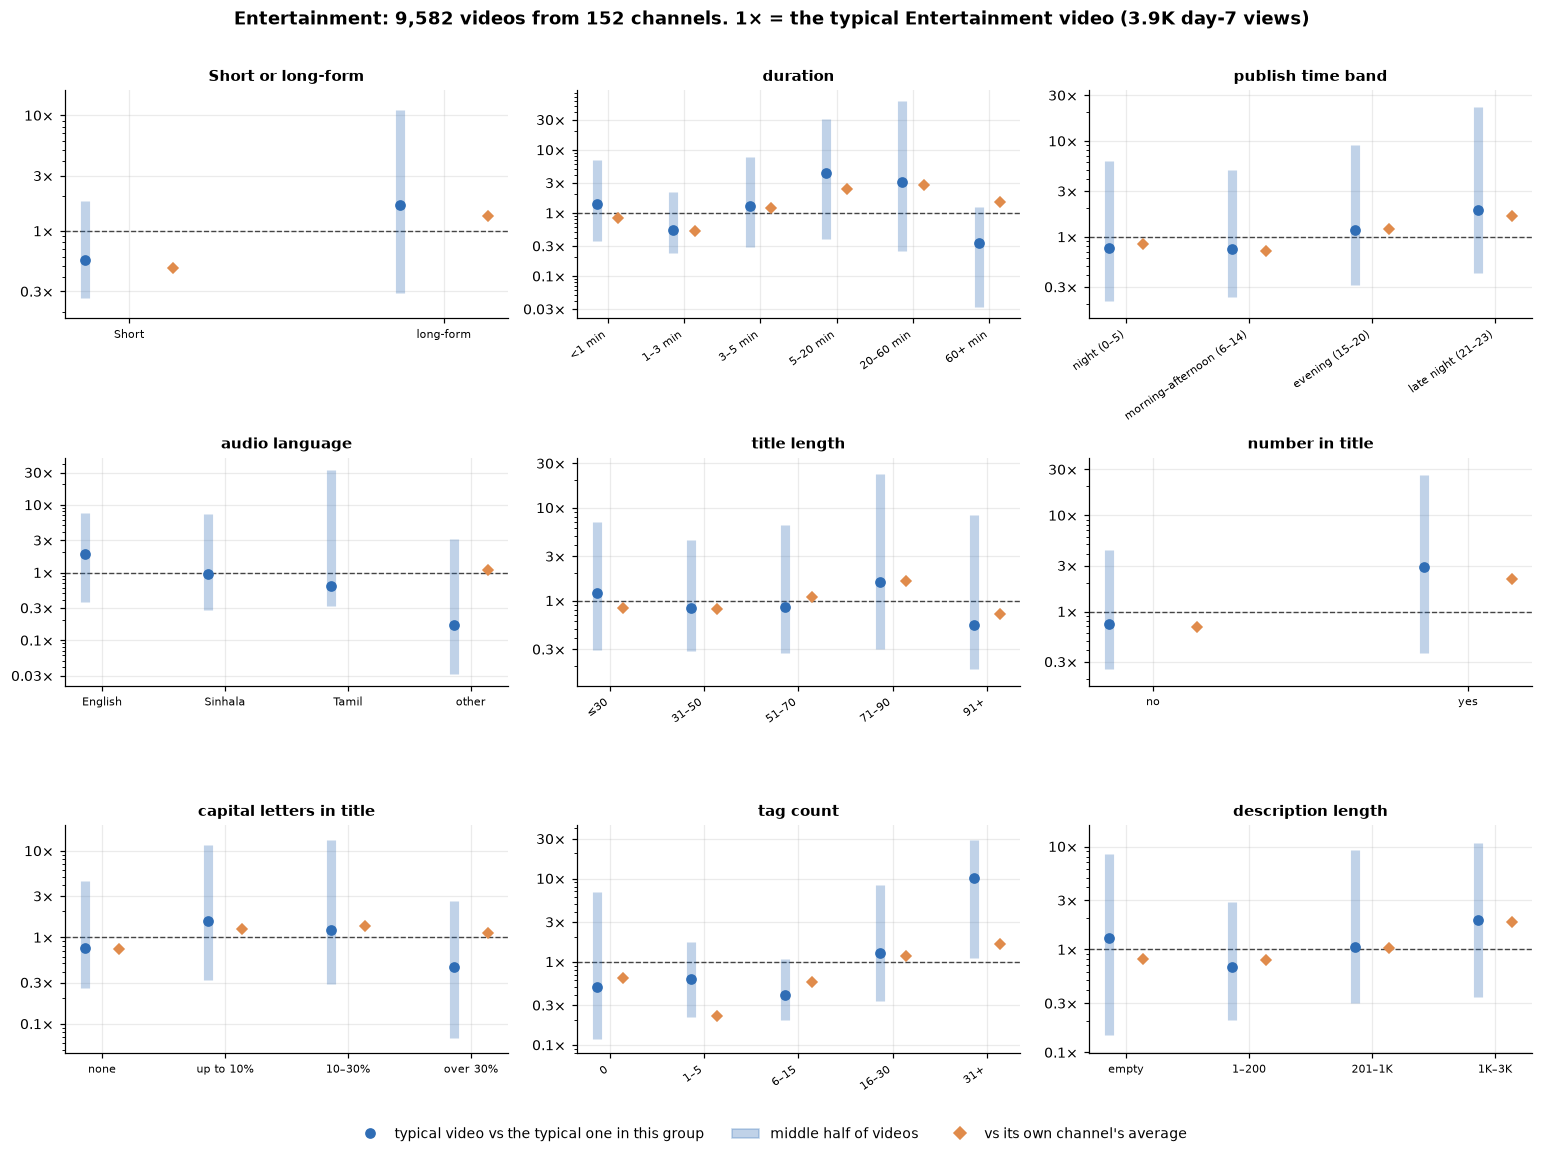

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,long-form (1.67×),Short (0.56×),long-form (1.34×),Short (0.48×),2.79×
duration,5–20 min (4.3×),60+ min (0.33×),20–60 min (2.8×),1–3 min (0.51×),5.52×
publish time band,late night (21–23) (1.92×),morning–afternoon (6–14) (0.75×),late night (21–23) (1.67×),morning–afternoon (6–14) (0.71×),2.34×
audio language,English (1.88×),other (0.17×),too few channels,,
title length,71–90 (1.60×),91+ (0.55×),71–90 (1.62×),91+ (0.73×),2.24×
number in title,yes (2.9×),no (0.75×),yes (2.2×),no (0.69×),3.19×
capital letters in title,up to 10% (1.54×),over 30% (0.46×),10–30% (1.34×),none (0.74×),1.82×
tag count,31+ (10×),6–15 (0.40×),31+ (1.63×),1–5 (0.23×),7.25×
description length,1K–3K (1.92×),1–200 (0.67×),1K–3K (1.83×),1–200 (0.79×),2.32×


In [44]:
if "Entertainment" in CATS:
    L.category_page(d, f, "Entertainment")

**Entertainment.** The category where creator choices matter most, and the one
that goes **against** the general Shorts advice: **long-form beats Shorts**
(1.3× against 0.5× the channel's average). Also better: 5 to 60 minute videos,
**late-night posting** (21:00 to 23:00, 1.7×), a **number in the title** (2.2×,
usually episode numbers), 71 to 90 character titles, **31+ tags** (1.6×; 1 to 5
tags 0.2×) and descriptions of 1K to 3K characters.

### Travel & Events

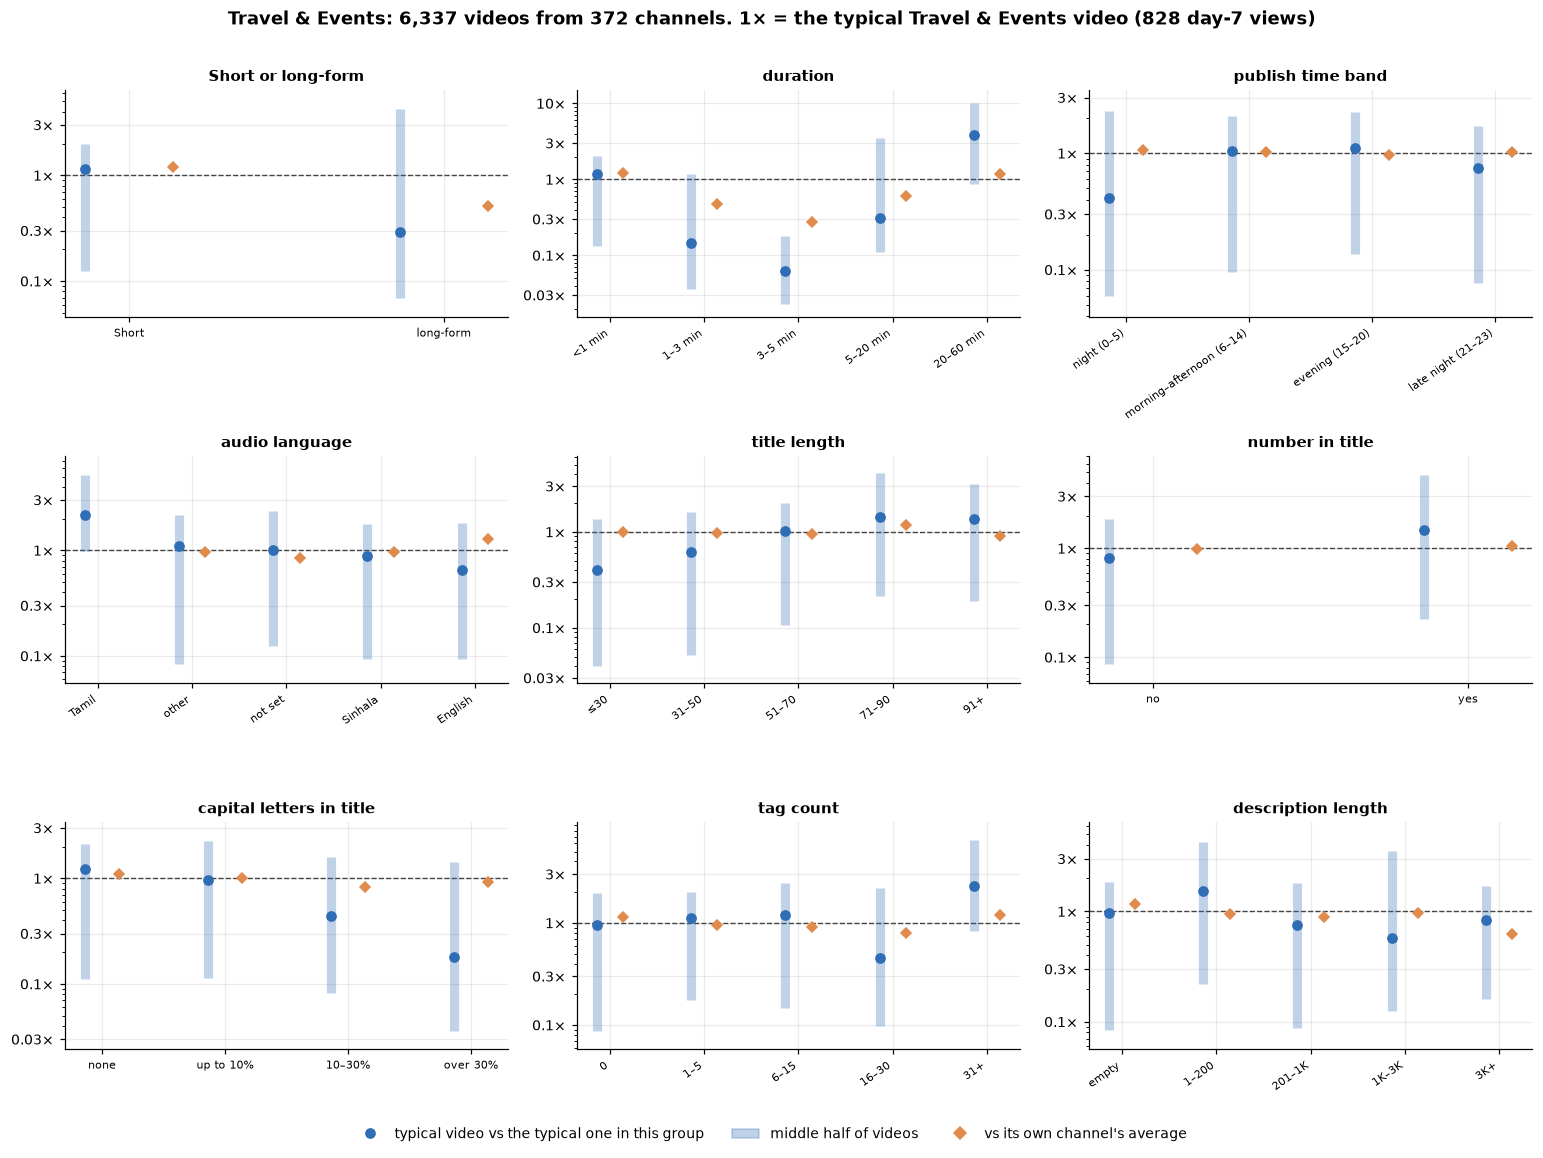

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (1.14×),long-form (0.29×),Short (1.21×),long-form (0.51×),2.38×
duration,20–60 min (3.8×),3–5 min (0.06×),<1 min (1.22×),3–5 min (0.28×),4.42×
publish time band,evening (15–20) (1.12×),night (0–5) (0.41×),night (0–5) (1.07×),evening (15–20) (0.97×),1.10×
audio language,Tamil (2.2×),English (0.65×),English (1.28×),not set (0.84×),1.51×
title length,71–90 (1.42×),≤30 (0.40×),71–90 (1.19×),91+ (0.90×),1.33×
number in title,yes (1.46×),no (0.82×),yes (1.05×),no (0.99×),1.06×
capital letters in title,none (1.23×),10–30% (0.44×),none (1.10×),10–30% (0.83×),1.32×
tag count,31+ (2.3×),16–30 (0.46×),31+ (1.21×),16–30 (0.79×),1.53×
description length,1–200 (1.53×),1K–3K (0.57×),empty (1.16×),3K+ (0.63×),1.85×


In [45]:
if "Travel & Events" in CATS:
    L.category_page(d, f, "Travel & Events")

**Travel & Events.** **Shorts** beat long-form (1.2× against 0.5×), and 3 to 5
minute videos do very badly (0.3×). English audio (1.3×), many tags (31+,
1.2×) and a short or empty description do better. Time of day does not matter.

### Music

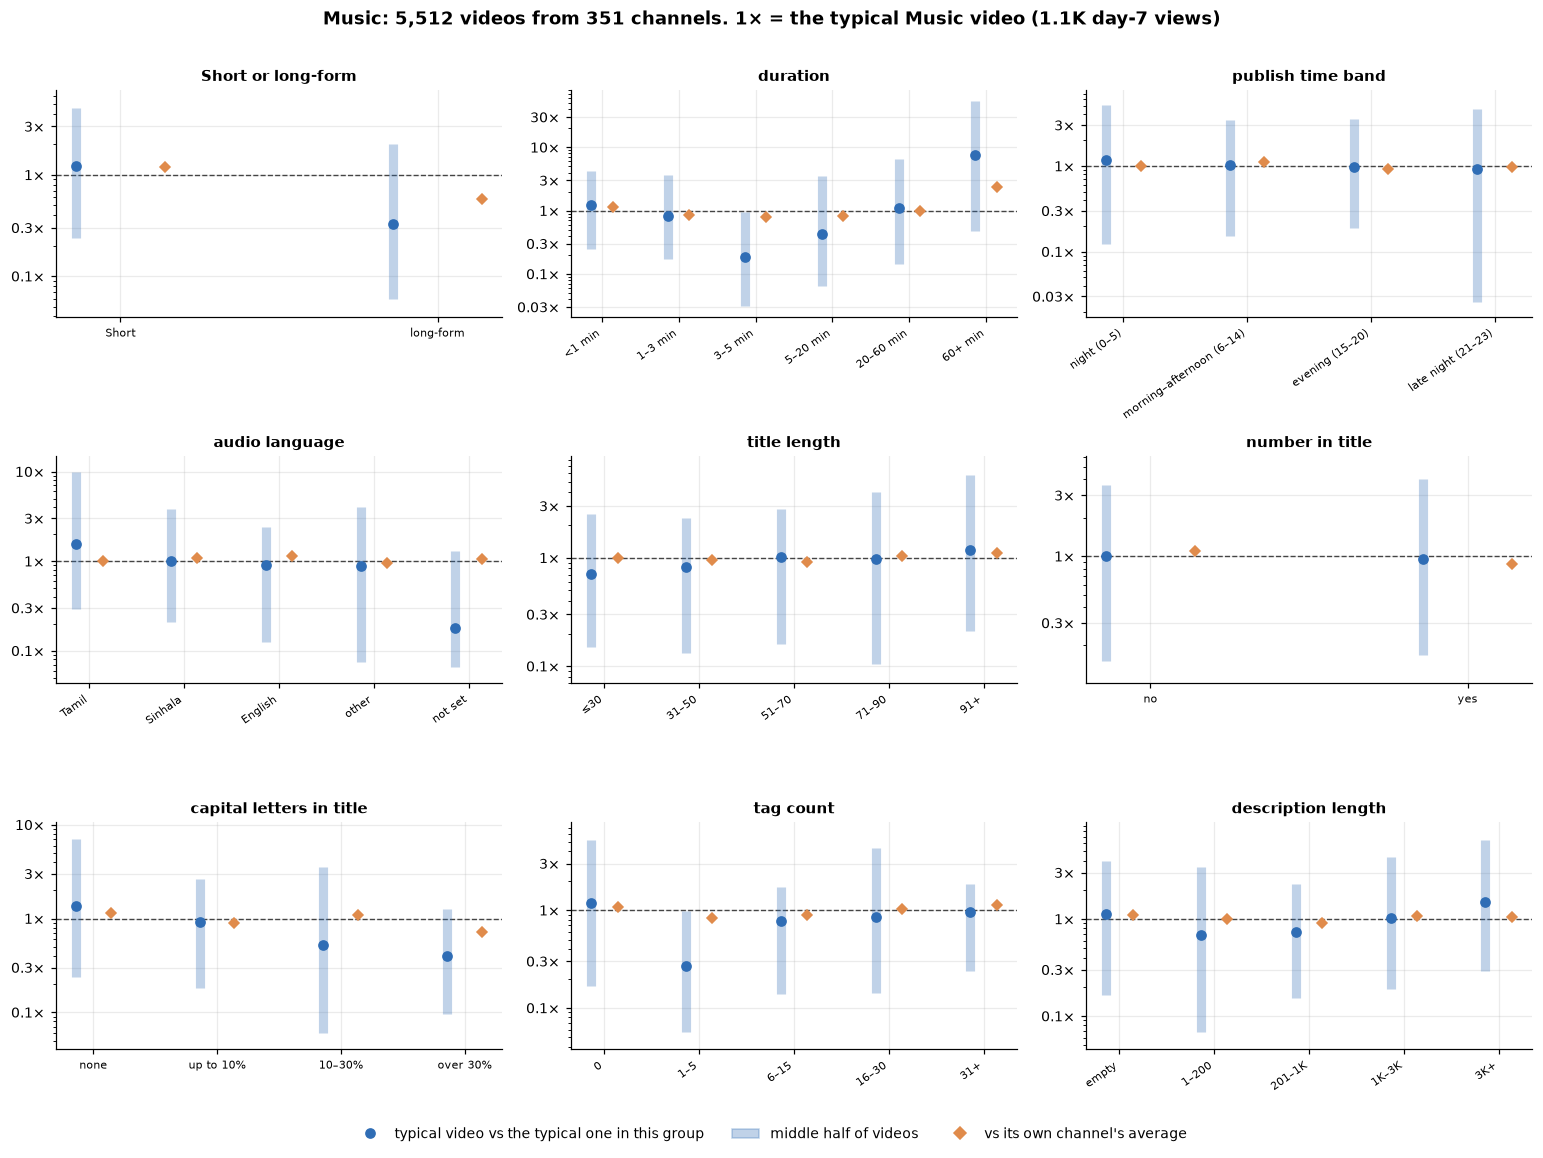

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (1.22×),long-form (0.33×),Short (1.20×),long-form (0.57×),2.09×
duration,<1 min (1.22×),3–5 min (0.19×),<1 min (1.16×),3–5 min (0.81×),1.44×
publish time band,night (0–5) (1.19×),late night (21–23) (0.93×),morning–afternoon (6–14) (1.12×),evening (15–20) (0.94×),1.20×
audio language,Tamil (1.56×),other (0.89×),English (1.14×),other (0.96×),1.19×
title length,91+ (1.19×),≤30 (0.71×),91+ (1.11×),51–70 (0.91×),1.22×
number in title,no (1.01×),yes (0.94×),no (1.10×),yes (0.86×),1.27×
capital letters in title,none (1.35×),over 30% (0.40×),none (1.15×),over 30% (0.71×),1.61×
tag count,0 (1.18×),1–5 (0.27×),31+ (1.13×),1–5 (0.84×),1.35×
description length,3K+ (1.50×),1–200 (0.68×),empty (1.11×),201–1K (0.91×),1.22×


In [46]:
if "Music" in CATS:
    L.category_page(d, f, "Music")

**Music.** **Shorts** beat long-form (1.2× against 0.6×). Titles **without
capitals** do best and titles over 30% capitals worst (0.7×). A number in the
title slightly hurts. Time of day makes little difference.

### People & Blogs

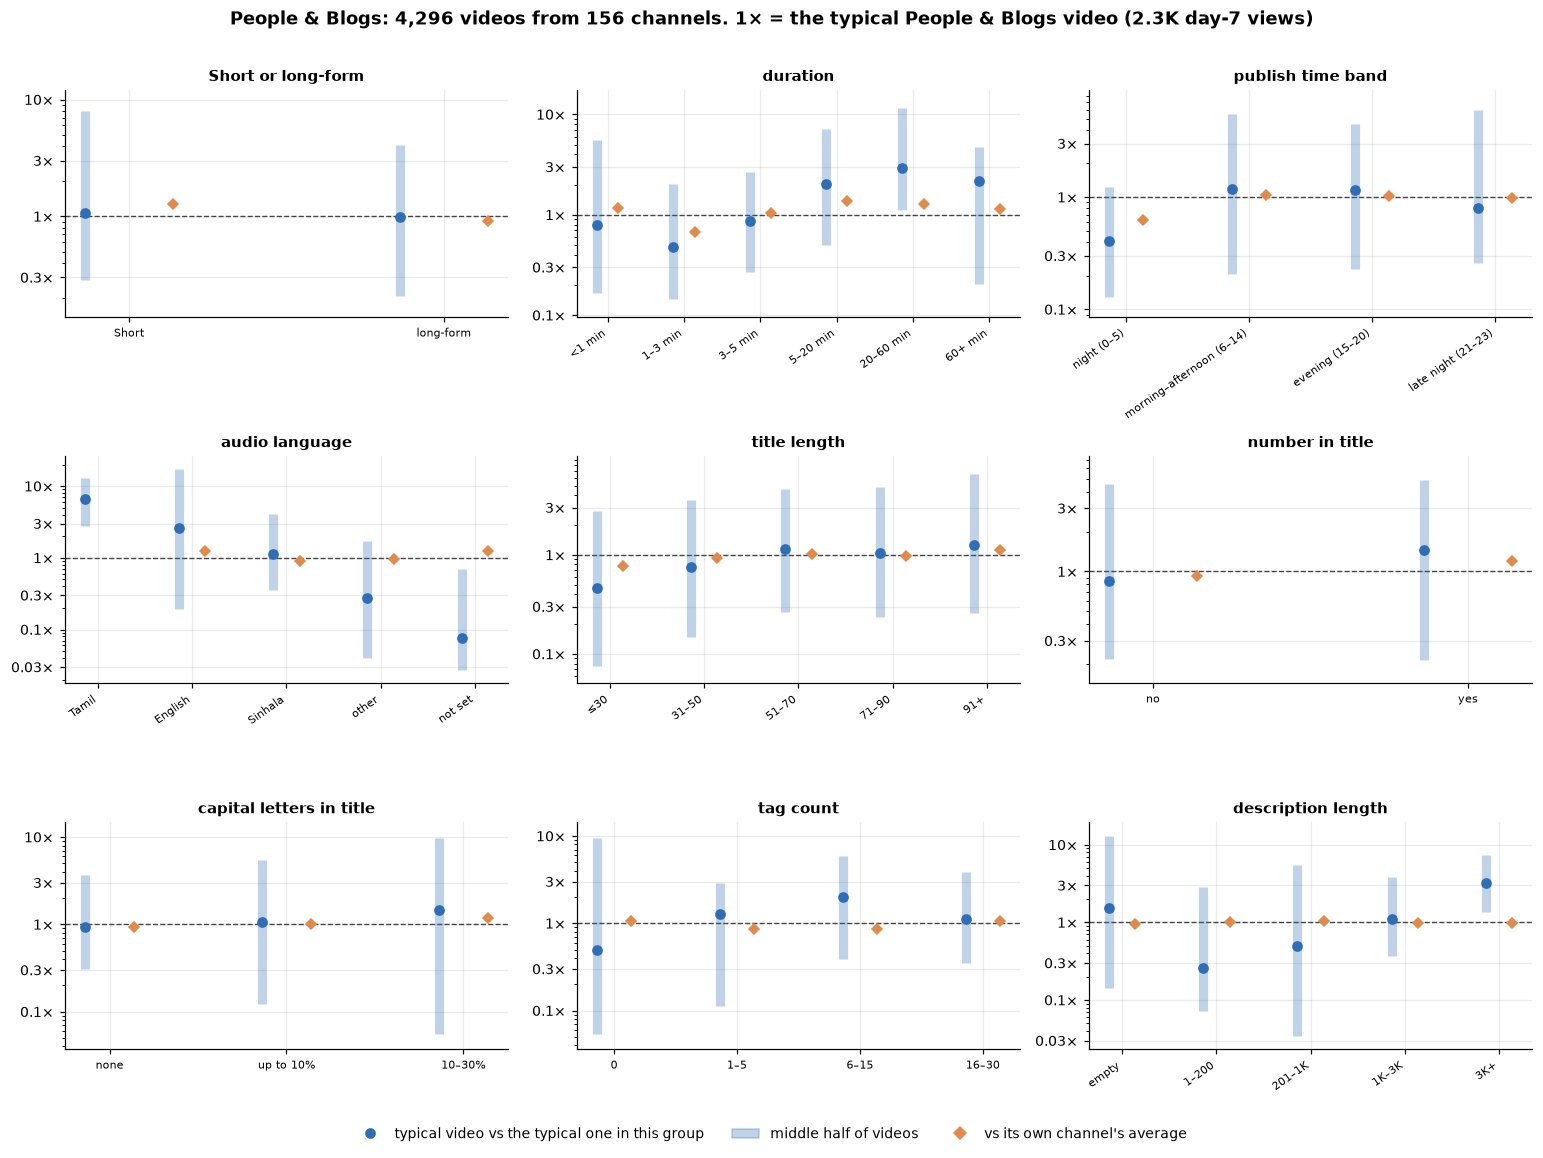

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (1.06×),long-form (0.98×),Short (1.27×),long-form (0.91×),1.39×
duration,20–60 min (2.9×),1–3 min (0.47×),5–20 min (1.36×),1–3 min (0.67×),2.02×
publish time band,morning–afternoon (6–14) (1.19×),night (0–5) (0.41×),morning–afternoon (6–14) (1.05×),night (0–5) (0.63×),1.67×
audio language,Tamil (6.7×),other (0.27×),English (1.23×),other (0.96×),1.28×
title length,91+ (1.26×),≤30 (0.47×),91+ (1.12×),≤30 (0.77×),1.46×
number in title,yes (1.45×),no (0.85×),yes (1.21×),no (0.92×),1.32×
capital letters in title,10–30% (1.47×),none (0.93×),10–30% (1.17×),none (0.92×),1.27×
tag count,6–15 (1.98×),0 (0.50×),0 (1.06×),1–5 (0.87×),1.23×
description length,empty (1.54×),1–200 (0.26×),201–1K (1.03×),empty (0.95×),1.08×


In [47]:
if "People & Blogs" in CATS:
    L.category_page(d, f, "People & Blogs")

**People & Blogs.** Shorts do a little better (1.3× against 0.9×) and 5 to 20
minute videos best among long-form. **Avoid posting at night** (0:00 to 5:00,
0.6×). Longer titles and a number in the title help slightly.

### Gaming

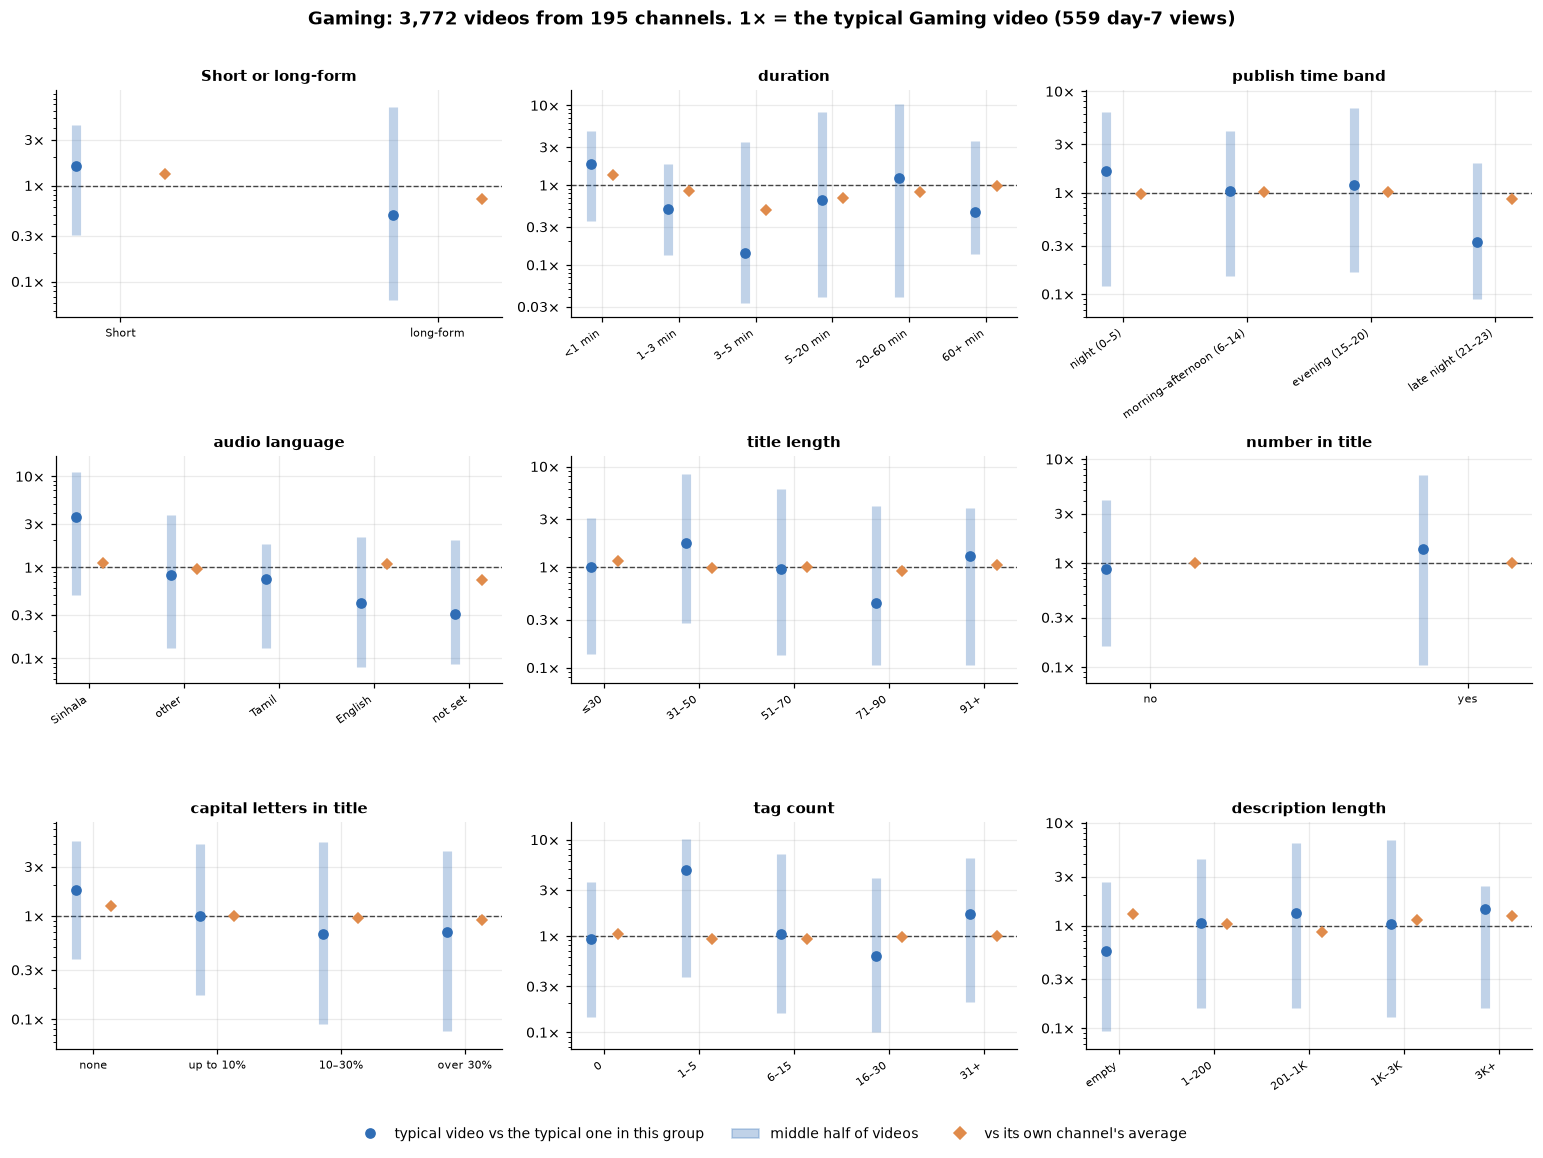

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (1.62×),long-form (0.49×),Short (1.31×),long-form (0.73×),1.79×
duration,<1 min (1.82×),3–5 min (0.14×),<1 min (1.33×),5–20 min (0.70×),1.90×
publish time band,night (0–5) (1.62×),late night (21–23) (0.33×),evening (15–20) (1.02×),late night (21–23) (0.87×),1.17×
audio language,Sinhala (3.6×),English (0.41×),Sinhala (1.11×),other (0.96×),1.15×
title length,31–50 (1.74×),71–90 (0.44×),≤30 (1.15×),71–90 (0.91×),1.26×
number in title,yes (1.38×),no (0.89×),no (1.01×),yes (1.00×),1.01×
capital letters in title,none (1.79×),10–30% (0.68×),none (1.25×),over 30% (0.92×),1.35×
tag count,1–5 (4.8×),16–30 (0.61×),0 (1.05×),1–5 (0.93×),1.13×
description length,3K+ (1.45×),empty (0.57×),empty (1.30×),201–1K (0.86×),1.50×


In [48]:
if "Gaming" in CATS:
    L.category_page(d, f, "Gaming")

**Gaming.** **Shorts** beat long-form (1.3× against 0.7×), and 5 to 20 minute
videos do worst. Titles without capitals and an empty description do slightly
better. Time of day and tags make little difference.

### Howto & Style

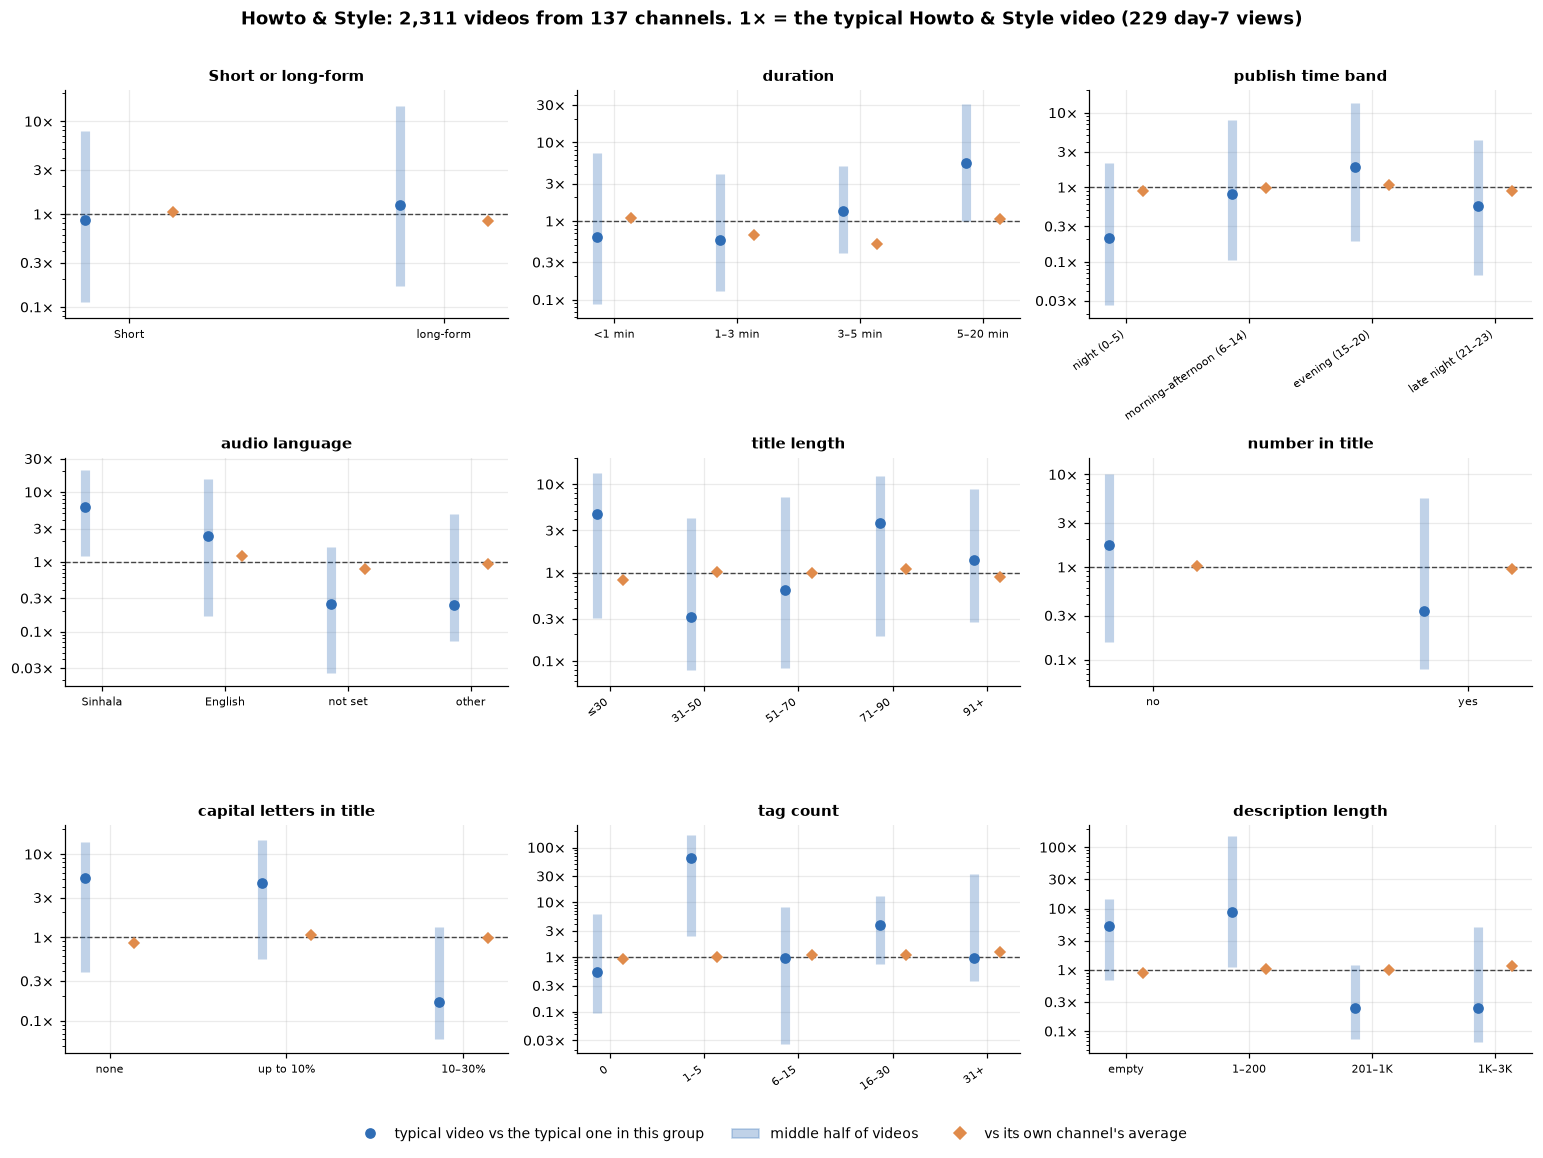

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,long-form (1.26×),Short (0.87×),Short (1.05×),long-form (0.85×),1.24×
duration,5–20 min (5.5×),1–3 min (0.57×),<1 min (1.10×),1–3 min (0.67×),1.64×
publish time band,evening (15–20) (1.85×),late night (21–23) (0.57×),evening (15–20) (1.07×),late night (21–23) (0.90×),1.19×
audio language,Sinhala (6.1×),other (0.24×),English (1.19×),other (0.95×),1.26×
title length,≤30 (4.6×),31–50 (0.32×),71–90 (1.11×),≤30 (0.83×),1.34×
number in title,no (1.75×),yes (0.33×),no (1.02×),yes (0.96×),1.07×
capital letters in title,none (5.2×),10–30% (0.17×),up to 10% (1.08×),none (0.87×),1.24×
tag count,1–5 (64×),0 (0.54×),16–30 (1.10×),0 (0.92×),1.21×
description length,1–200 (8.7×),1K–3K (0.24×),1K–3K (1.16×),empty (0.89×),1.31×


In [49]:
if "Howto & Style" in CATS:
    L.category_page(d, f, "Howto & Style")

**Howto & Style.** Within a channel, most choices make little difference.
Shorts do slightly better (1.05× against 0.85×) and 1 to 3 minute videos worst.
The huge raw numbers on this page (for example 64× for 1 to 5 tags) come from
one or two very large channels and should be ignored.

### Autos & Vehicles

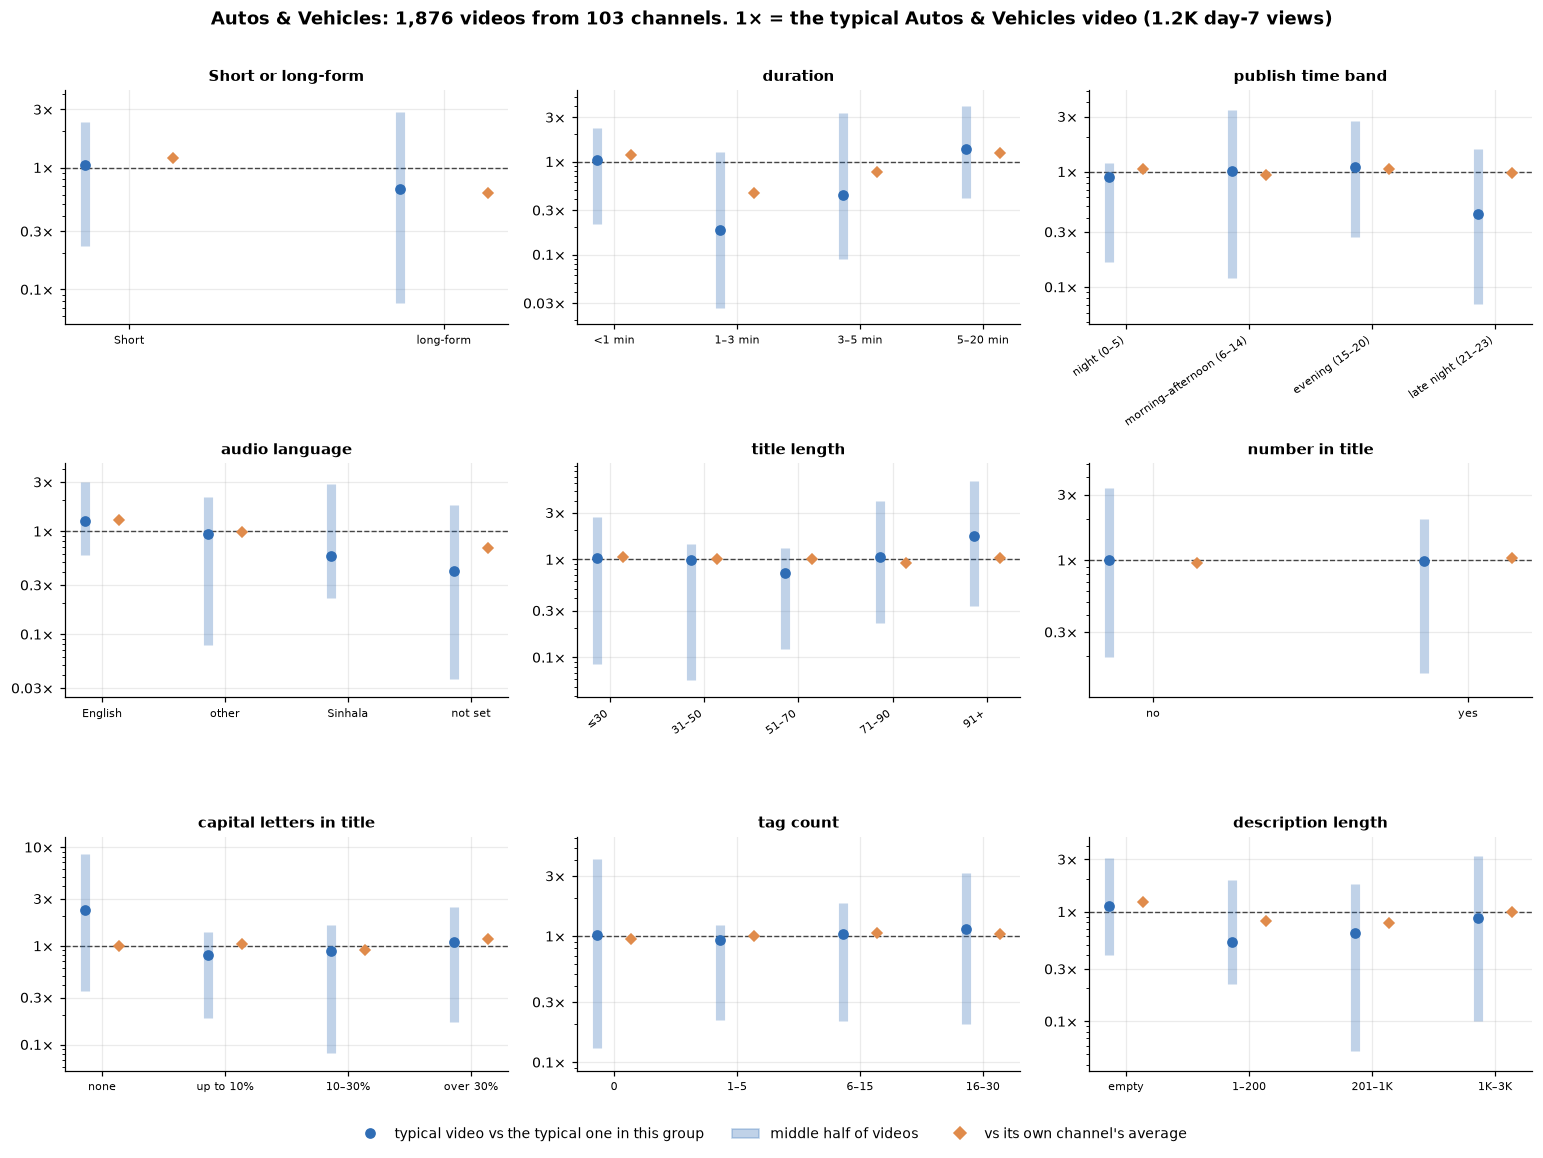

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (1.04×),long-form (0.67×),Short (1.21×),long-form (0.62×),1.95×
duration,5–20 min (1.37×),1–3 min (0.18×),5–20 min (1.24×),1–3 min (0.46×),2.67×
publish time band,evening (15–20) (1.09×),late night (21–23) (0.43×),night (0–5) (1.06×),morning–afternoon (6–14) (0.94×),1.13×
audio language,English (1.26×),Sinhala (0.57×),English (1.28×),other (0.98×),1.30×
title length,91+ (1.73×),51–70 (0.74×),≤30 (1.07×),71–90 (0.92×),1.17×
number in title,no (1.01×),yes (0.99×),yes (1.04×),no (0.95×),1.10×
capital letters in title,none (2.3×),up to 10% (0.80×),up to 10% (1.05×),10–30% (0.92×),1.15×
tag count,16–30 (1.15×),1–5 (0.94×),6–15 (1.06×),0 (0.95×),1.11×
description length,empty (1.13×),1–200 (0.53×),empty (1.24×),201–1K (0.79×),1.56×


In [50]:
if "Autos & Vehicles" in CATS:
    L.category_page(d, f, "Autos & Vehicles")

**Autos & Vehicles.** **Shorts** beat long-form (1.2× against 0.6×); among
long-form, 5 to 20 minutes is best and 1 to 3 minutes worst (0.5×). English
audio does better (1.3×). Time of day, title and tags make little difference.

### Sports

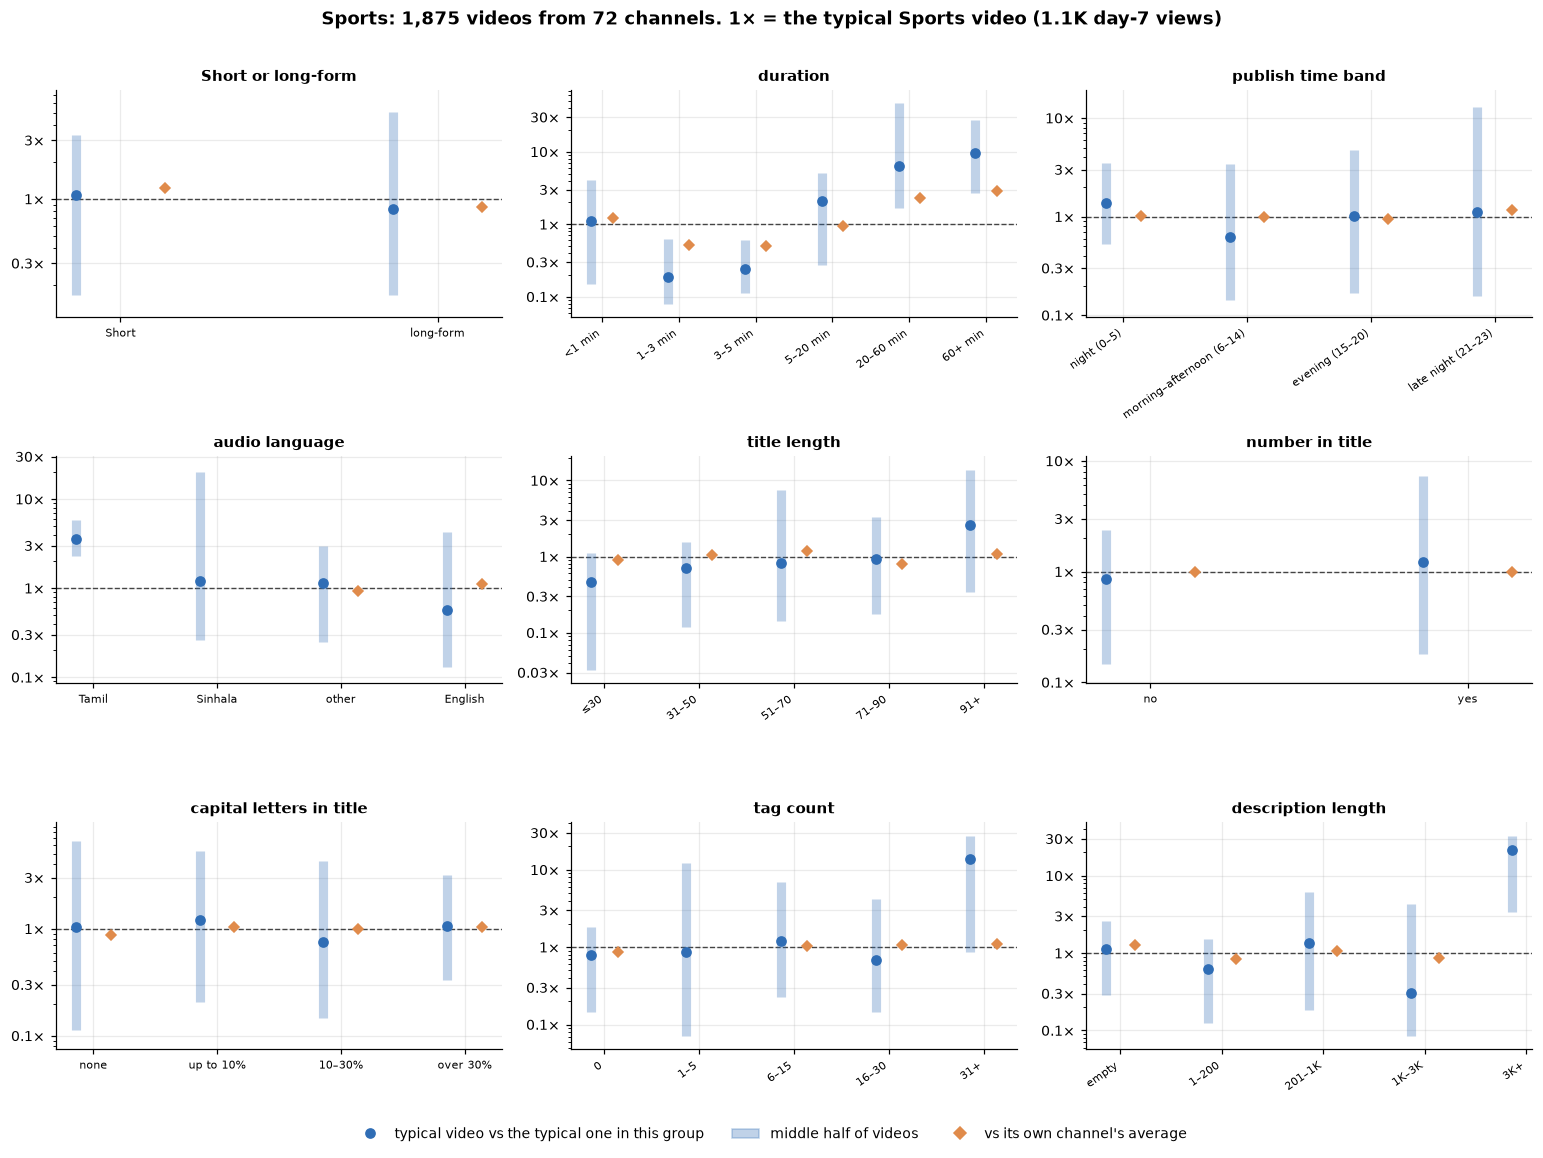

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (1.07×),long-form (0.83×),Short (1.24×),long-form (0.86×),1.43×
duration,60+ min (9.6×),1–3 min (0.19×),60+ min (2.9×),3–5 min (0.50×),5.86×
publish time band,night (0–5) (1.37×),morning–afternoon (6–14) (0.62×),late night (21–23) (1.16×),evening (15–20) (0.94×),1.23×
audio language,Tamil (3.5×),English (0.57×),English (1.13×),other (0.93×),1.21×
title length,91+ (2.6×),31–50 (0.71×),51–70 (1.17×),71–90 (0.79×),1.48×
number in title,yes (1.21×),no (0.85×),yes (0.99×),no (0.99×),1.00×
capital letters in title,up to 10% (1.21×),10–30% (0.76×),over 30% (1.04×),none (0.88×),1.19×
tag count,31+ (14×),16–30 (0.69×),31+ (1.10×),0 (0.87×),1.26×
description length,201–1K (1.36×),1K–3K (0.31×),empty (1.29×),1–200 (0.83×),1.54×


In [51]:
if "Sports" in CATS:
    L.category_page(d, f, "Sports")

**Sports.** Long streams (**60+ minutes**, 2.9×, usually full matches) and
**Shorts** (1.2× against 0.9×) both do well; 3 to 5 minute videos worst.
Late-night posting helps a little, and so do weekends (section 10 grids).

### Comedy

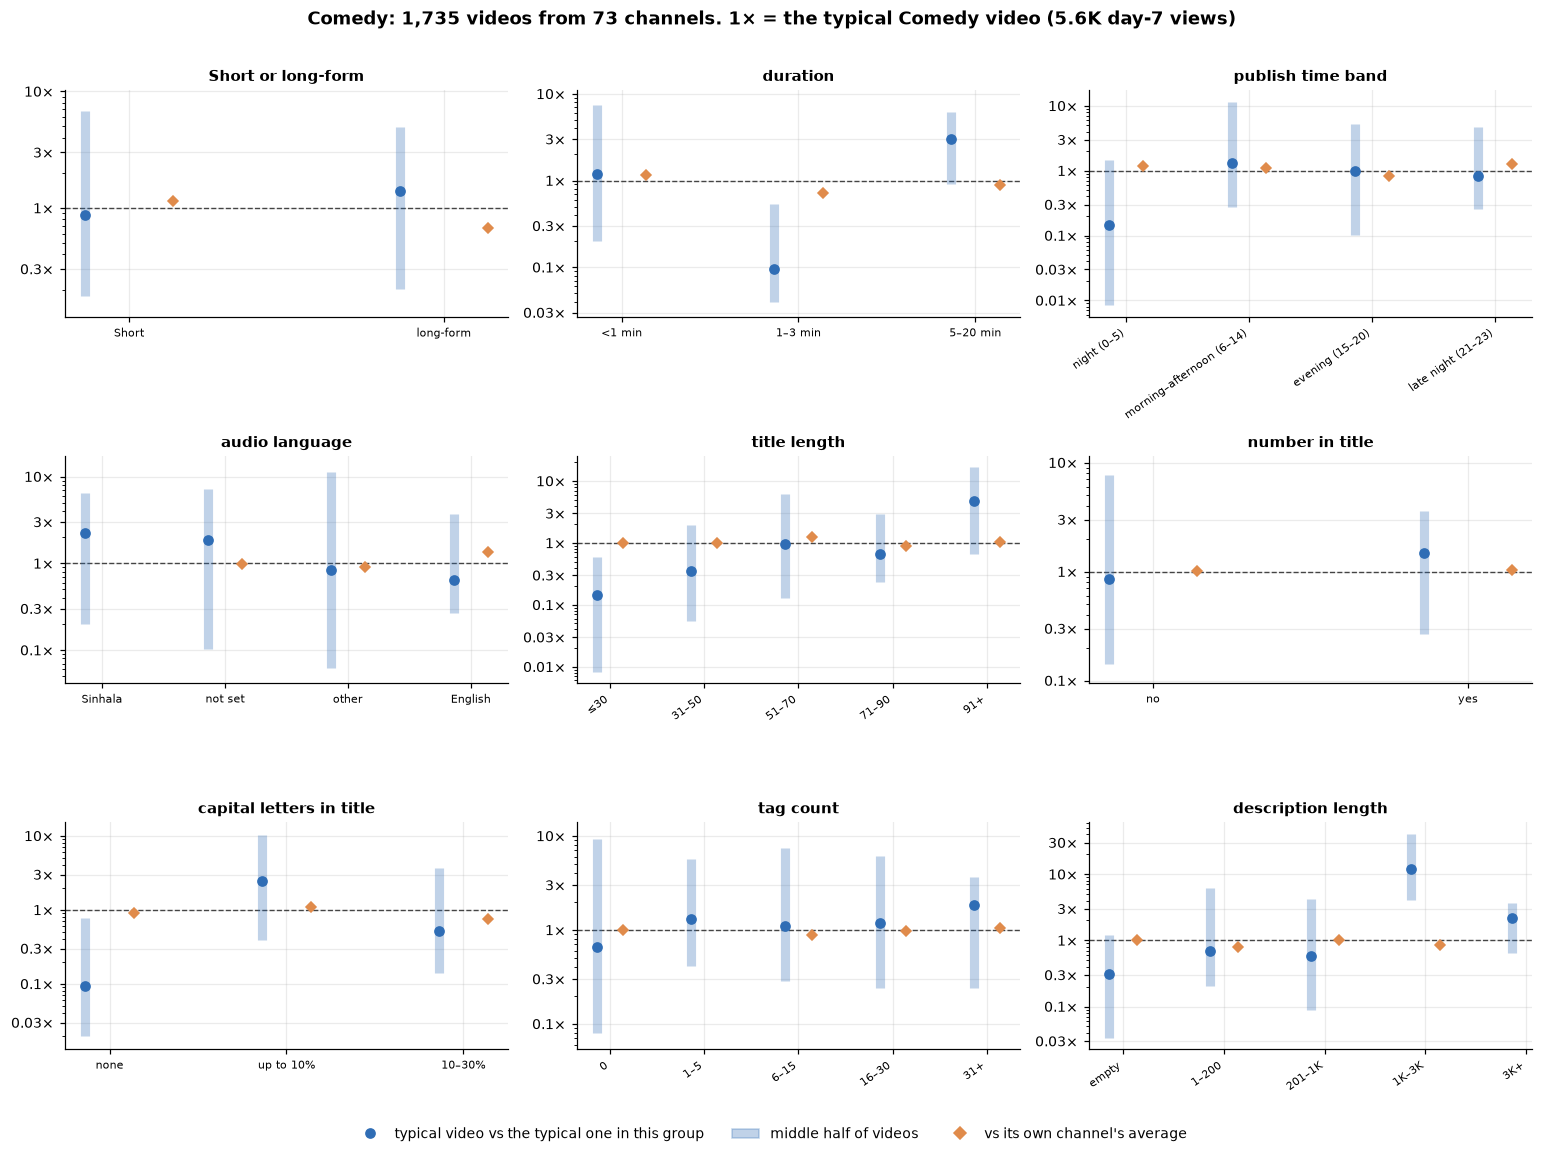

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,long-form (1.41×),Short (0.88×),Short (1.15×),long-form (0.68×),1.70×
duration,5–20 min (3.0×),1–3 min (0.10×),<1 min (1.15×),1–3 min (0.72×),1.59×
publish time band,morning–afternoon (6–14) (1.33×),late night (21–23) (0.84×),late night (21–23) (1.28×),evening (15–20) (0.84×),1.52×
audio language,Sinhala (2.2×),English (0.65×),English (1.34×),other (0.90×),1.49×
title length,91+ (4.7×),≤30 (0.14×),51–70 (1.24×),71–90 (0.88×),1.41×
number in title,yes (1.49×),no (0.86×),yes (1.04×),no (1.01×),1.02×
capital letters in title,up to 10% (2.5×),none (0.09×),up to 10% (1.10×),10–30% (0.76×),1.46×
tag count,31+ (1.85×),0 (0.66×),31+ (1.04×),16–30 (0.96×),1.08×
description length,1K–3K (12×),empty (0.31×),201–1K (1.02×),1K–3K (0.86×),1.19×


In [52]:
if "Comedy" in CATS:
    L.category_page(d, f, "Comedy")

**Comedy.** **Shorts** beat long-form within a channel (1.15× against 0.7×),
though the raw view says the opposite because the long-form comes from bigger
channels. **Late-night posting** is best (1.3×), evening worst. English audio
helps (1.3×), and titles with 10 to 30% capitals do worst.

### Pets & Animals

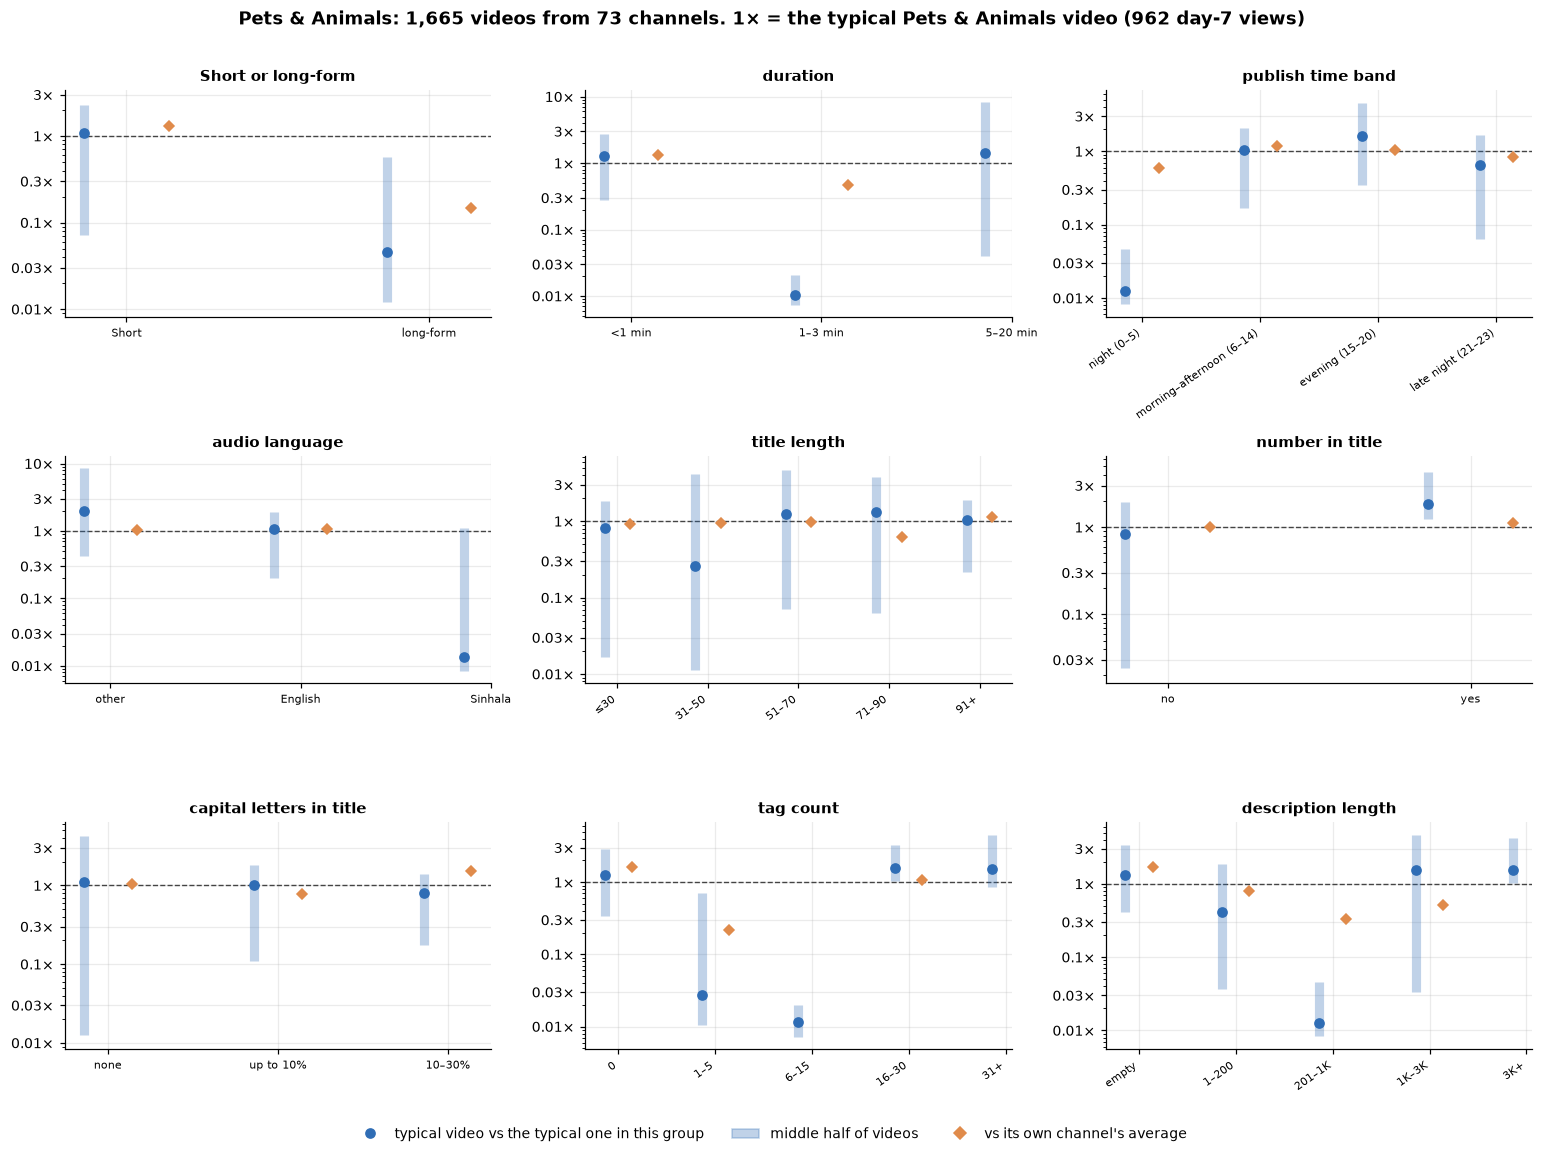

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (1.08×),long-form (0.05×),Short (1.31×),long-form (0.15×),8.84×
duration,<1 min (1.30×),1–3 min (0.01×),<1 min (1.32×),1–3 min (0.47×),2.82×
publish time band,evening (15–20) (1.61×),night (0–5) (0.01×),morning–afternoon (6–14) (1.19×),night (0–5) (0.59×),2.01×
audio language,other (1.96×),Sinhala (0.01×),English (1.06×),other (1.03×),1.03×
title length,71–90 (1.31×),31–50 (0.26×),91+ (1.14×),≤30 (0.92×),1.24×
number in title,yes (1.86×),no (0.83×),yes (1.13×),no (0.99×),1.13×
capital letters in title,none (1.12×),10–30% (0.79×),10–30% (1.53×),up to 10% (0.77×),1.97×
tag count,16–30 (1.58×),6–15 (0.01×),0 (1.61×),1–5 (0.22×),7.45×
description length,3K+ (1.56×),201–1K (0.01×),empty (1.67×),201–1K (0.34×),4.99×


In [53]:
if "Pets & Animals" in CATS:
    L.category_page(d, f, "Pets & Animals")

**Pets & Animals.** Almost all Shorts. The few long-form videos do very badly
(0.15× the channel's average). Posting in the day is best, at night worst.
Several gaps here are large because there are few long-form videos; treat the
exact numbers with care.

### Film & Animation

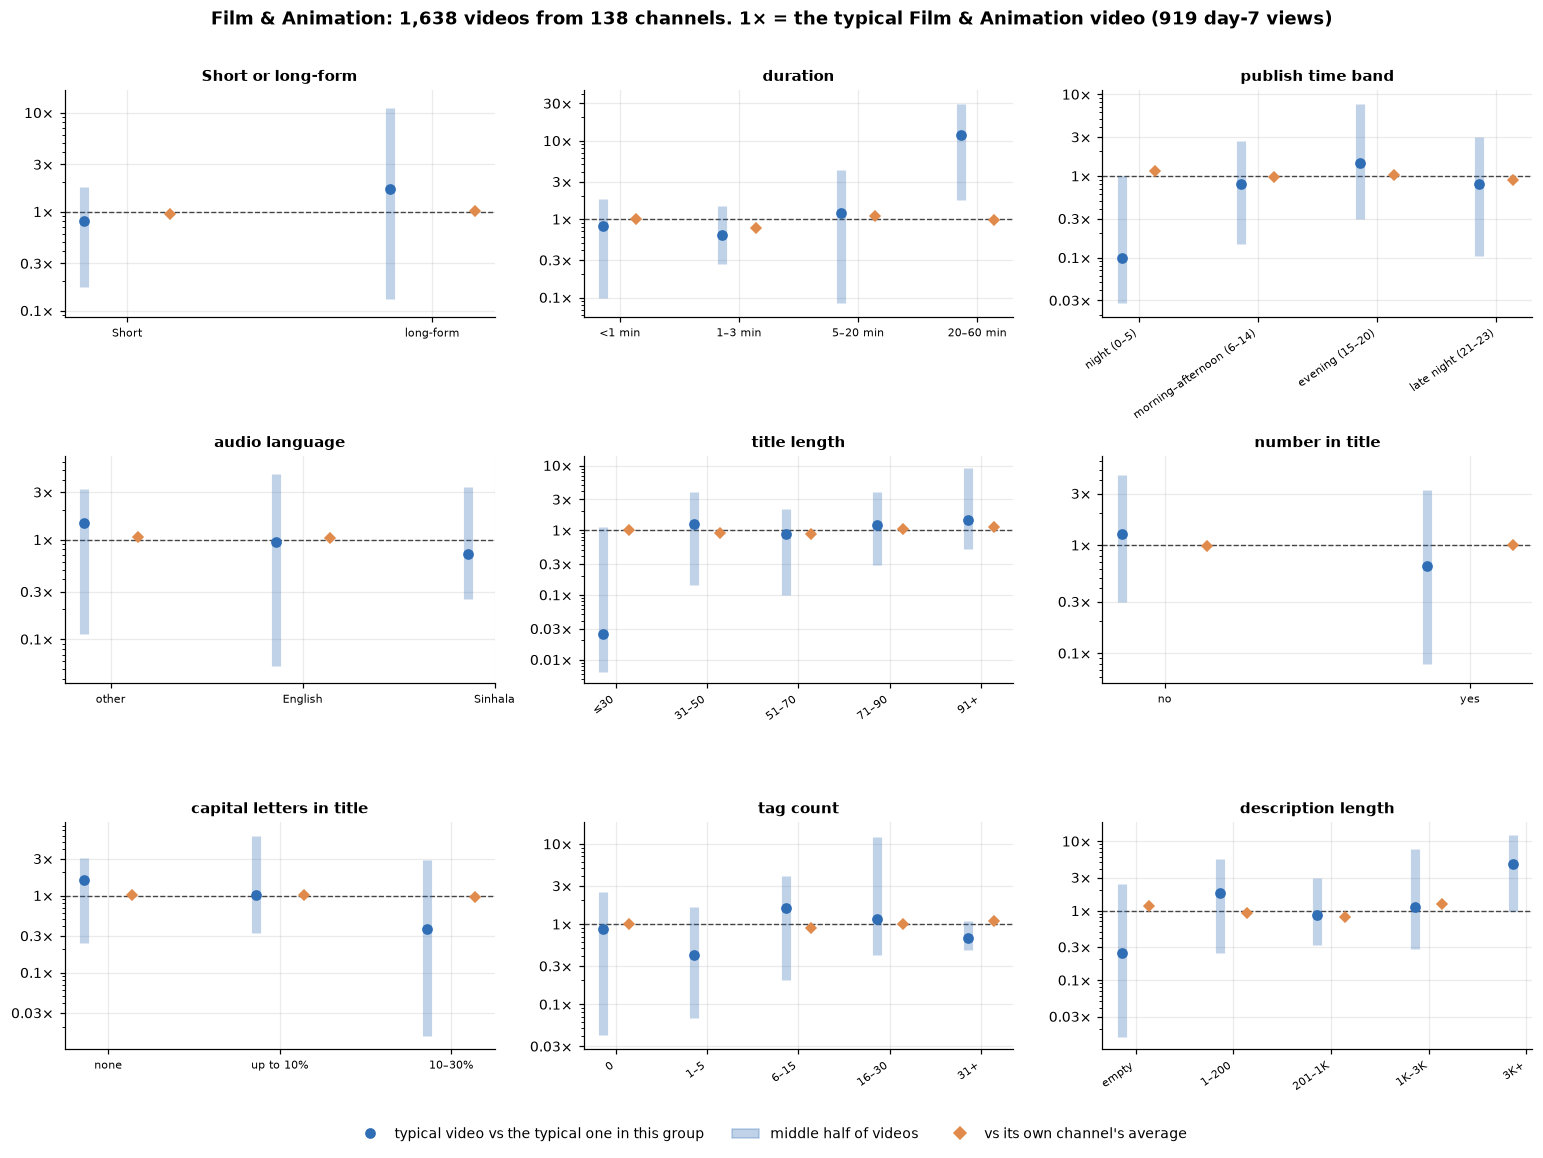

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,long-form (1.70×),Short (0.81×),long-form (1.02×),Short (0.96×),1.07×
duration,20–60 min (12×),1–3 min (0.63×),5–20 min (1.10×),1–3 min (0.77×),1.42×
publish time band,evening (15–20) (1.43×),night (0–5) (0.10×),evening (15–20) (1.03×),late night (21–23) (0.89×),1.15×
audio language,other (1.47×),Sinhala (0.71×),too few channels,,
title length,91+ (1.45×),≤30 (0.03×),91+ (1.13×),51–70 (0.89×),1.27×
number in title,no (1.26×),yes (0.64×),yes (1.00×),no (0.98×),1.02×
capital letters in title,none (1.58×),10–30% (0.37×),up to 10% (1.00×),10–30% (0.97×),1.03×
tag count,6–15 (1.58×),1–5 (0.41×),0 (1.02×),16–30 (1.00×),1.02×
description length,1–200 (1.79×),empty (0.25×),1K–3K (1.24×),201–1K (0.82×),1.52×


In [54]:
if "Film & Animation" in CATS:
    L.category_page(d, f, "Film & Animation")

**Film & Animation.** Within a channel, almost nothing makes a difference.
Only a longer description and 5 to 20 minute videos help slightly.

### Science & Technology

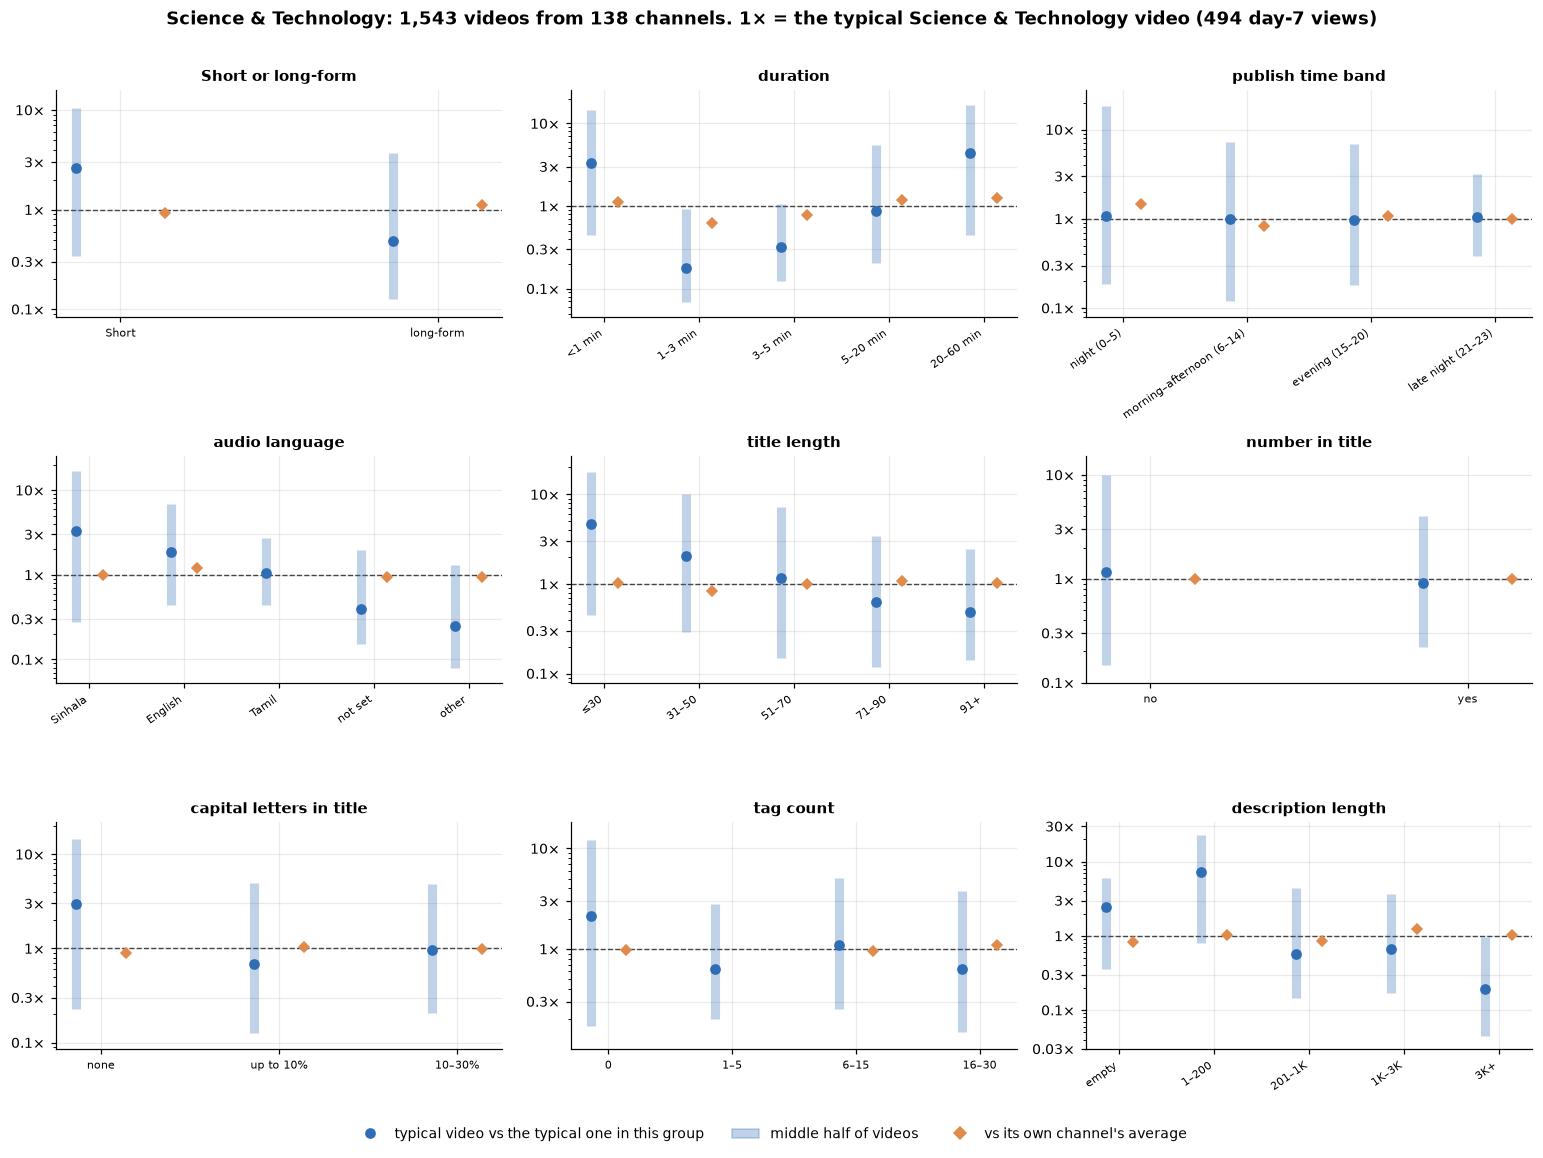

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
Short or long-form,Short (2.6×),long-form (0.48×),long-form (1.11×),Short (0.93×),1.20×
duration,<1 min (3.3×),1–3 min (0.18×),5–20 min (1.18×),1–3 min (0.62×),1.89×
publish time band,late night (21–23) (1.04×),evening (15–20) (0.97×),evening (15–20) (1.07×),morning–afternoon (6–14) (0.83×),1.29×
audio language,Sinhala (3.3×),other (0.25×),too few channels,,
title length,≤30 (4.6×),91+ (0.49×),71–90 (1.09×),31–50 (0.83×),1.31×
number in title,no (1.16×),yes (0.90×),no (0.99×),yes (0.99×),1.00×
capital letters in title,none (2.9×),up to 10% (0.68×),up to 10% (1.04×),none (0.89×),1.17×
tag count,0 (2.1×),16–30 (0.63×),16–30 (1.10×),6–15 (0.95×),1.16×
description length,1–200 (7.2×),3K+ (0.19×),1K–3K (1.25×),empty (0.82×),1.52×


In [55]:
if "Science & Technology" in CATS:
    L.category_page(d, f, "Science & Technology")

**Science & Technology.** Within a channel, **long-form does slightly better
than Shorts** (1.1× against 0.9×), unlike most categories. 5 to 20 minute videos
and a 1K to 3K character description help a little; the morning is the weakest
time.

## Raw ranking against the own-channel ranking

Most channels post in one category only, so the own-channel comparison uses
just the channels that post in two or more. For them it asks: is a video in
this category better or worse than the channel's usual?

In [56]:
ncat = d[lab].groupby("channel_id").category_name.nunique()
t = L.group_table(d, cat)
say(f"{int((ncat >= 2).sum()):,} of {len(ncat):,} channels post in two or more categories.")
t = t[t.videos >= 200].sort_values("raw_x", ascending=False)
t["raw rank"] = range(1, len(t) + 1)
t["own-channel rank"] = t.own_x.where(t.own_n >= 100).rank(ascending=False).astype("Int64")
display(pd.DataFrame({"videos": t.videos.map("{:,}".format), "× typical": t.raw_x.map(times),
                      "raw rank": t["raw rank"], "× own channel": t.own_x.map(times),
                      "videos in the own-channel view": t.own_n.map("{:,}".format),
                      "channels": t.own_ch,
                      "own-channel rank": t["own-channel rank"]}))

188 of 2,293 channels post in two or more categories.

,videos,× typical,raw rank,× own channel,videos in the own-channel view,channels,own-channel rank
Comedy,"1,735",4.7×,1,1.11×,174,14,3
Entertainment,"9,582",3.3×,2,0.88×,"1,935",75,13
People & Blogs,"4,296",1.93×,3,0.98×,"2,507",47,8
Autos & Vehicles,"1,876",1.03×,4,1.08×,105,14,4
Sports,"1,875",0.94×,5,0.93×,251,15,10
Music,"5,512",0.92×,6,1.15×,244,24,2
News & Politics,"23,885",0.89×,7,6.3×,157,11,1
Pets & Animals,"1,665",0.80×,8,0.87×,141,19,14
Education,"10,794",0.77×,9,1.05×,771,49,5
Film & Animation,"1,638",0.77×,10,0.93×,209,21,11


**What this shows.** Only 188 channels post in more than one category, so the
own-channel column is based on small numbers and should be read as a hint.
It still flips the picture. **News & Politics** ranks 7th raw but 1st when a
channel that usually posts something else posts news (6.3×, 11 channels).
**Entertainment** falls from 2nd to 13th. A category's raw rank says more about
its channels than about the content.

## Category by channel size (median day-7 views)

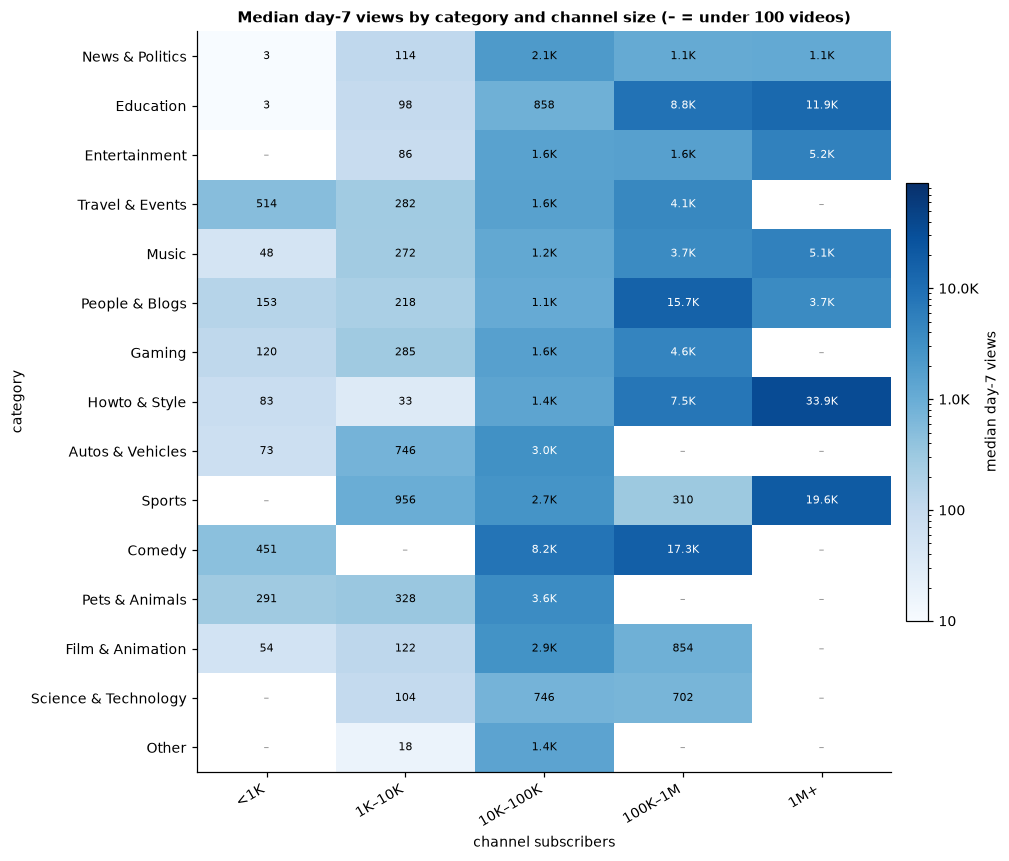

In [57]:
t = d[lab].assign(cat=cat[lab], size=f["subscribers"][lab]).dropna(subset=["size"])
vals = t.groupby(["cat", "size"], observed=True).v7.median().unstack()
cnt = t.groupby(["cat", "size"], observed=True).v7.size().unstack().fillna(0)
fig = L.grid(vals, cnt, "Median day-7 views by category and channel size (– = under 100 videos)",
             short, "Blues", LogNorm(vmin=10, vmax=max(vals.max().max(), 100)),
             "channel subscribers", "category", "median day-7 views", cbar_ticks=[10, 100, 1000, 10000])
save(fig, "category_by_size")

**What this shows.** Within the same channel size, categories are much closer
than the raw ranking suggests. For example, Education is near the bottom raw,
but at 100K+ subscribers it is one of the best (8.8K to 11.9K). Howto & Style
is the worst raw category, yet 1M+ Howto channels get the highest median in
the grid. Channel size explains most of what looks like a category effect.

## What a creator can change, category by category

Each grid compares videos with their **own channel's usual** views, so channel
size is removed. **Blue** is better than usual, **red** worse, white about the
same. Cells with fewer than 100 videos are left blank.

### Short or long-form

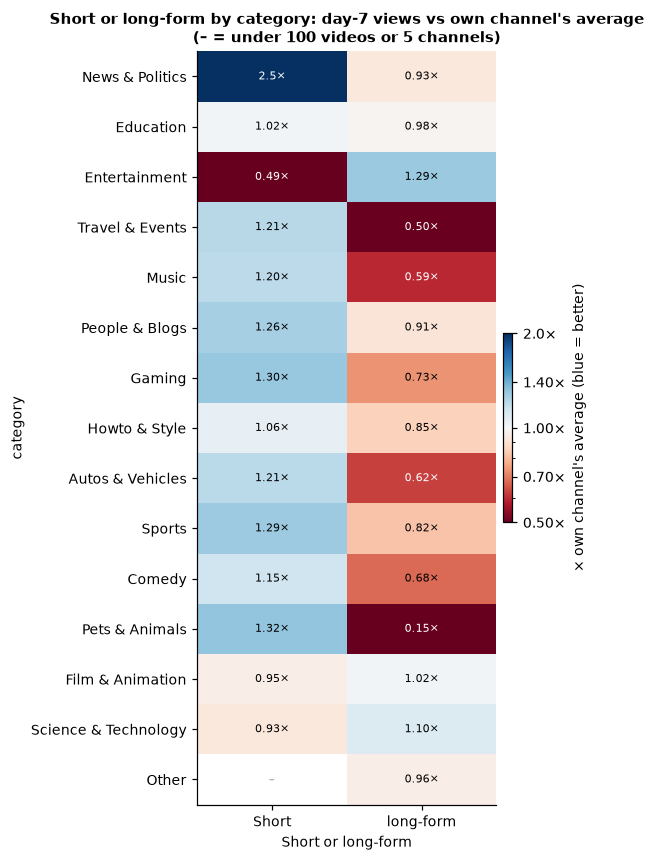

In [58]:
G_Short_or_long_form = L.own_grid(d, f, "Short or long-form", CATS)

**What this shows.** Compared with their own channel, Shorts beat long-form in
most categories. The exceptions are **Entertainment**, where long-form wins
clearly (1.29× against 0.49×), Film & Animation and Science & Technology, where
long-form is slightly ahead, and Education, where it makes no difference. News channels' occasional Shorts do very well (2.5×).

### duration

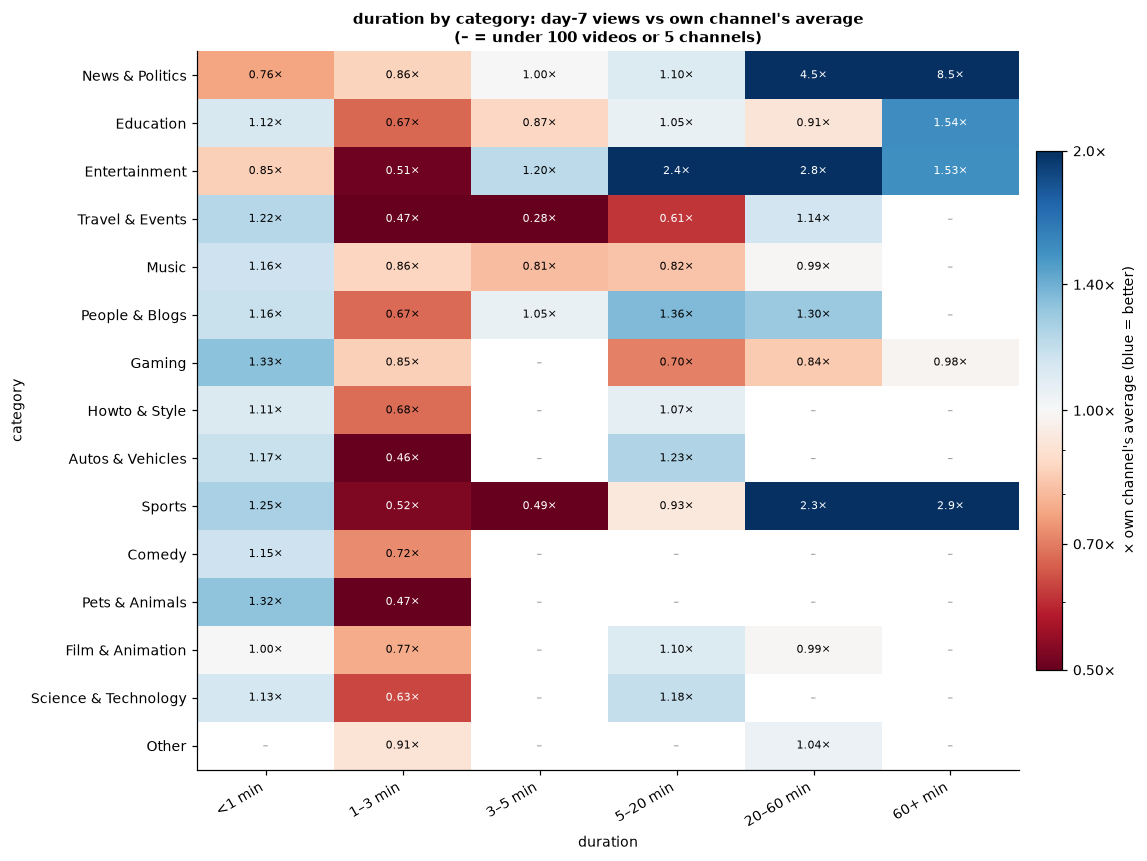

In [59]:
G_duration = L.own_grid(d, f, "duration", CATS)

**What this shows.** The 1 to 3 minute band is the weakest in almost every
category. Longer videos (20 minutes and more) do best in Entertainment, News,
Sports and Education; under a minute is best in Travel, Music, Gaming, Pets
and Comedy.

### publish time band

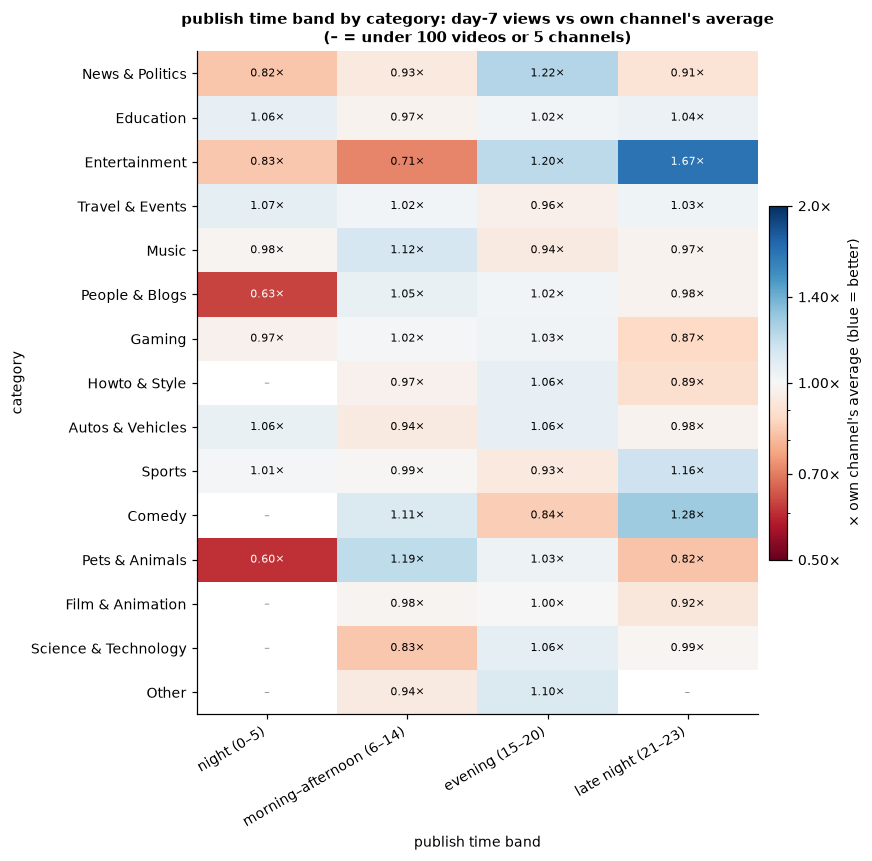

In [60]:
G_publish_time_band = L.own_grid(d, f, "publish time band", CATS)

**What this shows.** Time of day matters in only a few categories:
Entertainment and Comedy do best late at night (21:00 to 23:00), News in the
evening, People & Blogs and Pets in the day. In the rest it makes no clear
difference.

### weekend

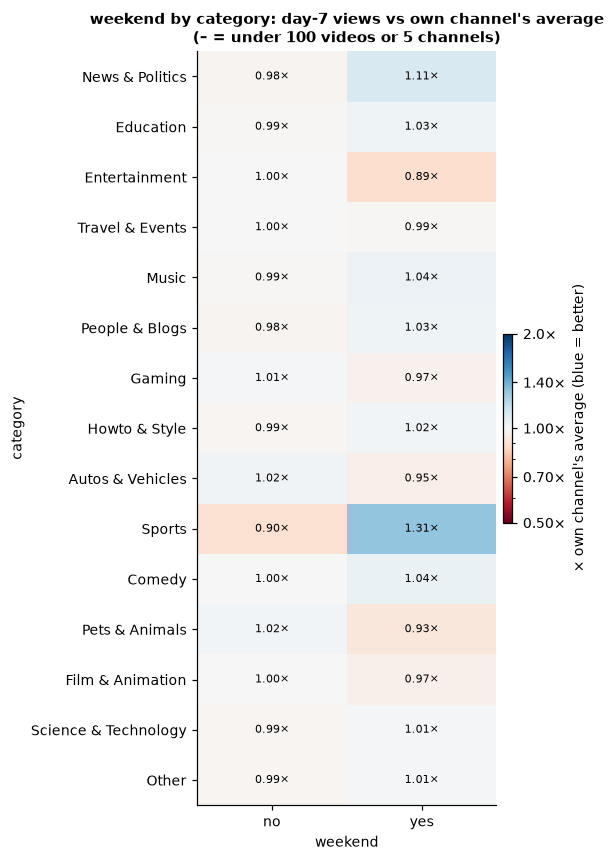

In [61]:
G_weekend = L.own_grid(d, f, "weekend", CATS)

**What this shows.** Weekend against weekday makes little difference in most
categories, which agrees with section 7. **Sports** is the exception: weekend
videos get about 1.3× the channel's average, when matches are played.

### audio language

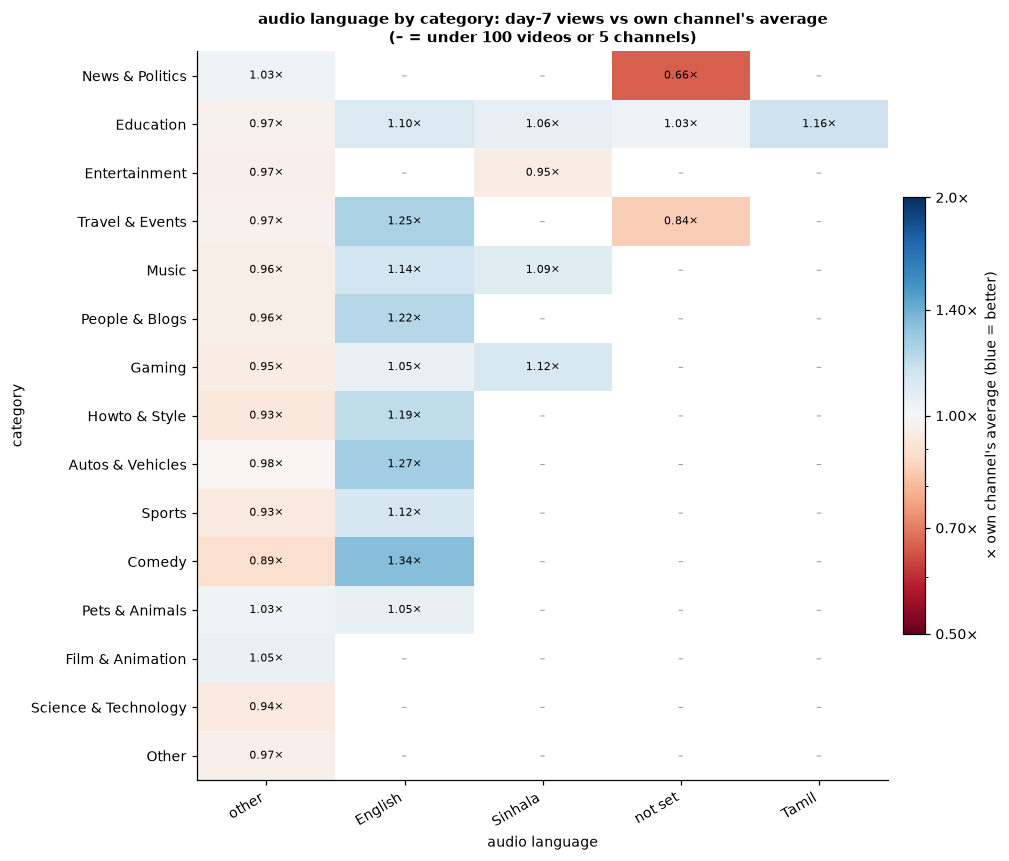

In [62]:
G_audio_language = L.own_grid(d, f, "audio language", CATS)

**What this shows.** Many cells are blank because few channels in a category
post in two languages. Where they do, English videos usually beat the
channel's average (1.1× to 1.3×), and "other" languages sit slightly below.

### number in title

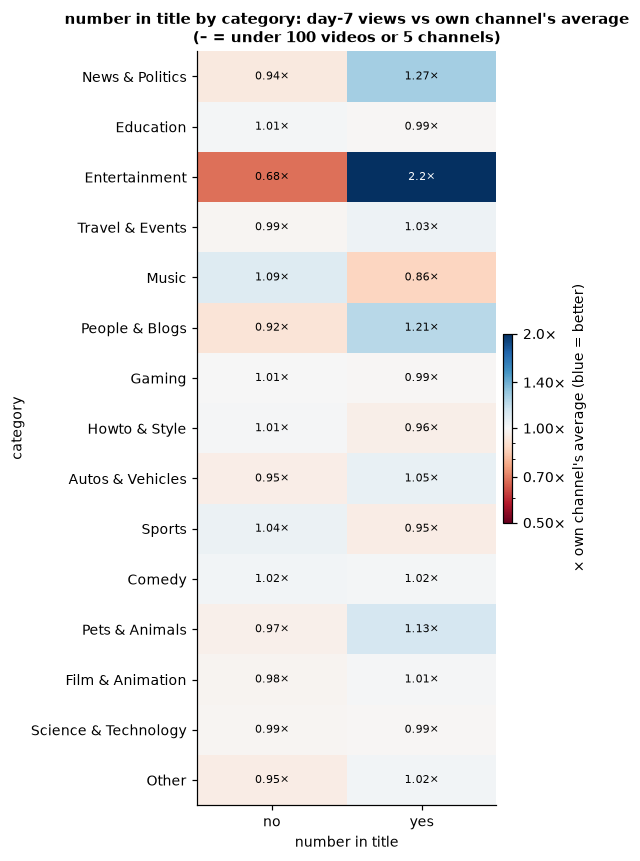

In [63]:
G_number_in_title = L.own_grid(d, f, "number in title", CATS)

**What this shows.** A number in the title helps most in **Entertainment**
(2.2×, often episode numbers), News & Politics and People & Blogs (about 1.2×).
It makes little difference elsewhere and slightly hurts in Music.

### capital letters in title

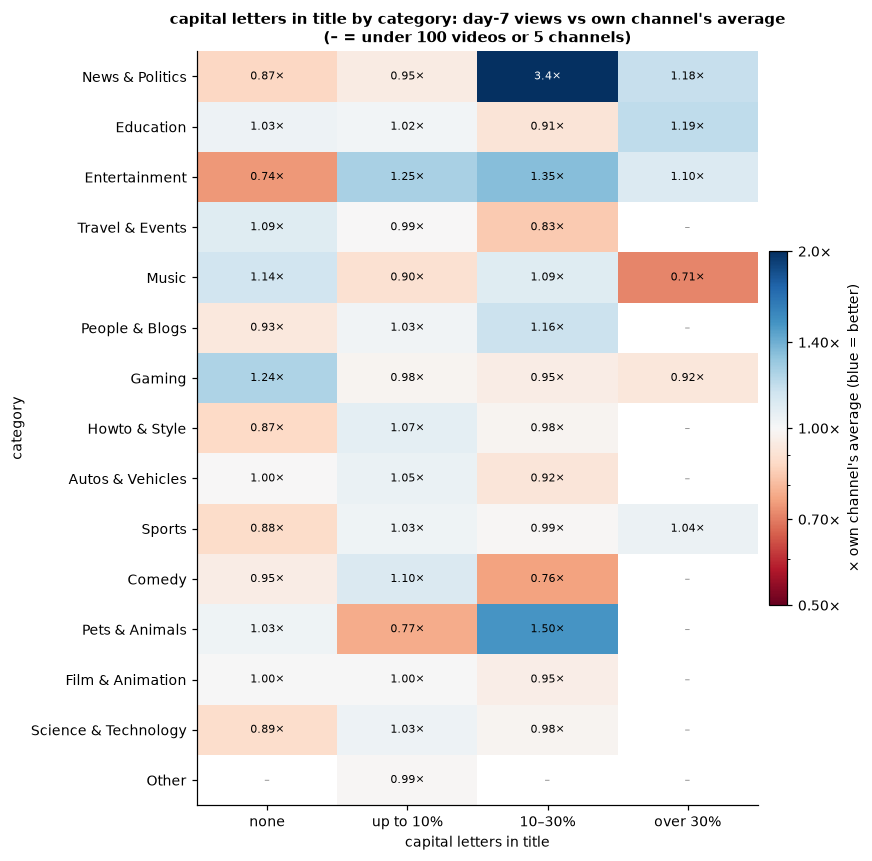

In [64]:
G_capital_letters_in_title = L.own_grid(d, f, "capital letters in title", CATS)

**What this shows.** Some capitals help in News and Entertainment; in Music,
Gaming and Travel, titles without capitals do best.

### title length

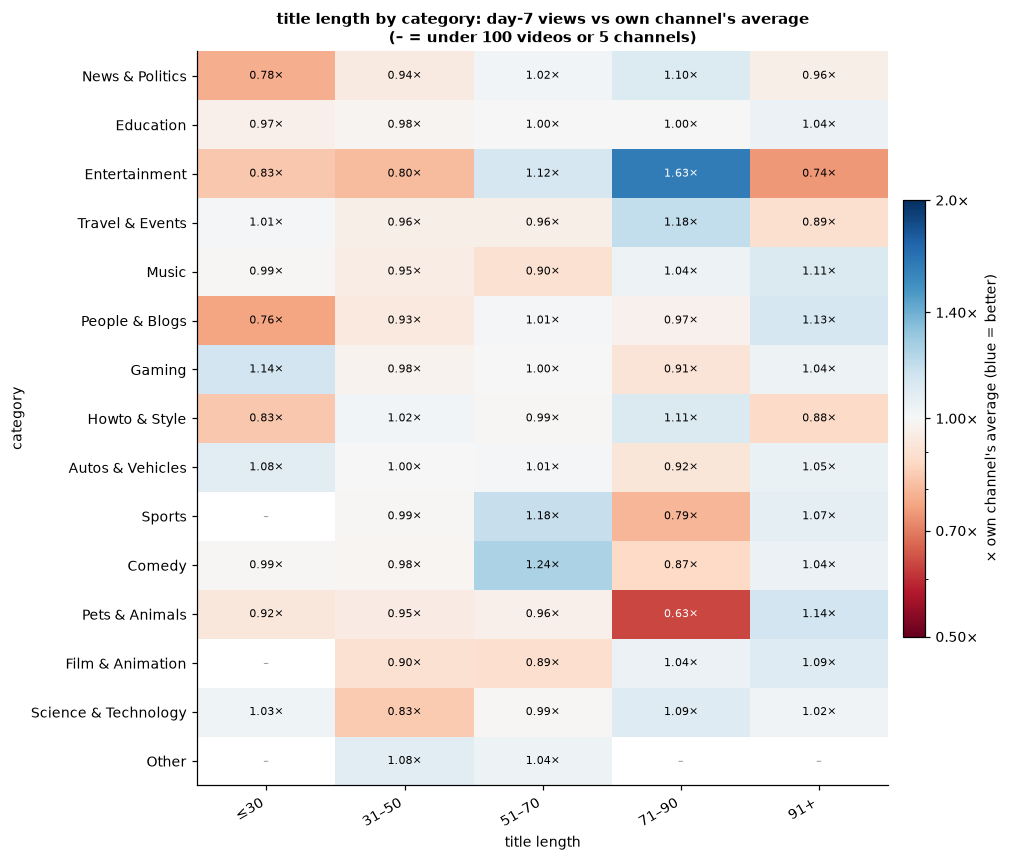

In [65]:
G_title_length = L.own_grid(d, f, "title length", CATS)

**What this shows.** Title length makes little difference in most categories.
Entertainment is the exception, where 71 to 90 characters does best (1.6×).

### tag count

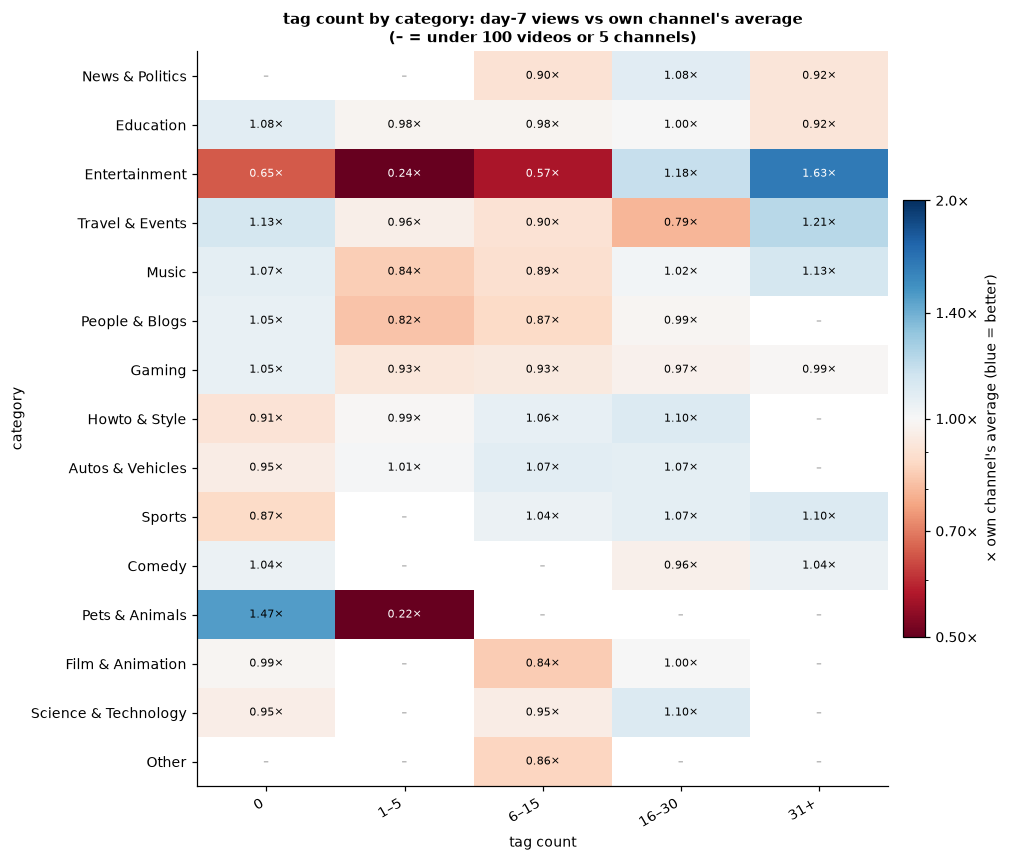

In [66]:
G_tag_count = L.own_grid(d, f, "tag count", CATS)

**What this shows.** Many tags (31+) help in Entertainment (1.6×) and a little
in Travel, Music and Sports. Very few tags (1 to 5) are the worst choice in
Entertainment and Pets (about 0.2×) and below average in most others.

## One line per category

In [67]:
lines = []
for c_ in CATS + ["Other"]:
    parts = []
    for label, (vals, cnt) in [("format", G_Short_or_long_form), ("length", G_duration),
                               ("time", G_publish_time_band), ("title capitals", G_capital_letters_in_title),
                               ("tags", G_tag_count)]:
        r = L.best_worst(vals, cnt, c_)
        if r:
            parts.append(f"{label}: {r}")
    lines.append(f"* **{c_}**: " + "; ".join(parts))
say("\n".join(lines))

* **News & Politics**: format: Short best (2.5×), long-form worst (0.93×); length: 60+ min best (8.5×), <1 min worst (0.76×); time: evening (15–20) best (1.22×), night (0–5) worst (0.82×); title capitals: 10–30% best (3.4×), none worst (0.87×); tags: no clear difference
* **Education**: format: no clear difference; length: 60+ min best (1.54×), 1–3 min worst (0.67×); time: no clear difference; title capitals: over 30% best (1.19×), 10–30% worst (0.91×); tags: no clear difference
* **Entertainment**: format: long-form best (1.29×), Short worst (0.49×); length: 20–60 min best (2.8×), 1–3 min worst (0.51×); time: late night (21–23) best (1.67×), morning–afternoon (6–14) worst (0.71×); title capitals: 10–30% best (1.35×), none worst (0.74×); tags: 31+ best (1.63×), 1–5 worst (0.24×)
* **Travel & Events**: format: Short best (1.21×), long-form worst (0.50×); length: <1 min best (1.22×), 3–5 min worst (0.28×); time: no clear difference; title capitals: none best (1.09×), 10–30% worst (0.83×); tags: 31+ best (1.21×), 16–30 worst (0.79×)
* **Music**: format: Short best (1.20×), long-form worst (0.59×); length: <1 min best (1.16×), 3–5 min worst (0.81×); time: no clear difference; title capitals: none best (1.14×), over 30% worst (0.71×); tags: 31+ best (1.13×), 1–5 worst (0.84×)
* **People & Blogs**: format: Short best (1.26×), long-form worst (0.91×); length: 5–20 min best (1.36×), 1–3 min worst (0.67×); time: morning–afternoon (6–14) best (1.05×), night (0–5) worst (0.63×); title capitals: 10–30% best (1.16×), none worst (0.93×); tags: 0 best (1.05×), 1–5 worst (0.82×)
* **Gaming**: format: Short best (1.30×), long-form worst (0.73×); length: <1 min best (1.33×), 5–20 min worst (0.70×); time: no clear difference; title capitals: none best (1.24×), over 30% worst (0.92×); tags: no clear difference
* **Howto & Style**: format: Short best (1.06×), long-form worst (0.85×); length: <1 min best (1.11×), 1–3 min worst (0.68×); time: no clear difference; title capitals: up to 10% best (1.07×), none worst (0.87×); tags: 16–30 best (1.10×), 0 worst (0.91×)
* **Autos & Vehicles**: format: Short best (1.21×), long-form worst (0.62×); length: 5–20 min best (1.23×), 1–3 min worst (0.46×); time: no clear difference; title capitals: no clear difference; tags: no clear difference
* **Sports**: format: Short best (1.29×), long-form worst (0.82×); length: 60+ min best (2.9×), 3–5 min worst (0.49×); time: late night (21–23) best (1.16×), evening (15–20) worst (0.93×); title capitals: no clear difference; tags: 31+ best (1.10×), 0 worst (0.87×)
* **Comedy**: format: Short best (1.15×), long-form worst (0.68×); length: <1 min best (1.15×), 1–3 min worst (0.72×); time: late night (21–23) best (1.28×), evening (15–20) worst (0.84×); title capitals: up to 10% best (1.10×), 10–30% worst (0.76×); tags: no clear difference
* **Pets & Animals**: format: Short best (1.32×), long-form worst (0.15×); length: <1 min best (1.32×), 1–3 min worst (0.47×); time: morning–afternoon (6–14) best (1.19×), night (0–5) worst (0.60×); title capitals: 10–30% best (1.50×), up to 10% worst (0.77×); tags: 0 best (1.47×), 1–5 worst (0.22×)
* **Film & Animation**: format: no clear difference; length: 5–20 min best (1.10×), 1–3 min worst (0.77×); time: no clear difference; title capitals: no clear difference; tags: no clear difference
* **Science & Technology**: format: no clear difference; length: 5–20 min best (1.18×), 1–3 min worst (0.63×); time: evening (15–20) best (1.06×), morning–afternoon (6–14) worst (0.83×); title capitals: no clear difference; tags: no clear difference
* **Other**: length: no clear difference; time: no clear difference

**How to use these lines.** Each is a draft guideline for creators in that
category, based on how their videos did against their own channel. "No clear
difference" means the best and worst options were within 1.2× of each other.

Treat the extreme numbers with care. In News & Politics most channels post
long-form clips, so its rare Shorts, hour-long streams and capitalised titles
come from a small set of videos, which is why they show 2.5× to 8.5×.

---
# 11. Shorts and long-form, separately

Shorts and long-form reach viewers in different ways (the Shorts feed against
search, home and suggested videos), so an input can matter for one format and
not the other. This section repeats the per-input view inside each format.
**1× is now the typical Short, or the typical long-form video.** Duration is
split more finely for Shorts, since they are all 3 minutes or less.

## Shorts

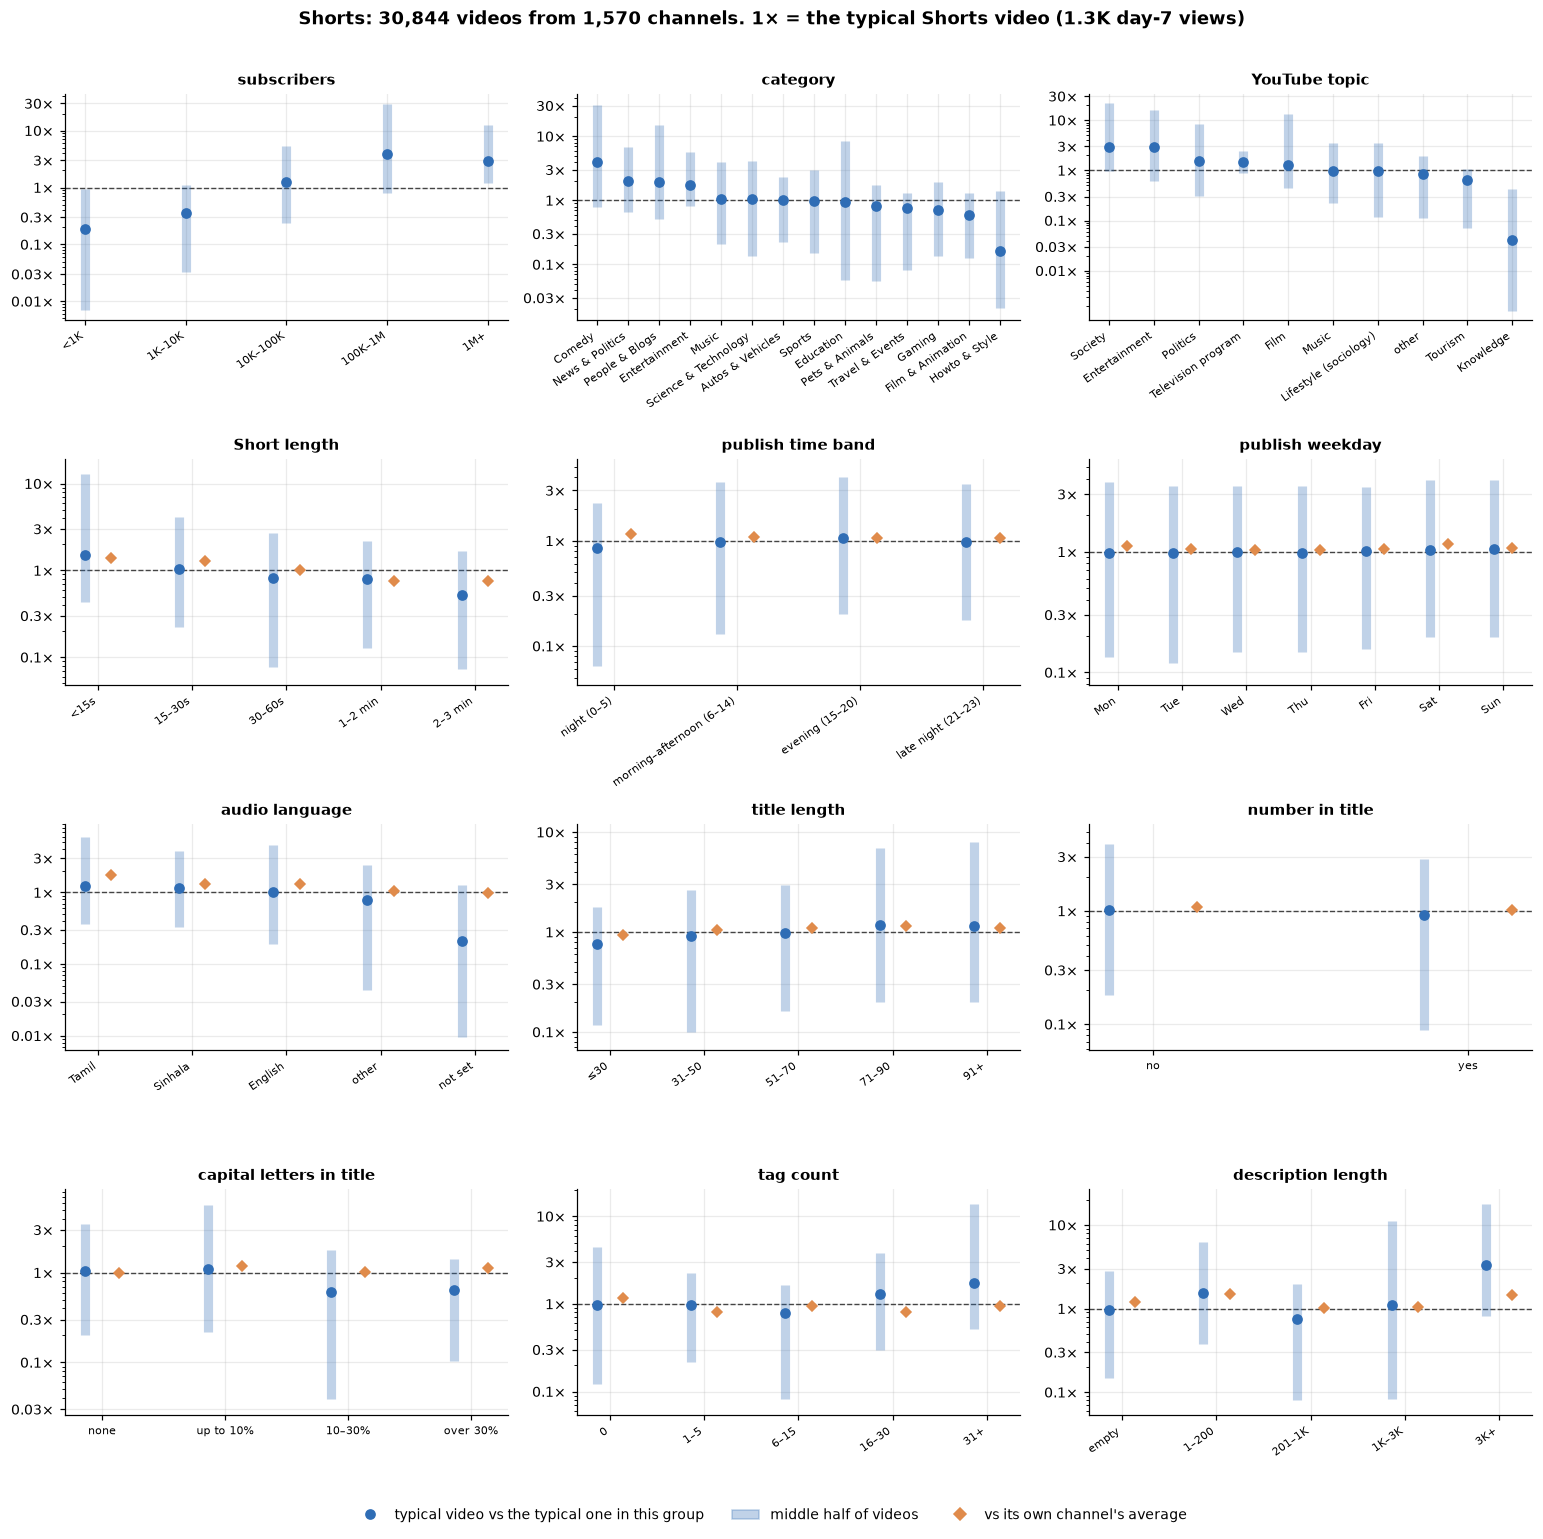

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
subscribers,100K–1M (3.9×),<1K (0.19×),not applicable,,
category,Comedy (3.9×),Howto & Style (0.16×),not applicable,,
YouTube topic,Society (2.9×),Knowledge (0.04×),not applicable,,
Short length,<15s (1.49×),2–3 min (0.52×),<15s (1.40×),2–3 min (0.75×),1.86×
publish time band,evening (15–20) (1.06×),night (0–5) (0.86×),night (0–5) (1.15×),late night (21–23) (1.05×),1.09×
publish weekday,Sun (1.06×),Mon (0.97×),Sat (1.15×),Thu (1.04×),1.11×
audio language,Tamil (1.23×),not set (0.21×),Tamil (1.78×),not set (0.98×),1.81×
title length,71–90 (1.17×),≤30 (0.76×),71–90 (1.15×),≤30 (0.94×),1.22×
number in title,no (1.02×),yes (0.92×),no (1.09×),yes (1.03×),1.06×


In [68]:
L.format_page(d, f, "Short")

**What this shows.** Inside Shorts, **length is the main thing a creator
controls**. Shorts under 15 seconds get about 1.4× their channel's average and
2 to 3 minute Shorts about 0.75×, roughly a 2× gap, and it holds without News.
Shorter Shorts are more likely to be watched to the end and replayed, which the
Shorts feed rewards.

Almost nothing else matters much for Shorts: time of day, weekday, a number in
the title and capital letters all stay within about 1.2×. Tamil-language Shorts
do better than the same channel's other Shorts (1.8×), but from a small number
of channels. Channel size still sets the level: Shorts from 100K to 1M
subscriber channels typically get 3.9× the typical Short.

## Long-form

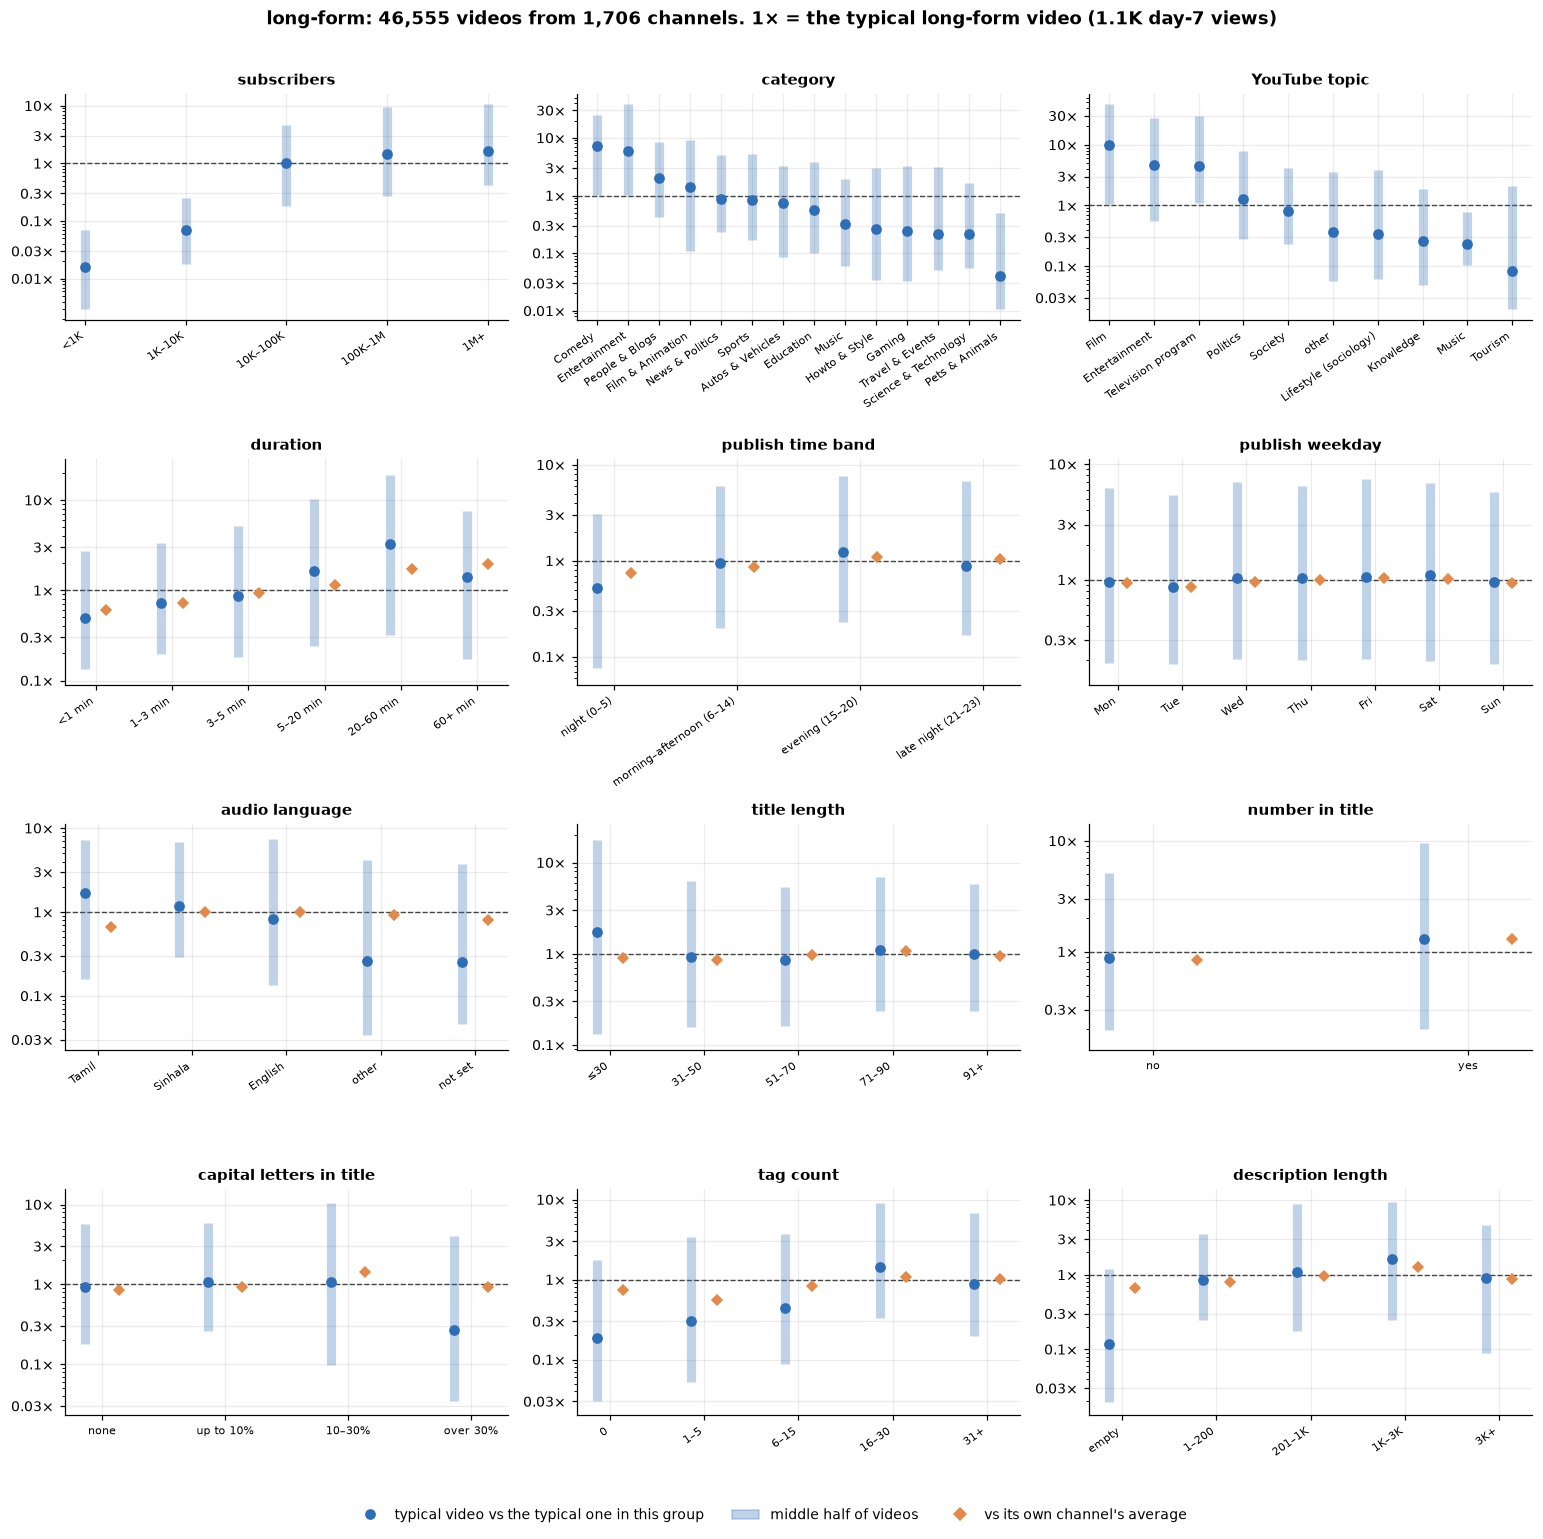

,best (vs typical in this group),worst,best vs own channel,worst vs own channel,own-channel gap
input,,,,,
subscribers,1M+ (1.63×),<1K (0.02×),not applicable,,
category,Comedy (7.1×),Pets & Animals (0.04×),not applicable,,
YouTube topic,Film (10×),Tourism (0.08×),not applicable,,
duration,20–60 min (3.2×),<1 min (0.49×),60+ min (1.93×),<1 min (0.60×),3.24×
publish time band,evening (15–20) (1.24×),night (0–5) (0.52×),evening (15–20) (1.11×),night (0–5) (0.75×),1.48×
publish weekday,Sat (1.10×),Tue (0.87×),Fri (1.03×),Tue (0.86×),1.19×
audio language,Tamil (1.68×),not set (0.25×),Sinhala (1.01×),Tamil (0.67×),1.51×
title length,≤30 (1.72×),51–70 (0.86×),71–90 (1.06×),31–50 (0.85×),1.25×
number in title,yes (1.31×),no (0.88×),yes (1.31×),no (0.84×),1.56×


In [69]:
L.format_page(d, f, "long-form")

**What this shows.** For long-form, **how the video is presented matters much
more** than for Shorts. Compared with the same channel's other long videos:

* **Length:** 60+ minutes does best (1.9×), and long-form under a minute (short
  horizontal clips) worst (0.6×).
* **Tags:** 16 to 30 tags best, 1 to 5 worst (a 1.9× gap; 2.7× without News).
* **Description:** 1K to 3K characters best, empty worst (2.0×; 1.6× without News).
* **Number in the title:** 1.3× against 0.8× (1.6× gap, with or without News).
* **Time of day:** evening best, night worst (1.5×; without News, late night
  21:00 to 23:00 is best, 1.7× gap).
* **Capital letters** looked strong (1.65×) but that is mostly News; without it
  the gap is 1.2×.

This fits how long videos are found: through search, the home page and
suggested videos, which read the title, tags and description. Shorts are found
by swiping, where those matter less.

## Does the same advice hold for both formats?

The best and worst value of each input, inside Shorts and inside long-form.
Inputs that vary within a channel are compared with the video's own channel;
channel inputs (subscribers, category, topic) use the raw view.

In [70]:
L.format_compare(d, f)

,compared on,Shorts: best,Shorts: worst,Shorts: gap,long-form: best,long-form: worst,long-form: gap,same best value?
input,,,,,,,,
subscribers,raw,100K–1M (3.9×),<1K (0.19×),20.92×,1M+ (1.63×),<1K (0.02×),100.67×,no
category,raw,Comedy (3.9×),Howto & Style (0.16×),24.73×,Comedy (7.1×),Pets & Animals (0.04×),179.91×,yes
YouTube topic,raw,Society (2.9×),Knowledge (0.04×),71.36×,Film (10×),Tourism (0.08×),118.78×,no
publish time band,own channel,night (0–5) (1.15×),late night (21–23) (1.05×),1.09×,evening (15–20) (1.11×),night (0–5) (0.75×),1.48×,no
publish weekday,own channel,Sat (1.15×),Thu (1.04×),1.11×,Fri (1.03×),Tue (0.86×),1.19×,no
audio language,own channel,Tamil (1.78×),not set (0.98×),1.81×,Sinhala (1.01×),Tamil (0.67×),1.51×,no
title length,own channel,71–90 (1.15×),≤30 (0.94×),1.22×,71–90 (1.06×),31–50 (0.85×),1.25×,yes
number in title,own channel,no (1.09×),yes (1.03×),1.06×,yes (1.31×),no (0.84×),1.56×,no
capital letters in title,own channel,up to 10% (1.18×),none (0.99×),1.19×,10–30% (1.41×),none (0.86×),1.65×,no


**What this shows.** The two formats rarely share the same best choice. Only
title length (71 to 90 characters) and the top category (Comedy) agree. For
tags, description, number in the title and time of day, long-form has the
larger gap and a different best value.

**For the model:** the Short or long-form input should be able to change how
other inputs act, not just shift the level. A tree model can learn this if it
is given the Short flag; a model without it would average two different
patterns. **For the app:** guidelines should be split by format. Advice on
tags, descriptions and titles belongs with long-form; for Shorts the useful
advice is mainly about length.

---
# 12. Growth from day 7 to day 30

How many extra views a video gains between day 7 and day 30, on the videos
with all four labels. 20% means day-30 views are 1.2 times day-7 views.

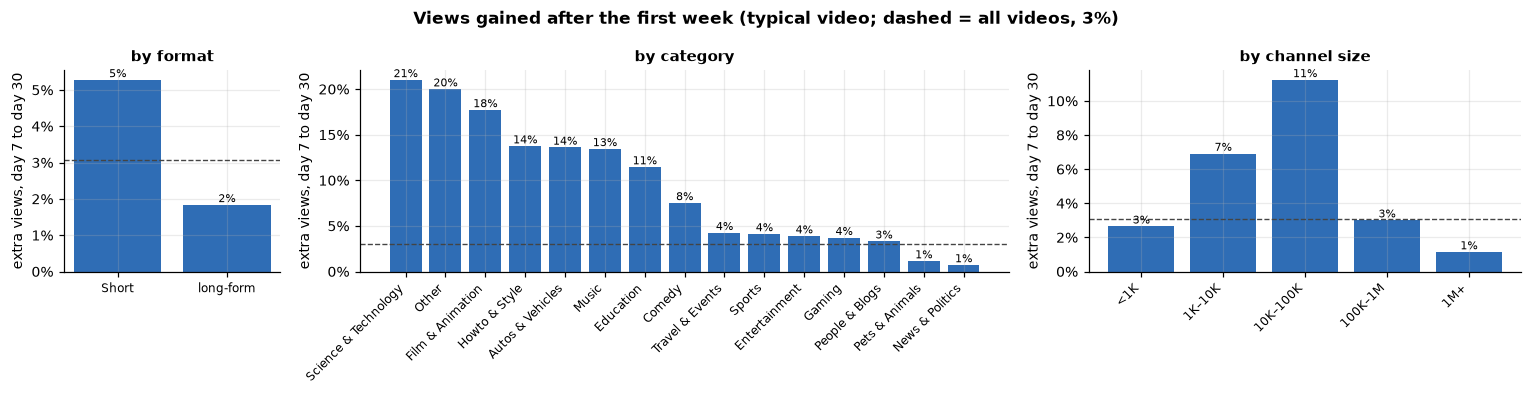

In [71]:
c = d[d.all4 & (d.v7 > 0)].copy()
c["ratio"] = c.v30 / c.v7
cc = f.loc[c.index]
def ratio_table(g):
    grp = c.ratio.groupby(g, observed=True)
    t = pd.DataFrame({"videos": grp.size(), "extra": (grp.median() - 1) * 100})
    return t[t.videos >= 200]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1, 3, 2]})
for ax, (label, g) in zip(axes, [("format", cc["Short or long-form"]),
                                ("category", pd.Series(L.category_of(c, CATS), index=c.index)),
                                ("channel size", cc["subscribers"])]):
    t = ratio_table(g)
    if label == "category":
        t = t.sort_values("extra", ascending=False)
    ax.bar(range(len(t)), t["extra"], color="#2F6DB5")
    ax.axhline((c.ratio.median() - 1) * 100, color="#444", ls="--", lw=.9)
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels(t.index, rotation=45 if len(t) > 3 else 0, ha="right" if len(t) > 3 else "center", fontsize=8)
    for i, v in enumerate(t["extra"]):
        ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5)
    ax.set(title=f"by {label}", ylabel="extra views, day 7 to day 30")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
fig.suptitle(f"Views gained after the first week (typical video; dashed = all videos, "
             f"{(c.ratio.median() - 1) * 100:.0f}%)", fontweight="bold")
fig.tight_layout()
save(fig, "growth_7_to_30")

**What this shows.** How much a video keeps growing after its first week.

* **Science & Technology, Film & Animation, Howto & Style, Autos and Music**
  gain 13 to 21% more after day 7. These are searched for later.
* **News & Politics and Pets & Animals** gain about 1%. They are watched almost
  entirely in the first week.
* **Channels of 10K to 100K subscribers** keep growing the most (11%); very large
  channels the least (1%).
* Shorts gain slightly more than long-form (5% against 2%).

So the day-30 forecast matters most for evergreen categories and mid-size
channels; for news it is almost the same as day 7.

---
# 13. Where the data is thin

Number of videos with a day-7 label for each category and channel size. A model
learns little where a cell is small, so forecasts there deserve less trust.

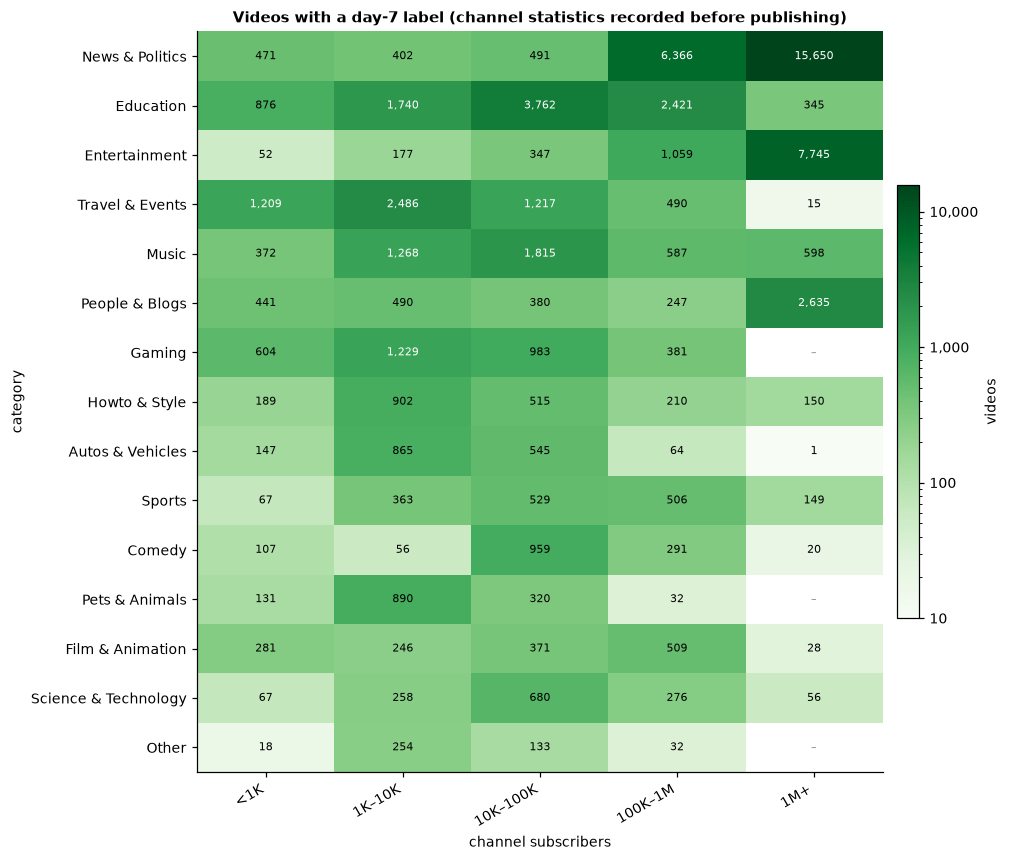

**16** of 75 cells have fewer than 100 videos.

In [72]:
t = d[lab].assign(cat=cat[lab], size=f["subscribers"][lab]).dropna(subset=["size"])
cnt = t.groupby(["cat", "size"], observed=True).size().unstack().fillna(0)
fig = L.grid(cnt.where(cnt > 0), pd.DataFrame(1e9, index=cnt.index, columns=cnt.columns),
             "Videos with a day-7 label (channel statistics recorded before publishing)",
             lambda v: f"{int(v):,}", "Greens", LogNorm(vmin=10, vmax=cnt.max().max()),
             "channel subscribers", "category", "videos", cbar_ticks=[10, 100, 1000, 10000])
save(fig, "thin_data_grid")
thin = int((cnt < 100).sum().sum())
say(f"**{thin}** of {cnt.size} cells have fewer than 100 videos.")

**What this shows.** Blank or light cells are combinations the model has seen
little of. Channels under 1K subscribers in Entertainment, Sports and Science,
and 1M+ channels in Travel, Gaming, Autos, Comedy, Pets, Film and Science, are
rare or missing. A forecast for,
say, a small News channel rests on very few examples and should carry a
warning.

---
# 14. Does the data change over time?

Typical day-7 views by the week a video was published. The model is trained on
earlier weeks and tested on later ones, so a steady line is what we want.

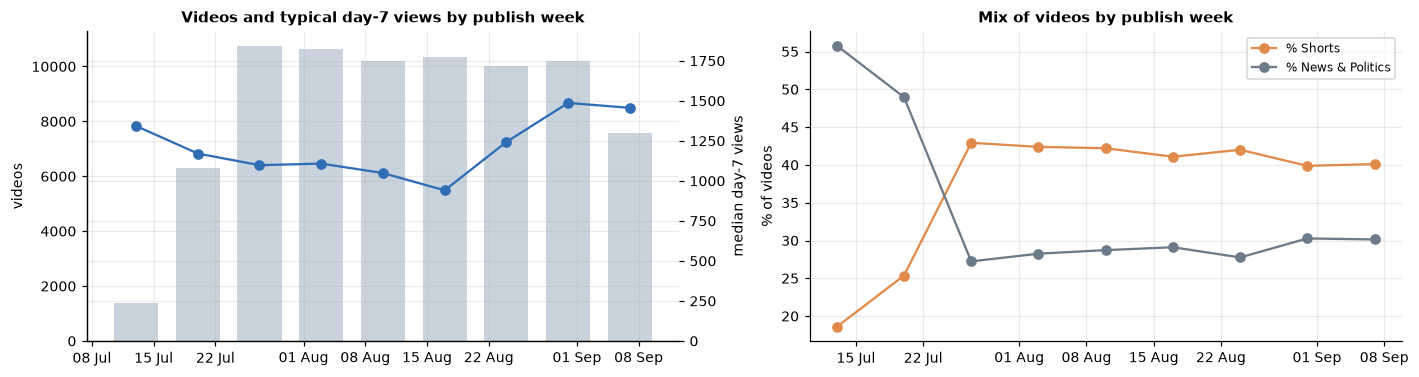

,videos,median day-7 views,% Shorts,% News & Politics
week of 13 Jul,"1,373",1.3K,19%,56%
week of 20 Jul,"6,319",1.2K,25%,49%
week of 27 Jul,"10,739",1.1K,43%,27%
week of 03 Aug,"10,637",1.1K,42%,28%
week of 10 Aug,"10,212",1.0K,42%,29%
week of 17 Aug,"10,352",941,41%,29%
week of 24 Aug,"10,023",1.2K,42%,28%
week of 31 Aug,"10,183",1.5K,40%,30%
week of 07 Sep,"7,561",1.5K,40%,30%


In [73]:
t = d[lab]
wk = t.published.dt.tz_localize(None).dt.to_period("W").dt.start_time
w = pd.DataFrame({"videos": t.groupby(wk).size(), "median day-7 views": t.groupby(wk).v7.median(),
                  "% Shorts": t.groupby(wk).is_short.mean() * 100,
                  "% News & Politics": t.groupby(wk).category_name.apply(lambda s: (s == "News & Politics").mean() * 100)})
fig, (a, b) = plt.subplots(1, 2, figsize=(13, 3.5))
a.bar(w.index, w.videos, width=5, color="#C9D3DD", label="videos")
a2 = a.twinx()
a2.plot(w.index, w["median day-7 views"], "o-", color="#2F6DB5", label="median day-7 views")
a2.set_ylim(0, w["median day-7 views"].max() * 1.3)
a.set(title="Videos and typical day-7 views by publish week", ylabel="videos")
a2.set_ylabel("median day-7 views")
b.plot(w.index, w["% Shorts"], "o-", color=L.OWN, label="% Shorts")
b.plot(w.index, w["% News & Politics"], "o-", color="#6C7A89", label="% News & Politics")
b.set(title="Mix of videos by publish week", ylabel="% of videos")
b.legend(fontsize=8)
for ax in (a, b):
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
fig.tight_layout()
save(fig, "change_over_time")
w.index = [f"week of {i:%d %b}" for i in w.index]
display(w.style.format({"videos": "{:,}", "median day-7 views": short, "% Shorts": "{:.0f}%",
                        "% News & Politics": "{:.0f}%"}))

**What this shows.** From late July on, the mix is steady: about 40% Shorts and
30% News every week, and 10,000 labelled videos a week. The first two weeks
differ (more News, fewer Shorts) because only some channels were tracked then.
Typical day-7 views dip in mid-August and rise at the start of September, from
about 950 to 1,500. A model tested on the latest weeks will therefore see
somewhat higher views than it was trained on.

---
# 15. What the most-viewed videos look like

The top 1% of videos by day-7 views, compared with all videos.

In [74]:
t = d[lab].copy()
cut_ = t.v7.quantile(.99)
top = t.v7 >= cut_
def mix(g, n=None):
    a = g[lab].value_counts(normalize=True) * 100
    b_ = g[lab][top.reindex(g[lab].index, fill_value=False)].value_counts(normalize=True) * 100
    out = pd.DataFrame({"all videos": a, "top 1%": b_}).fillna(0).sort_values("top 1%", ascending=False)
    return out.head(n) if n else out
say(f"Top 1% = at least **{short(cut_)}** day-7 views ({int(top.sum()):,} videos from "
    f"{t[top].channel_id.nunique():,} channels). The top 10 channels account for "
    f"**{t[top].channel_id.value_counts().head(10).sum() / top.sum() * 100:.0f}%** of them.")
for label, g, n in [("channel size", f["subscribers"].astype("object").fillna("recorded after publishing"), None),
                    ("format", f["Short or long-form"].astype("object"), None),
                    ("category", d.category_name, 8), ("duration", f["duration"].astype("object"), None)]:
    say(f"**By {label}** (% of videos)")
    display(mix(g, n).style.format("{:.0f}%"))

Top 1% = at least **340.3K** day-7 views (774 videos from 88 channels). The top 10 channels account for **64%** of them.

**By channel size** (% of videos)

,all videos,top 1%
subscribers,,
1M+,35%,64%
100K–1M,17%,19%
10K–100K,17%,8%
recorded after publishing,9%,8%
1K–10K,15%,1%
<1K,7%,0%


**By format** (% of videos)

,all videos,top 1%
Short or long-form,,
long-form,60%,50%
Short,40%,50%


**By category** (% of videos)

,all videos,top 1%
category_name,,
Entertainment,12%,50%
Education,14%,14%
Comedy,2%,13%
People & Blogs,6%,5%
News & Politics,31%,4%
Music,7%,3%
Howto & Style,3%,3%
Sports,2%,3%


**By duration** (% of videos)

,all videos,top 1%
duration,,
<1 min,39%,45%
20–60 min,8%,29%
5–20 min,15%,16%
1–3 min,26%,7%
3–5 min,9%,1%
60+ min,3%,1%


**What this shows.** The most-viewed 1% of videos come from a narrow group:
774 videos from 88 channels, and the top 10 channels produce 64% of them.
83% come from channels over 100K subscribers. **Entertainment is half of
them** despite being 12% of videos; **News & Politics is 31% of videos but only
4%** of the top. Shorts are slightly over-represented (50% against 40%), and so
are 20 to 60 minute videos (29% against 8%). Big errors on these few videos
will dominate any average error figure, so median-based error should be
reported alongside it.

---
# 16. Inputs that repeat each other

When two inputs carry the same information, the model only needs one.
**Rank agreement** runs from 0 (unrelated) to 1 (always in the same order).

In [75]:
num = lambda c: pd.to_numeric(d[c], errors="coerce")
sp = lambda a, b: a.corr(b, method="spearman")
rows = [
    ("title length vs title word count", f"rank agreement {sp(num('title_length'), num('title_word_count')):.2f}", "keep one"),
    ("weekend vs publish weekday", "weekend is Sat or Sun: fully decided by weekday", "keep one"),
    ("publish time band vs publish hour", "the band is a grouping of the hour", "keep one"),
    ("hour sin/cos vs publish hour", "the same hour written as a point on a circle", "encoding, not a new input"),
    ("Short vs duration", f"{(d.is_short & (num('duration_seconds') > 180)).sum():,} Shorts over 3 min; "
     f"{(~d.is_short & (num('duration_seconds') <= 60)).sum():,} videos of 60 s or less are not Shorts",
     "both needed: shape adds what length cannot"),
    ("audio language vs default language", f"agree on {(f['audio language'] == f['default language']).mean()*100:.0f}% of videos", "the API sends one, mapped from the other"),
    ("subscribers vs channel average views", f"rank agreement {sp(num('ch_subs_at_publish'), num('ch_views_at_publish') / num('ch_videos_at_publish')):.2f}", "related, both useful"),
    ("channel video count vs uploads per day", f"rank agreement {sp(num('ch_videos_at_publish'), num('ch_videos_at_publish') / num('channel_age_days_at_publish')):.2f}", "related"),
    ("tag count vs description length", f"rank agreement {sp(num('tag_count'), num('description_length')):.2f}", "mostly separate"),
]
display(pd.DataFrame(rows, columns=["pair", "how related", "what to do"]).set_index("pair"))

,how related,what to do
pair,,
title length vs title word count,rank agreement 0.83,keep one
weekend vs publish weekday,weekend is Sat or Sun: fully decided by weekday,keep one
publish time band vs publish hour,the band is a grouping of the hour,keep one
hour sin/cos vs publish hour,the same hour written as a point on a circle,"encoding, not a new input"
Short vs duration,"0 Shorts over 3 min; 8,075 videos of 60 s or l...",both needed: shape adds what length cannot
audio language vs default language,agree on 58% of videos,"the API sends one, mapped from the other"
subscribers vs channel average views,rank agreement 0.71,"related, both useful"
channel video count vs uploads per day,rank agreement 0.94,related
tag count vs description length,rank agreement 0.44,mostly separate


**What this shows.** Title length and word count, weekday and weekend, and hour
and time band each carry the same information: keep one of each pair. Short
and duration are **not** duplicates: 8,000 videos of a minute or less are not
Shorts, so the shape adds something length cannot. Channel video count and
uploads per day agree almost completely (0.94), so one of them is enough.

---
# 17. What the forecast actually receives

An input only helps if the app can supply it when a creator asks for a forecast.
This is what `prediction_api/app/feature_builder.py` sends today.

In [76]:
AV = [
    ("category, duration", "on the form", "sent"),
    ("audio language", "on the form", "sent, mapped to en / si / ta"),
    ("publish day and hour", "on the form, optional", "sent as weekend yes/no and a four-band time"),
    ("subscribers, video count, channel age, average views", "looked up from the channel", "sent"),
    ("Short or long-form", "not asked", "always missing: the form needs the field"),
    ("YouTube topic", "available from the same channel lookup", "always missing: needs fetching"),
    ("title", "typed on the form", "used for tone advice only, not the forecast"),
    ("tags, description", "not asked", "not used"),
    ("HD or SD, captions, made for kids", "not asked", "not used (nearly constant anyway)"),
]
display(pd.DataFrame(AV, columns=["input", "where it comes from", "status today"]).set_index("input"))

,where it comes from,status today
input,,
"category, duration",on the form,sent
audio language,on the form,"sent, mapped to en / si / ta"
publish day and hour,"on the form, optional",sent as weekend yes/no and a four-band time
"subscribers, video count, channel age, average views",looked up from the channel,sent
Short or long-form,not asked,always missing: the form needs the field
YouTube topic,available from the same channel lookup,always missing: needs fetching
title,typed on the form,"used for tone advice only, not the forecast"
"tags, description",not asked,not used
"HD or SD, captions, made for kids",not asked,not used (nearly constant anyway)


**What this shows.** Three strong inputs are available but not used:

* **YouTube topic** explains 10% of views and comes from the same channel lookup
  the API already makes.
* **Short or long-form** needs one form field.
* **Title-based inputs** can be worked out from the title the form already
  collects.

Tags and description would need new form fields.

---
# 18. Summary: every input

Day-7 numbers use all videos with a day-7 label. The four "explains" columns
use the same videos at every horizon (those with all four labels), so they can
be compared across time.

,section,source at forecast time,explains (day 7),gap vs own channel,explains d7 (same videos),explains d14 (same videos),explains d21 (same videos),explains d30 (same videos),verdict,why,strength
input,,,,,,,,,,,
channel average views per video,channel,looked up from the channel,38.1%,,36.9%,36.9%,36.9%,36.8%,keep,explains 38.1% of day-7 views,strong
subscribers,channel,looked up from the channel,22.5%,,18.6%,17.9%,17.4%,17.1%,keep,explains 22.5% of day-7 views,strong
YouTube topic,channel,looked up from the channel (not sent yet),10.3%,,9.3%,9.0%,8.9%,8.8%,"keep, needs serving work",explains 10.3% of day-7 views; looked up from the channel (not sent yet),strong
category,format,on the form,9.1%,,8.4%,8.3%,8.3%,8.4%,keep,explains 9.1% of day-7 views,strong
channel video count,channel,looked up from the channel,4.5%,,3.4%,2.9%,2.6%,2.4%,keep,explains 4.5% of day-7 views,moderate
title script,language,worked out from the title (not sent yet),4.0%,1.05×,3.2%,3.0%,2.9%,2.8%,"keep, needs serving work","1.05× gap against own channel, 1.64× for 1M+ channels; worked out from the title (not sent yet)",only for 1M+ channels
channel uploads per day,channel,worked out from the channel,3.5%,,2.8%,2.4%,2.2%,2.0%,keep,explains 3.5% of day-7 views,moderate
audio language,language,on the form,3.4%,1.32×,2.7%,2.5%,2.4%,2.3%,keep,1.32× gap against own channel,moderate
tag count,text,not on the form,3.0%,1.50×,2.3%,2.2%,2.1%,2.1%,"keep, needs serving work",1.50× gap against own channel; not on the form,strong


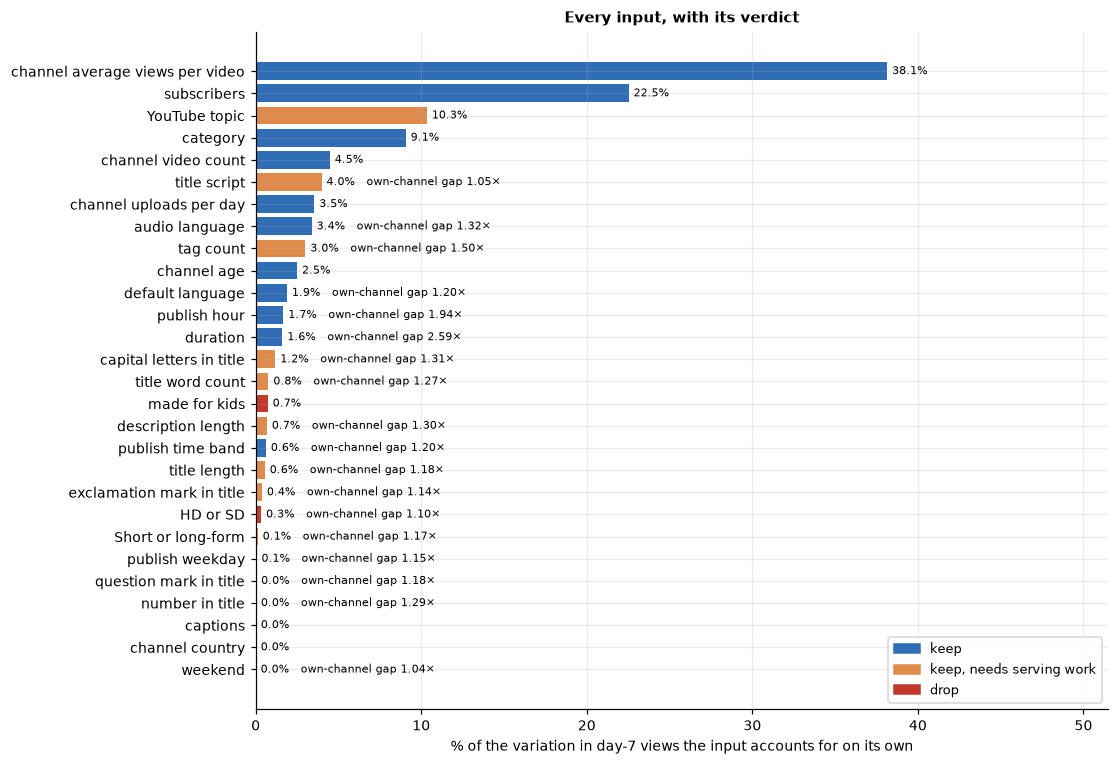

In [77]:
rows = []
for name in [c for c in f.columns if c != "Short length"]:
    s = S.get(name) or L.stats(d, f, name)
    v, why = L.verdict(name, s)
    row = {"input": name, "section": L.META[name]["section"], "source at forecast time": L.META[name]["source"],
           "explains (day 7)": s["explains_raw"],
           "gap vs own channel": s["bw_own"] if L.META[name]["kind"] == "video" else np.nan}
    for h in H:
        row[f"explains d{h} (same videos)"] = L.explains(np.log1p(d.loc[d.all4, f"v{h}"]), f.loc[d.all4, name])
    row["verdict"], row["why"] = v, why
    if v == "drop":
        row["strength"] = ""
    elif L.META[name]["kind"] == "channel":
        row["strength"] = "strong" if s["explains_raw"] >= 5 else "moderate"
    elif s["bw_own"] >= 1.5:
        row["strength"] = "strong"
    elif s["bw_own"] >= L.OWN_MIN:
        row["strength"] = "moderate"
    else:
        row["strength"] = f"only for {s['band']} channels"
    rows.append(row)
summary = pd.DataFrame(rows).set_index("input").sort_values("explains (day 7)", ascending=False)
fmt = {c: "{:.1f}%" for c in summary.columns if c.startswith("explains")}
fmt["gap vs own channel"] = lambda v: "" if pd.isna(v) else f"{v:.2f}×"
display(summary.style.format(fmt))

colours = {"keep": "#2F6DB5", "keep, needs serving work": "#E08B4B", "drop": "#C0392B"}
r = summary.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(r)), r["explains (day 7)"], color=[colours[v] for v in r.verdict])
ax.set_yticks(range(len(r))); ax.set_yticklabels(r.index)
for i, (x, g) in enumerate(zip(r["explains (day 7)"], r["gap vs own channel"])):
    ax.text(x + .3, i, f"{x:.1f}%" + ("" if pd.isna(g) else f"   own-channel gap {g:.2f}×"), va="center", fontsize=7.5)
ax.set_xlim(0, r["explains (day 7)"].max() * 1.35)
ax.set(xlabel="% of the variation in day-7 views the input accounts for on its own",
       title="Every input, with its verdict")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in colours.values()], labels=list(colours),
          loc="lower right", fontsize=8.5)
save(fig, "summary_all_inputs")

## In short

**Strongest inputs:** the channel's average views per video (38%), subscribers
(23%), the channel's YouTube topic (10%) and category (9%). Within a channel,
**duration** (2.6× gap between best and worst), **publish hour** (1.9×) and
**tag count** (1.5×) matter most.

**Drop:** channel country, captions, made for kids, HD or SD (almost all
videos the same), and weekend (no difference).

**Moderate:** audio language, number in title, capital letters, word count,
description length, time band. **Weak or only for some channel sizes:** title
script, title length, question and exclamation marks, weekday.

**Most important thing a creator controls:** Short or long-form, depending on
channel size. For channels under 100K subscribers, Shorts get about 1.35× to 2×
the channel's own long-form. For bigger channels they do not help.

**Shorts and long-form behave differently** (section 11). For Shorts, length
is the main lever (under 15 seconds about 2× better than 2 to 3 minutes). For
long-form, tags, description, a number in the title and time of day each make a
1.5× to 2.7× difference against the same channel's other videos. Guidelines in
the app should be split by format.

**For the model and the app:**

1. Fetch the channel's YouTube topic at forecast time.
2. Add a Short or long-form field to the form.
3. Use the title the form already collects to work out title inputs.
4. Consider tags and description fields.
5. Send the exact publish hour rather than a four-band time.
6. Train on the same language mapping the API uses.

**News & Politics skews the whole-dataset numbers** (section 10). It weakens
the channel-size inputs and inflates the Shorts, capital-letter and publish-hour
effects. The per-category pages are the fairer place to judge video-level
inputs, and they show that the best choices differ by category: Entertainment
and Science favour long-form, most others favour Shorts.

**Horizons.** Every input's effect is nearly the same at day 7, 14, 21 and 30
(same videos). The largest drift is subscribers, falling from 18.6% to 17.1%.
One model design across horizons is reasonable; per-horizon differences come
from growth (section 12), not from different inputs mattering.